# Clinical Classification Threshold Optimization

### Precision–Recall Trade-off and Clinical Decision Threshold Analysis

This project focuses on optimizing the classification threshold of a clinical machine learning model.

The objective is to systematically evaluate different probability thresholds and understand their effect on:

- Precision
- Recall
- F1-Score
- Specificity
- False Positive Rate
- False Negative Rate

The project will also evaluate different clinical priorities and identify a threshold that provides an appropriate balance between false positives and false negatives.

## 1. Project Objective

The main objective of this project is to build a reliable clinical classification pipeline and determine how different classification thresholds affect model performance.

Instead of relying only on the default threshold of `0.50`, this project will systematically evaluate thresholds across the probability range from `0.00` to `1.00`.

The final threshold will be selected based on clearly defined clinical objectives and validated on an untouched test set.

## 2. Project Workflow

The project follows a structured machine learning workflow:

1. Dataset Understanding
2. Data Quality Assessment
3. Exploratory Data Analysis
4. Data Preprocessing
5. Train / Validation / Test Split
6. Leakage Prevention
7. Baseline Model Development
8. Model Calibration
9. Threshold Sweeping
10. Precision–Recall Trade-off Analysis
11. Clinical Threshold Optimization
12. Cost-Sensitive Threshold Analysis
13. Statistical Validation
14. Final Holdout Evaluation
15. Production Architecture
16. Final Conclusions

## 3. Dataset Structure

The dataset is a clinical tabular dataset containing numerical, categorical, engineered, and metadata-related variables.

Before model development, the dataset structure will be examined carefully to identify:

- Numerical features
- Categorical features
- Identifier columns
- Metadata columns
- Derived features
- Target-related columns
- Potential data leakage
- Missing values
- Duplicate records
- Class distribution

No preprocessing or model training will be performed until the dataset structure and target definition have been verified.

# Step 1 Project Configuration

### Import Libraries

In [15]:
# ============================================================
# Import Libraries
# ============================================================

import warnings
import random

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder
)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    average_precision_score,
    precision_recall_curve,
    roc_curve,
    brier_score_loss,
    log_loss
)

from sklearn.calibration import (
    calibration_curve,
    CalibratedClassifierCV
)

print("Libraries imported successfully.")

Libraries imported successfully.


### Set Random Seeds

In [16]:
# ============================================================
#  Set Random Seeds
# ============================================================

RANDOM_STATE = 42

np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)

print(f"Random state set to: {RANDOM_STATE}")

Random state set to: 42


### Define Global Configuration

In [17]:
# ============================================================
# Define Global Configuration
# ============================================================

# Dataset split configuration
TEST_SIZE = 0.20
VALIDATION_SIZE = 0.20

# Baseline classification threshold
BASELINE_THRESHOLD = 0.50

# Threshold sweep configuration
THRESHOLD_MIN = 0.00
THRESHOLD_MAX = 1.00
THRESHOLD_STEP = 0.01

THRESHOLDS = np.arange(
    THRESHOLD_MIN,
    THRESHOLD_MAX + THRESHOLD_STEP,
    THRESHOLD_STEP
)

# Clinical optimization examples
MIN_RECALL = 0.95
MIN_PRECISION = 0.90

# Cost-sensitive examples
FN_COST = 10
FP_COST = 1

# Display configuration
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 120)

# Visualization configuration
sns.set_theme(style="whitegrid")

print("Global configuration created successfully.")
print(f"Random state: {RANDOM_STATE}")
print(f"Baseline threshold: {BASELINE_THRESHOLD}")
print(f"Threshold range: {THRESHOLD_MIN:.2f} - {THRESHOLD_MAX:.2f}")
print(f"Threshold step: {THRESHOLD_STEP}")
print(f"Number of thresholds: {len(THRESHOLDS)}")

Global configuration created successfully.
Random state: 42
Baseline threshold: 0.5
Threshold range: 0.00 - 1.00
Threshold step: 0.01
Number of thresholds: 101


### Configure Reproducibility

Reproducibility ensures that the same code and configuration produce consistent experimental results.

The project will follow these principles:

1. Use a fixed random state.
2. Keep dataset splitting deterministic.
3. Fit preprocessing only on the appropriate training data.
4. Keep the validation set separate for threshold selection.
5. Keep the final test set untouched until final evaluation.
6. Record model and threshold configuration.
7. Avoid using information from the test set during model development.

These controls help prevent accidental data leakage and make the final results reproducible.

### Configure Reproducibility

In [18]:
# ============================================================
# Configure Reproducibility
# ============================================================

# Re-apply deterministic random states
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)

# Reproducibility configuration
REPRODUCIBILITY_CONFIG = {
    "random_state": RANDOM_STATE,
    "test_size": TEST_SIZE,
    "validation_size": VALIDATION_SIZE,
    "baseline_threshold": BASELINE_THRESHOLD,
    "threshold_min": THRESHOLD_MIN,
    "threshold_max": THRESHOLD_MAX,
    "threshold_step": THRESHOLD_STEP
}

print("Reproducibility configuration:")
for key, value in REPRODUCIBILITY_CONFIG.items():
    print(f"{key}: {value}")

Reproducibility configuration:
random_state: 42
test_size: 0.2
validation_size: 0.2
baseline_threshold: 0.5
threshold_min: 0.0
threshold_max: 1.0
threshold_step: 0.01


## 1.2 Dataset Loading

### 1.2.1 Load Dataset



The dataset is loaded into a Pandas DataFrame for subsequent analysis.

At this stage, no preprocessing, feature engineering, encoding, scaling, or row removal is performed.

The purpose of this step is only to:

- Load the original dataset
- Confirm that the file can be read successfully
- Store the dataset in memory
- Verify its basic dimensions

In [19]:
# ============================================================
#  Load Dataset
# ============================================================

DATA_PATH = "/content/Data Warehouse Multiclass.csv"

df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully.")
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]:,}")

display(df.head())

Dataset loaded successfully.
Rows: 280,985
Columns: 39


,composite_key,age_level,gender,bmi_level,smoking,diabetes,age,age_normalized,bmi,hypertension,heart_disease,HbA1c_level,glucose,cholesterol,sleep_hours,triglycerides,physical_activity,family_history,stress_level,low_hdl_cholesterol,high_ldl_cholesterol,blood_pressure,high_blood_pressure,sugar_consumption,crp_level,homocysteine_level,systolic_bp,diastolic_bp,alcohol_intake,salt_intake,heart_rate,hdl,ldl,education_level,employment_status,source_dataset,disease_flags,sublabel,label
0,Young_Female_Normal_Never_No,Young,Female,Normal,Never,No,9,0.080460,19.20,0.0,0.0,5.8,158.0,214.703704,6.864403,246.703704,High,No,High,Yes,Yes,152.481481,No,Low,8.219098,11.168096,135.380192,89.539936,14.777636,8.685304,74.329073,65.651757,129.220447,Primary,Retired,diabetes,"0,0,0",N,Normal
1,Young_Female_Normal_Never_No,Young,Female,Normal,Never,No,3,0.011494,22.55,0.0,0.0,6.6,159.0,214.703704,6.864403,246.703704,High,No,High,Yes,Yes,152.481481,No,Low,8.219098,11.168096,135.380192,89.539936,14.777636,8.685304,74.329073,65.651757,129.220447,Primary,Retired,diabetes,"0,0,0",N,Normal
2,Young_Female_Normal_Never_No,Young,Female,Normal,Never,No,3,0.011494,22.89,0.0,0.0,4.0,126.0,214.703704,6.864403,246.703704,High,No,High,Yes,Yes,152.481481,No,Low,8.219098,11.168096,135.380192,89.539936,14.777636,8.685304,74.329073,65.651757,129.220447,Primary,Retired,diabetes,"0,0,0",N,Normal
3,Young_Female_Normal_Never_No,Young,Female,Normal,Never,No,3,0.011494,23.12,0.0,0.0,6.2,85.0,214.703704,6.864403,246.703704,High,No,High,Yes,Yes,152.481481,No,Low,8.219098,11.168096,135.380192,89.539936,14.777636,8.685304,74.329073,65.651757,129.220447,Primary,Retired,diabetes,"0,0,0",N,Normal
4,Young_Female_Normal_Never_No,Young,Female,Normal,Never,No,4,0.022989,19.61,0.0,0.0,5.7,155.0,214.703704,6.864403,246.703704,High,No,High,Yes,Yes,152.481481,No,Low,8.219098,11.168096,135.380192,89.539936,14.777636,8.685304,74.329073,65.651757,129.220447,Primary,Retired,diabetes,"0,0,0",N,Normal


### 1.2.2 Verify Dataset Source

In [20]:
# ============================================================
# Verify Dataset Source
# ============================================================

print("=" * 60)
print("DATASET SOURCE VERIFICATION")
print("=" * 60)

print(f"Dataset path: {DATA_PATH}")
print(f"Dataset shape: {df.shape}")

print("\nColumn count:", len(df.columns))

print("\nColumn names:")
print(df.columns.tolist())

DATASET SOURCE VERIFICATION
Dataset path: /content/Data Warehouse Multiclass.csv
Dataset shape: (280985, 39)

Column count: 39

Column names:
['composite_key', 'age_level', 'gender', 'bmi_level', 'smoking', 'diabetes', 'age', 'age_normalized', 'bmi', 'hypertension', 'heart_disease', 'HbA1c_level', 'glucose', 'cholesterol', 'sleep_hours', 'triglycerides', 'physical_activity', 'family_history', 'stress_level', 'low_hdl_cholesterol', 'high_ldl_cholesterol', 'blood_pressure', 'high_blood_pressure', 'sugar_consumption', 'crp_level', 'homocysteine_level', 'systolic_bp', 'diastolic_bp', 'alcohol_intake', 'salt_intake', 'heart_rate', 'hdl', 'ldl', 'education_level', 'employment_status', 'source_dataset', 'disease_flags', 'sublabel', 'label']


In [21]:
# Expected columns observed from the provided dataset structure
expected_columns = [
    "composite_key",
    "age_level",
    "gender",
    "bmi_level",
    "smoking",
    "diabetes",
    "age",
    "age_normalized",
    "bmi",
    "hypertension",
    "salt_intake",
    "heart_rate",
    "hdl",
    "ldl",
    "education_level",
    "employment_status",
    "source_dataset",
    "disease_flags",
    "sublabel",
    "label"
]

available_expected = [
    col for col in expected_columns
    if col in df.columns
]

missing_expected = [
    col for col in expected_columns
    if col not in df.columns
]

print("\nExpected columns found:")
print(available_expected)

print("\nExpected columns missing:")
print(missing_expected)


Expected columns found:
['composite_key', 'age_level', 'gender', 'bmi_level', 'smoking', 'diabetes', 'age', 'age_normalized', 'bmi', 'hypertension', 'salt_intake', 'heart_rate', 'hdl', 'ldl', 'education_level', 'employment_status', 'source_dataset', 'disease_flags', 'sublabel', 'label']

Expected columns missing:
[]


### 1.2.3 Create Working Copy

In [22]:
# ============================================================
# Create Working Copy
# ============================================================

df_original = df.copy()

df_working = df.copy()

print("Original dataset preserved.")
print("Working copy created.")

print(f"\nOriginal shape: {df_original.shape}")
print(f"Working copy shape: {df_working.shape}")

Original dataset preserved.
Working copy created.

Original shape: (280985, 39)
Working copy shape: (280985, 39)


## 1.3 Initial Dataset Inspection

### 1.3.1 Dataset Shape

In [23]:
# ============================================================
# Dataset Shape
# ============================================================

print("=" * 60)
print("DATASET SHAPE")
print("=" * 60)

print(f"Number of rows:    {df_working.shape[0]:,}")
print(f"Number of columns: {df_working.shape[1]:,}")

print(f"\nDataset shape: {df_working.shape}")

DATASET SHAPE
Number of rows:    280,985
Number of columns: 39

Dataset shape: (280985, 39)


### 1.3.2 Head and Sample Records

In [24]:
# ============================================================
# Head and Sample Records
# ============================================================

print("=" * 60)
print("FIRST FIVE RECORDS")
print("=" * 60)

display(df_working.head())

print("\n" + "=" * 60)
print("RANDOM SAMPLE OF RECORDS")
print("=" * 60)

display(
    df_working.sample(
        n=5,
        random_state=RANDOM_STATE
    )
)

FIRST FIVE RECORDS


,composite_key,age_level,gender,bmi_level,smoking,diabetes,age,age_normalized,bmi,hypertension,heart_disease,HbA1c_level,glucose,cholesterol,sleep_hours,triglycerides,physical_activity,family_history,stress_level,low_hdl_cholesterol,high_ldl_cholesterol,blood_pressure,high_blood_pressure,sugar_consumption,crp_level,homocysteine_level,systolic_bp,diastolic_bp,alcohol_intake,salt_intake,heart_rate,hdl,ldl,education_level,employment_status,source_dataset,disease_flags,sublabel,label
0,Young_Female_Normal_Never_No,Young,Female,Normal,Never,No,9,0.080460,19.20,0.0,0.0,5.8,158.0,214.703704,6.864403,246.703704,High,No,High,Yes,Yes,152.481481,No,Low,8.219098,11.168096,135.380192,89.539936,14.777636,8.685304,74.329073,65.651757,129.220447,Primary,Retired,diabetes,"0,0,0",N,Normal
1,Young_Female_Normal_Never_No,Young,Female,Normal,Never,No,3,0.011494,22.55,0.0,0.0,6.6,159.0,214.703704,6.864403,246.703704,High,No,High,Yes,Yes,152.481481,No,Low,8.219098,11.168096,135.380192,89.539936,14.777636,8.685304,74.329073,65.651757,129.220447,Primary,Retired,diabetes,"0,0,0",N,Normal
2,Young_Female_Normal_Never_No,Young,Female,Normal,Never,No,3,0.011494,22.89,0.0,0.0,4.0,126.0,214.703704,6.864403,246.703704,High,No,High,Yes,Yes,152.481481,No,Low,8.219098,11.168096,135.380192,89.539936,14.777636,8.685304,74.329073,65.651757,129.220447,Primary,Retired,diabetes,"0,0,0",N,Normal
3,Young_Female_Normal_Never_No,Young,Female,Normal,Never,No,3,0.011494,23.12,0.0,0.0,6.2,85.0,214.703704,6.864403,246.703704,High,No,High,Yes,Yes,152.481481,No,Low,8.219098,11.168096,135.380192,89.539936,14.777636,8.685304,74.329073,65.651757,129.220447,Primary,Retired,diabetes,"0,0,0",N,Normal
4,Young_Female_Normal_Never_No,Young,Female,Normal,Never,No,4,0.022989,19.61,0.0,0.0,5.7,155.0,214.703704,6.864403,246.703704,High,No,High,Yes,Yes,152.481481,No,Low,8.219098,11.168096,135.380192,89.539936,14.777636,8.685304,74.329073,65.651757,129.220447,Primary,Retired,diabetes,"0,0,0",N,Normal



RANDOM SAMPLE OF RECORDS


,composite_key,age_level,gender,bmi_level,smoking,diabetes,age,age_normalized,bmi,hypertension,heart_disease,HbA1c_level,glucose,cholesterol,sleep_hours,triglycerides,physical_activity,family_history,stress_level,low_hdl_cholesterol,high_ldl_cholesterol,blood_pressure,high_blood_pressure,sugar_consumption,crp_level,homocysteine_level,systolic_bp,diastolic_bp,alcohol_intake,salt_intake,heart_rate,hdl,ldl,education_level,employment_status,source_dataset,disease_flags,sublabel,label
149558,Middle_Male_Overweight_Former_No,Middle,Male,Overweight,Former,No,43,0.471264,27.00,0.022265,0.005808,5.424782,154.0,224.000000,4.500000,237.000000,High,Yes,High,No,Yes,147.833988,Yes,Low,7.414141,12.534473,142.000000,118.000000,26.000000,10.800000,56.000000,63.000000,137.000000,Tertiary,Unemployed,hypertension,"0,0,1",HY,Abnormal
26305,Middle_Female_Overweight_Former_Yes,Middle,Female,Overweight,Former,Yes,28,0.298851,25.50,0.000000,0.000000,6.000000,126.0,225.000000,7.128587,148.024625,Low,Yes,Low,No,Yes,149.008407,Yes,Medium,7.582981,12.441519,134.911135,89.195931,15.126124,8.519058,74.377944,64.654176,128.631692,Primary,Unemployed,diabetes,"1,0,0",DI,Abnormal
158645,Young_Male_Obese_Current_No,Young,Male,Obese,Current,No,23,0.241379,39.80,0.036364,0.000000,5.707273,124.0,288.000000,4.100000,111.000000,Moderate,No,Low,No,Yes,149.333333,No,High,8.101519,13.468089,132.000000,78.000000,23.300000,10.100000,87.000000,90.000000,131.000000,Tertiary,Employed,hypertension,"0,0,1",HY,Abnormal
123260,Senior_Male_Obese_Former_No,Senior,Male,Obese,Former,No,70,0.781609,32.00,0.174475,0.214863,5.414701,139.0,269.000000,5.500000,138.000000,High,No,Medium,No,Yes,149.757035,Yes,Low,7.294863,12.657538,122.000000,99.000000,25.500000,13.600000,73.000000,56.000000,142.000000,Secondary,Unemployed,hypertension,"0,0,1",HY,Abnormal
83819,Young_Male_Normal_Never_No,Young,Male,Normal,Never,No,19,0.195402,20.87,0.000000,0.000000,6.000000,160.0,198.269231,6.578438,261.307692,High,No,High,No,No,149.846154,No,Medium,8.013048,11.845827,132.238854,88.353503,15.694586,8.830892,72.872611,65.187898,129.557325,Tertiary,Retired,diabetes,"0,0,0",N,Normal


### 1.3.3 Summary Statistics

In [25]:
# ============================================================
#  Summary Statistics - Numerical Features
# ============================================================

print("=" * 60)
print("NUMERICAL SUMMARY STATISTICS")
print("=" * 60)

numeric_summary = df_working.describe(
    include=[np.number]
).T

display(numeric_summary)

NUMERICAL SUMMARY STATISTICS


,count,mean,std,min,25%,50%,75%,max
age,280985.0,49.665865,21.682350,2.000000,32.000000,50.000000,67.000000,89.000000
age_normalized,280985.0,0.547883,0.249222,0.000000,0.344827,0.551724,0.747126,1.000000
bmi,280985.0,27.490663,7.040373,10.010000,22.100000,27.320000,32.700000,95.690000
hypertension,280985.0,0.128218,0.187346,0.000000,0.000000,0.071429,0.217063,1.000000
heart_disease,280985.0,0.073390,0.138243,0.000000,0.000000,0.007299,0.115053,1.000000
HbA1c_level,280985.0,5.947475,0.954072,3.500000,5.384805,5.800000,6.865766,9.000000
glucose,280985.0,135.258646,38.477865,70.000000,100.000000,138.000000,160.000000,300.000000
cholesterol,280985.0,224.045525,35.525530,150.000000,202.000000,225.000000,243.000000,300.000000
sleep_hours,280985.0,6.954652,1.426412,4.000000,6.200000,6.975185,7.700000,10.000000
triglycerides,280985.0,178.995744,67.336085,50.000000,129.000000,179.000000,242.000000,400.000000


In [26]:
# ============================================================
# Summary Statistics - Categorical Features
# ============================================================

print("=" * 60)
print("CATEGORICAL SUMMARY STATISTICS")
print("=" * 60)

categorical_summary = df_working.describe(
    include=["object"]
).T

display(categorical_summary)

CATEGORICAL SUMMARY STATISTICS


,count,unique,top,freq
composite_key,280985,192,Middle_Female_Overweight_Never_No,6097
age_level,280985,4,Mature,87632
gender,280985,2,Female,148763
bmi_level,280985,4,Obese,98377
smoking,280985,3,Never,127764
diabetes,280985,2,No,180351
physical_activity,280985,3,High,120019
family_history,280985,2,No,157182
stress_level,280985,3,High,101298
low_hdl_cholesterol,280985,2,No,225935


In [27]:
# ============================================================
# Categorical Feature Overview
# ============================================================

categorical_overview = pd.DataFrame({
    "dtype": df_working.select_dtypes(
        include=["object"]
    ).dtypes,
    "unique_values": df_working.select_dtypes(
        include=["object"]
    ).nunique(),
    "missing_values": df_working.select_dtypes(
        include=["object"]
    ).isna().sum()
})

display(categorical_overview)

,dtype,unique_values,missing_values
composite_key,object,192,0
age_level,object,4,0
gender,object,2,0
bmi_level,object,4,0
smoking,object,3,0
diabetes,object,2,0
physical_activity,object,3,0
family_history,object,2,0
stress_level,object,3,0
low_hdl_cholesterol,object,2,0


### 1.3.4 Feature / Target Overview



The dataset contains several variables that may represent outcomes, disease information, metadata, or derived characteristics.

At this stage, the following variables are flagged for further investigation:

- label
- sublabel
- disease_flags
- source_dataset
- diabetes

The label column appears to be a potential target variable based on the dataset structure, but the final target will not be confirmed until the dedicated Target Variable Identification step.

Potential leakage relationships between these variables will also be investigated before model development.

For now, this section only provides an initial feature and target overview.

In [28]:
# ============================================================
# Feature / Target Overview
# ============================================================

print("=" * 60)
print("FEATURE / TARGET OVERVIEW")
print("=" * 60)

potential_target_columns = [
    "label",
    "sublabel",
    "disease_flags",
    "diabetes",
    "source_dataset"
]

overview = []

for column in potential_target_columns:
    if column in df_working.columns:
        overview.append({
            "column": column,
            "dtype": str(df_working[column].dtype),
            "unique_values": df_working[column].nunique(),
            "missing_values": df_working[column].isna().sum()
        })

target_overview = pd.DataFrame(overview)

display(target_overview)

FEATURE / TARGET OVERVIEW


,column,dtype,unique_values,missing_values
0,label,object,2,0
1,sublabel,object,8,0
2,disease_flags,object,8,0
3,diabetes,object,2,0
4,source_dataset,object,3,0


In [29]:
# ============================================================
# Inspect Potential Target-Related Variables
# ============================================================

for column in potential_target_columns:

    if column in df_working.columns:

        print("\n" + "=" * 60)
        print(f"{column}")
        print("=" * 60)

        print(
            df_working[column]
            .value_counts(dropna=False)
            .head(20)
        )


label
label
Abnormal    174101
Normal      106884
Name: count, dtype: int64

sublabel
sublabel
N           106884
HY           69806
DI_HY        66473
DI           31918
HT            2595
DI_HT         1398
HT_HY         1066
DI_HT_HY       845
Name: count, dtype: int64

disease_flags
disease_flags
0,0,0    106884
0,0,1     69806
1,0,1     66473
1,0,0     31918
0,1,0      2595
1,1,0      1398
0,1,1      1066
1,1,1       845
Name: count, dtype: int64

diabetes
diabetes
No     180351
Yes    100634
Name: count, dtype: int64

source_dataset
source_dataset
hypertension    174982
diabetes         96128
heart             9875
Name: count, dtype: int64


## 1.4 Data Types & Dataset Structure

### 1.4.1 Numerical Features



Numerical features contain quantitative values that can be used directly by
machine learning models after applying the required preprocessing.

At this stage, we will:
1. Identify all numerical columns.
2. Count the number of numerical features.
3. Check their data types.
4. Review unique-value counts.
5. Identify potential binary or low-cardinality numerical variables.

No feature will be removed at this stage.

In [30]:
# Identify numerical columns
numerical_features = df_working.select_dtypes(
    include=["int64", "float64", "int32", "float32"]
).columns.tolist()

numerical_summary = pd.DataFrame({
    "Feature": numerical_features,
    "Data_Type": [df_working[col].dtype for col in numerical_features],
    "Unique_Values": [df_working[col].nunique() for col in numerical_features],
    "Missing_Values": [df_working[col].isna().sum() for col in numerical_features]
})

print(f"Number of numerical features: {len(numerical_features)}")
display(numerical_summary)

Number of numerical features: 20


,Feature,Data_Type,Unique_Values,Missing_Values
0,age,int64,88,0
1,age_normalized,float64,151,0
2,bmi,float64,14122,0
3,hypertension,float64,137,0
4,heart_disease,float64,125,0
5,HbA1c_level,float64,192,0
6,glucose,float64,154,0
7,cholesterol,float64,323,0
8,sleep_hours,float64,10092,0
9,triglycerides,float64,525,0


### 1.4.2 Categorical Features

In [31]:
# Identify categorical columns
categorical_features = df_working.select_dtypes(
    include=["object", "category"]
).columns.tolist()

categorical_summary = pd.DataFrame({
    "Feature": categorical_features,
    "Data_Type": [df_working[col].dtype for col in categorical_features],
    "Unique_Values": [df_working[col].nunique() for col in categorical_features],
    "Missing_Values": [df_working[col].isna().sum() for col in categorical_features],
    "Most_Frequent": [
        df_working[col].mode(dropna=True).iloc[0]
        if not df_working[col].mode(dropna=True).empty
        else None
        for col in categorical_features
    ]
})

print(f"Number of categorical features: {len(categorical_features)}")
display(categorical_summary)

Number of categorical features: 19


,Feature,Data_Type,Unique_Values,Missing_Values,Most_Frequent
0,composite_key,object,192,0,Middle_Female_Overweight_Never_No
1,age_level,object,4,0,Mature
2,gender,object,2,0,Female
3,bmi_level,object,4,0,Obese
4,smoking,object,3,0,Never
5,diabetes,object,2,0,No
6,physical_activity,object,3,0,High
7,family_history,object,2,0,No
8,stress_level,object,3,0,High
9,low_hdl_cholesterol,object,2,0,No


### 1.4.3 Boolean Features



Boolean features contain explicit True/False values.

This step checks whether the dataset contains columns stored using a native
Boolean data type.

Binary numerical and binary categorical variables are kept separate because
their current storage format affects preprocessing decisions.

In [32]:
# Identify native Boolean columns
boolean_features = df_working.select_dtypes(
    include=["bool", "boolean"]
).columns.tolist()

print(f"Number of Boolean features: {len(boolean_features)}")

if boolean_features:
    boolean_summary = pd.DataFrame({
        "Feature": boolean_features,
        "Data_Type": [df_working[col].dtype for col in boolean_features],
        "Unique_Values": [df_working[col].nunique() for col in boolean_features],
        "Missing_Values": [df_working[col].isna().sum() for col in boolean_features]
    })

    display(boolean_summary)
else:
    print("No native Boolean columns found.")

Number of Boolean features: 0
No native Boolean columns found.


### 1.4.4 Identifier Columns



Identifier and metadata columns require special handling because they may
describe how a record was constructed rather than represent an independent
clinical predictor.

Potential identifier or metadata variables will be reviewed using:
1. Column name
2. Data type
3. Number of unique values
4. Unique-value ratio
5. Sample values

Target-related variables are also flagged separately because they can create
target leakage if used as model predictors.

No columns are removed at this stage.

In [33]:
# Candidate identifier / metadata columns
identifier_candidates = [
    col for col in df_working.columns
    if any(keyword in col.lower() for keyword in [
        "id", "key", "identifier", "uuid", "index"
    ])
]

identifier_summary = pd.DataFrame({
    "Feature": identifier_candidates,
    "Data_Type": [df_working[col].dtype for col in identifier_candidates],
    "Unique_Values": [df_working[col].nunique() for col in identifier_candidates],
    "Unique_Ratio": [
        df_working[col].nunique() / len(df_working)
        for col in identifier_candidates
    ],
    "Missing_Values": [df_working[col].isna().sum() for col in identifier_candidates]
})

print("Identifier candidates:")
display(identifier_summary)

Identifier candidates:


,Feature,Data_Type,Unique_Values,Unique_Ratio,Missing_Values
0,composite_key,object,192,0.000683,0
1,triglycerides,float64,525,0.001868,0


In [34]:
# Dataset-specific semantic review
metadata_candidates = [
    "composite_key",
    "source_dataset"
]

target_related_columns = [
    "label",
    "sublabel",
    "disease_flags"
]

structure_review = pd.DataFrame({
    "Feature": metadata_candidates + target_related_columns,
    "Data_Type": [
        df_working[col].dtype
        for col in metadata_candidates + target_related_columns
    ],
    "Unique_Values": [
        df_working[col].nunique()
        for col in metadata_candidates + target_related_columns
    ],
    "Unique_Ratio": [
        df_working[col].nunique() / len(df_working)
        for col in metadata_candidates + target_related_columns
    ],
    "Role": (
        ["Metadata / Identifier Candidate"] * len(metadata_candidates)
        + ["Target-Related"] * len(target_related_columns)
    )
})

display(structure_review)

,Feature,Data_Type,Unique_Values,Unique_Ratio,Role
0,composite_key,object,192,0.000683,Metadata / Identifier Candidate
1,source_dataset,object,3,0.000011,Metadata / Identifier Candidate
2,label,object,2,0.000007,Target-Related
3,sublabel,object,8,0.000028,Target-Related
4,disease_flags,object,8,0.000028,Target-Related




The dataset contains a mixture of numerical and categorical variables.
Native Boolean columns were also checked separately.

The structural review distinguishes between:

1. Numerical clinical measurements
2. Categorical clinical attributes
3. Binary numerical variables
4. Binary categorical variables
5. Metadata/identifier-like variables
6. Target-related variables

Special attention is required for **composite_key**, source_dataset,
**disease_flags**, **sublabel**, and, **label**.

These columns are not automatically removed at this stage. Their final
treatment will be determined during preprocessing and leakage prevention.

This separation is important because using target-derived or metadata
variables as predictors could introduce leakage and produce unrealistically
high model performance.

## 1.5 Data Quality Check

### 1.5.1 Missing Values

In [35]:
# Missing-value analysis

missing_summary = pd.DataFrame({
    "Feature": df_working.columns,
    "Missing_Values": df_working.isna().sum(),
    "Missing_Percentage": df_working.isna().mean() * 100
}).sort_values(
    by="Missing_Values",
    ascending=False
)

display(missing_summary)

total_missing = df_working.isna().sum().sum()

print(f"Total missing values: {total_missing}")
print(f"Missing values in target: {df_working['label'].isna().sum()}")

,Feature,Missing_Values,Missing_Percentage
composite_key,composite_key,0,0.0
age_level,age_level,0,0.0
gender,gender,0,0.0
bmi_level,bmi_level,0,0.0
smoking,smoking,0,0.0
diabetes,diabetes,0,0.0
age,age,0,0.0
age_normalized,age_normalized,0,0.0
bmi,bmi,0,0.0
hypertension,hypertension,0,0.0


Total missing values: 0
Missing values in target: 0


### 1.5.2 Invalid Values

In [36]:
# Define basic domain rules for important clinical variables.
# Each rule returns True for values considered invalid.

invalid_rules = {
    "age": df_working["age"] < 0,
    "age_normalized": (
        (df_working["age_normalized"] < 0) |
        (df_working["age_normalized"] > 1)
    ),
    "bmi": df_working["bmi"] <= 0,
    "HbA1c_level": df_working["HbA1c_level"] <= 0,
    "glucose": df_working["glucose"] <= 0,
    "cholesterol": df_working["cholesterol"] <= 0,
    "sleep_hours": (
        (df_working["sleep_hours"] < 0) |
        (df_working["sleep_hours"] > 24)
    ),
    "triglycerides": df_working["triglycerides"] <= 0,
    "blood_pressure": df_working["blood_pressure"] <= 0,
    "crp_level": df_working["crp_level"] < 0,
    "homocysteine_level": df_working["homocysteine_level"] < 0,
    "systolic_bp": df_working["systolic_bp"] <= 0,
    "diastolic_bp": df_working["diastolic_bp"] <= 0,
    "alcohol_intake": df_working["alcohol_intake"] < 0,
    "salt_intake": df_working["salt_intake"] < 0,
    "heart_rate": df_working["heart_rate"] <= 0,
    "hdl": df_working["hdl"] <= 0,
    "ldl": df_working["ldl"] <= 0
}

invalid_summary = pd.DataFrame({
    "Feature": list(invalid_rules.keys()),
    "Invalid_Values": [
        mask.sum() for mask in invalid_rules.values()
    ]
})

invalid_summary["Invalid_Percentage"] = (
    invalid_summary["Invalid_Values"] / len(df_working) * 100
)

display(invalid_summary)

,Feature,Invalid_Values,Invalid_Percentage
0,age,0,0.0
1,age_normalized,0,0.0
2,bmi,0,0.0
3,HbA1c_level,0,0.0
4,glucose,0,0.0
5,cholesterol,0,0.0
6,sleep_hours,0,0.0
7,triglycerides,0,0.0
8,blood_pressure,0,0.0
9,crp_level,0,0.0


### 1.5.3 Infinite Values



Infinite values can occur because of invalid calculations or transformations.

This check identifies positive and negative infinity across numerical
features.

Infinity values must be handled before model training.

In [37]:
# Check infinite values in numerical features

numeric_df = df_working[numerical_features]

positive_infinity = np.isposinf(numeric_df).sum()
negative_infinity = np.isneginf(numeric_df).sum()

infinity_summary = pd.DataFrame({
    "Feature": numerical_features,
    "Positive_Infinity": positive_infinity.values,
    "Negative_Infinity": negative_infinity.values
})

infinity_summary["Total_Infinity"] = (
    infinity_summary["Positive_Infinity"] +
    infinity_summary["Negative_Infinity"]
)

display(infinity_summary)

total_infinity = infinity_summary["Total_Infinity"].sum()

print(f"Total infinite values: {total_infinity}")

,Feature,Positive_Infinity,Negative_Infinity,Total_Infinity
0,age,0,0,0
1,age_normalized,0,0,0
2,bmi,0,0,0
3,hypertension,0,0,0
4,heart_disease,0,0,0
5,HbA1c_level,0,0,0
6,glucose,0,0,0
7,cholesterol,0,0,0
8,sleep_hours,0,0,0
9,triglycerides,0,0,0


Total infinite values: 0


### 1.5.4 Duplicate Records

In [38]:
# Exact duplicate rows
exact_duplicate_count = df_working.duplicated().sum()
exact_duplicate_percentage = (
    exact_duplicate_count / len(df_working) * 100
)

# Duplicate composite keys
composite_key_duplicate_count = (
    df_working["composite_key"].duplicated().sum()
)

composite_key_unique = df_working["composite_key"].nunique()

duplicate_summary = pd.DataFrame({
    "Check": [
        "Exact duplicate rows",
        "Duplicate composite_key rows"
    ],
    "Count": [
        exact_duplicate_count,
        composite_key_duplicate_count
    ],
    "Percentage": [
        exact_duplicate_percentage,
        composite_key_duplicate_count / len(df_working) * 100
    ]
})

display(duplicate_summary)

print(f"Unique composite_key values: {composite_key_unique}")

,Check,Count,Percentage
0,Exact duplicate rows,2284,0.812855
1,Duplicate composite_key rows,280793,99.931669


Unique composite_key values: 192


In [39]:
if exact_duplicate_count > 0:
    duplicate_rows = df_working[
        df_working.duplicated(keep=False)
    ].sort_values(by=df_working.columns.tolist())

    display(duplicate_rows.head(20))
else:
    print("No exact duplicate rows found.")

,composite_key,age_level,gender,bmi_level,smoking,diabetes,age,age_normalized,bmi,hypertension,heart_disease,HbA1c_level,glucose,cholesterol,sleep_hours,triglycerides,physical_activity,family_history,stress_level,low_hdl_cholesterol,high_ldl_cholesterol,blood_pressure,high_blood_pressure,sugar_consumption,crp_level,homocysteine_level,systolic_bp,diastolic_bp,alcohol_intake,salt_intake,heart_rate,hdl,ldl,education_level,employment_status,source_dataset,disease_flags,sublabel,label
18358,Mature_Female_Overweight_Former_No,Mature,Female,Overweight,Former,No,46,0.505747,27.32,0.0,0.0,6.2,126.0,224.076352,6.845917,145.115589,Moderate,No,Low,No,No,149.254513,No,Medium,7.844901,12.508636,134.117709,89.586426,14.855673,8.50859,74.972428,65.073171,128.567338,Secondary,Unemployed,diabetes,"0,0,0",N,Normal
20086,Mature_Female_Overweight_Former_No,Mature,Female,Overweight,Former,No,46,0.505747,27.32,0.0,0.0,6.2,126.0,224.076352,6.845917,145.115589,Moderate,No,Low,No,No,149.254513,No,Medium,7.844901,12.508636,134.117709,89.586426,14.855673,8.50859,74.972428,65.073171,128.567338,Secondary,Unemployed,diabetes,"0,0,0",N,Normal
21027,Mature_Female_Overweight_Former_No,Mature,Female,Overweight,Former,No,47,0.517241,27.32,0.0,0.0,6.2,100.0,224.076352,6.845917,145.115589,Moderate,No,Low,No,No,149.254513,No,Medium,7.844901,12.508636,134.117709,89.586426,14.855673,8.50859,74.972428,65.073171,128.567338,Secondary,Unemployed,diabetes,"0,0,0",N,Normal
22846,Mature_Female_Overweight_Former_No,Mature,Female,Overweight,Former,No,47,0.517241,27.32,0.0,0.0,6.2,100.0,224.076352,6.845917,145.115589,Moderate,No,Low,No,No,149.254513,No,Medium,7.844901,12.508636,134.117709,89.586426,14.855673,8.50859,74.972428,65.073171,128.567338,Secondary,Unemployed,diabetes,"0,0,0",N,Normal
74577,Mature_Female_Overweight_Former_No,Mature,Female,Overweight,Former,No,49,0.540230,27.32,0.0,0.0,6.0,158.0,224.076352,6.845917,145.115589,Moderate,No,Low,No,No,149.254513,No,Medium,7.844901,12.508636,134.117709,89.586426,14.855673,8.50859,74.972428,65.073171,128.567338,Secondary,Unemployed,diabetes,"0,0,0",N,Normal
74600,Mature_Female_Overweight_Former_No,Mature,Female,Overweight,Former,No,49,0.540230,27.32,0.0,0.0,6.0,158.0,224.076352,6.845917,145.115589,Moderate,No,Low,No,No,149.254513,No,Medium,7.844901,12.508636,134.117709,89.586426,14.855673,8.50859,74.972428,65.073171,128.567338,Secondary,Unemployed,diabetes,"0,0,0",N,Normal
19653,Mature_Female_Overweight_Former_No,Mature,Female,Overweight,Former,No,49,0.540230,27.32,0.0,0.0,6.1,80.0,224.076352,6.845917,145.115589,Moderate,No,Low,No,No,149.254513,No,Medium,7.844901,12.508636,134.117709,89.586426,14.855673,8.50859,74.972428,65.073171,128.567338,Secondary,Unemployed,diabetes,"0,0,0",N,Normal
22045,Mature_Female_Overweight_Former_No,Mature,Female,Overweight,Former,No,49,0.540230,27.32,0.0,0.0,6.1,80.0,224.076352,6.845917,145.115589,Moderate,No,Low,No,No,149.254513,No,Medium,7.844901,12.508636,134.117709,89.586426,14.855673,8.50859,74.972428,65.073171,128.567338,Secondary,Unemployed,diabetes,"0,0,0",N,Normal
17690,Mature_Female_Overweight_Former_No,Mature,Female,Overweight,Former,No,50,0.551724,27.32,0.0,0.0,4.0,155.0,224.076352,6.845917,145.115589,Moderate,No,Low,No,No,149.254513,No,Medium,7.844901,12.508636,134.117709,89.586426,14.855673,8.50859,74.972428,65.073171,128.567338,Secondary,Unemployed,diabetes,"0,0,0",N,Normal
27007,Mature_Female_Overweight_Former_No,Mature,Female,Overweight,Former,No,50,0.551724,27.32,0.0,0.0,4.0,155.0,224.076352,6.845917,145.115589,Moderate,No,Low,No,No,149.254513,No,Medium,7.844901,12.508636,134.117709,89.586426,14.855673,8.50859,74.972428,65.073171,128.567338,Secondary,Unemployed,diabetes,"0,0,0",N,Normal


### 1.5.5 Data Consistency



Data consistency checks compare related variables to identify contradictory
or unexpected combinations.

Because several variables in this dataset are derived or target-related,
their relationships must be understood before preprocessing.

This analysis will identify:
1. Unexpected category combinations
2. Relationships between derived variables
3. Potential target-derived variables
4. Possible inconsistencies requiring further investigation

No records are modified during this step.

In [40]:
# Inspect relationships between important categorical variables

print("Age level distribution:")
display(
    pd.crosstab(
        df_working["age_level"],
        pd.cut(
            df_working["age"],
            bins=[0, 18, 40, 60, 100],
            labels=["0-18", "19-40", "41-60", "61+"],
            include_lowest=True
        )
    )
)

print("\nBMI level distribution:")
display(
    pd.crosstab(
        df_working["bmi_level"],
        pd.cut(
            df_working["bmi"],
            bins=[0, 18.5, 25, 30, 100],
            labels=["Underweight", "Normal", "Overweight", "Obese"],
            include_lowest=True
        )
    )
)

Age level distribution:


age,0-18,19-40,41-60,61+
age_level,,,,
Mature,0,0,60997,26635
Middle,0,65575,19769,0
Senior,0,0,0,70225
Young,18640,19144,0,0



BMI level distribution:


bmi,Underweight,Normal,Overweight,Obese
bmi_level,,,,
Normal,739,69857,0,0
Obese,0,0,775,97602
Overweight,0,822,78350,0
Underweight,32840,0,0,0


In [41]:
# Inspect target-related relationships

print("Label vs Sublabel:")
label_sublabel_check = pd.crosstab(
    df_working["label"],
    df_working["sublabel"]
)

display(label_sublabel_check)

print("\nSublabel vs Disease Flags:")
sublabel_flags_check = pd.crosstab(
    df_working["sublabel"],
    df_working["disease_flags"]
)

display(sublabel_flags_check)

Label vs Sublabel:


sublabel,DI,DI_HT,DI_HT_HY,DI_HY,HT,HT_HY,HY,N
label,,,,,,,,
Abnormal,31918,1398,845,66473,2595,1066,69806,0
Normal,0,0,0,0,0,0,0,106884



Sublabel vs Disease Flags:


disease_flags,"0,0,0","0,0,1","0,1,0","0,1,1","1,0,0","1,0,1","1,1,0","1,1,1"
sublabel,,,,,,,,
DI,0,0,0,0,31918,0,0,0
DI_HT,0,0,0,0,0,0,1398,0
DI_HT_HY,0,0,0,0,0,0,0,845
DI_HY,0,0,0,0,0,66473,0,0
HT,0,0,2595,0,0,0,0,0
HT_HY,0,0,0,1066,0,0,0,0
HY,0,69806,0,0,0,0,0,0
N,106884,0,0,0,0,0,0,0


In [42]:
# Inspect diabetes-related consistency

print("Diabetes vs Label:")
diabetes_label_check = pd.crosstab(
    df_working["diabetes"],
    df_working["label"],
    margins=True
)

display(diabetes_label_check)

print("\nSource Dataset vs Label:")
source_label_check = pd.crosstab(
    df_working["source_dataset"],
    df_working["label"],
    margins=True
)

display(source_label_check)

Diabetes vs Label:


label,Abnormal,Normal,All
diabetes,,,
No,73467,106884,180351
Yes,100634,0,100634
All,174101,106884,280985



Source Dataset vs Label:


label,Abnormal,Normal,All
source_dataset,,,
diabetes,15956,80172,96128
heart,7900,1975,9875
hypertension,150245,24737,174982
All,174101,106884,280985


## 1.6 Missing Value Analysis

### 1.6.1 Missingness Percentage

In [44]:
missing_percentage = (
    df_working.isna()
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

missing_percentage_df = (
    missing_percentage
    .reset_index()
)

missing_percentage_df.columns = [
    "Feature",
    "Missing_Percentage"
]

display(missing_percentage_df)

print(f"Features with missing values: {(missing_percentage > 0).sum()}")
print(f"Maximum missingness: {missing_percentage.max():.2f}%")

,Feature,Missing_Percentage
0,composite_key,0.0
1,age_level,0.0
2,gender,0.0
3,bmi_level,0.0
4,smoking,0.0
5,diabetes,0.0
6,age,0.0
7,age_normalized,0.0
8,bmi,0.0
9,hypertension,0.0


Features with missing values: 0
Maximum missingness: 0.00%


### 1.6.2 Missingness by Feature

In [45]:
missing_by_feature = pd.DataFrame({
    "Feature": df_working.columns,
    "Missing_Count": df_working.isna().sum().values,
    "Missing_Percentage": (
        df_working.isna().mean().values * 100
    )
})

missing_by_feature = missing_by_feature.sort_values(
    by="Missing_Count",
    ascending=False
)

display(missing_by_feature)

,Feature,Missing_Count,Missing_Percentage
0,composite_key,0,0.0
1,age_level,0,0.0
2,gender,0,0.0
3,bmi_level,0,0.0
4,smoking,0,0.0
5,diabetes,0,0.0
6,age,0,0.0
7,age_normalized,0,0.0
8,bmi,0,0.0
9,hypertension,0,0.0


## 1.7 Duplicate Record Check

###1.7.1 Exact Duplicates

In [47]:
exact_duplicate_mask = df_working.duplicated(keep=False)

exact_duplicate_count = df_working.duplicated().sum()

exact_duplicate_percentage = (
    exact_duplicate_count / len(df_working) * 100
)

print(f"Exact duplicate rows: {exact_duplicate_count}")
print(f"Exact duplicate percentage: {exact_duplicate_percentage:.4f}%")

if exact_duplicate_count > 0:
    duplicate_rows = (
        df_working[exact_duplicate_mask]
        .sort_values(by=df_working.columns.tolist())
    )

    print("\nSample duplicate records:")
    display(duplicate_rows.head(20))
else:
    print("No exact duplicate rows found.")

Exact duplicate rows: 2284
Exact duplicate percentage: 0.8129%

Sample duplicate records:


,composite_key,age_level,gender,bmi_level,smoking,diabetes,age,age_normalized,bmi,hypertension,heart_disease,HbA1c_level,glucose,cholesterol,sleep_hours,triglycerides,physical_activity,family_history,stress_level,low_hdl_cholesterol,high_ldl_cholesterol,blood_pressure,high_blood_pressure,sugar_consumption,crp_level,homocysteine_level,systolic_bp,diastolic_bp,alcohol_intake,salt_intake,heart_rate,hdl,ldl,education_level,employment_status,source_dataset,disease_flags,sublabel,label
18358,Mature_Female_Overweight_Former_No,Mature,Female,Overweight,Former,No,46,0.505747,27.32,0.0,0.0,6.2,126.0,224.076352,6.845917,145.115589,Moderate,No,Low,No,No,149.254513,No,Medium,7.844901,12.508636,134.117709,89.586426,14.855673,8.50859,74.972428,65.073171,128.567338,Secondary,Unemployed,diabetes,"0,0,0",N,Normal
20086,Mature_Female_Overweight_Former_No,Mature,Female,Overweight,Former,No,46,0.505747,27.32,0.0,0.0,6.2,126.0,224.076352,6.845917,145.115589,Moderate,No,Low,No,No,149.254513,No,Medium,7.844901,12.508636,134.117709,89.586426,14.855673,8.50859,74.972428,65.073171,128.567338,Secondary,Unemployed,diabetes,"0,0,0",N,Normal
21027,Mature_Female_Overweight_Former_No,Mature,Female,Overweight,Former,No,47,0.517241,27.32,0.0,0.0,6.2,100.0,224.076352,6.845917,145.115589,Moderate,No,Low,No,No,149.254513,No,Medium,7.844901,12.508636,134.117709,89.586426,14.855673,8.50859,74.972428,65.073171,128.567338,Secondary,Unemployed,diabetes,"0,0,0",N,Normal
22846,Mature_Female_Overweight_Former_No,Mature,Female,Overweight,Former,No,47,0.517241,27.32,0.0,0.0,6.2,100.0,224.076352,6.845917,145.115589,Moderate,No,Low,No,No,149.254513,No,Medium,7.844901,12.508636,134.117709,89.586426,14.855673,8.50859,74.972428,65.073171,128.567338,Secondary,Unemployed,diabetes,"0,0,0",N,Normal
74577,Mature_Female_Overweight_Former_No,Mature,Female,Overweight,Former,No,49,0.540230,27.32,0.0,0.0,6.0,158.0,224.076352,6.845917,145.115589,Moderate,No,Low,No,No,149.254513,No,Medium,7.844901,12.508636,134.117709,89.586426,14.855673,8.50859,74.972428,65.073171,128.567338,Secondary,Unemployed,diabetes,"0,0,0",N,Normal
74600,Mature_Female_Overweight_Former_No,Mature,Female,Overweight,Former,No,49,0.540230,27.32,0.0,0.0,6.0,158.0,224.076352,6.845917,145.115589,Moderate,No,Low,No,No,149.254513,No,Medium,7.844901,12.508636,134.117709,89.586426,14.855673,8.50859,74.972428,65.073171,128.567338,Secondary,Unemployed,diabetes,"0,0,0",N,Normal
19653,Mature_Female_Overweight_Former_No,Mature,Female,Overweight,Former,No,49,0.540230,27.32,0.0,0.0,6.1,80.0,224.076352,6.845917,145.115589,Moderate,No,Low,No,No,149.254513,No,Medium,7.844901,12.508636,134.117709,89.586426,14.855673,8.50859,74.972428,65.073171,128.567338,Secondary,Unemployed,diabetes,"0,0,0",N,Normal
22045,Mature_Female_Overweight_Former_No,Mature,Female,Overweight,Former,No,49,0.540230,27.32,0.0,0.0,6.1,80.0,224.076352,6.845917,145.115589,Moderate,No,Low,No,No,149.254513,No,Medium,7.844901,12.508636,134.117709,89.586426,14.855673,8.50859,74.972428,65.073171,128.567338,Secondary,Unemployed,diabetes,"0,0,0",N,Normal
17690,Mature_Female_Overweight_Former_No,Mature,Female,Overweight,Former,No,50,0.551724,27.32,0.0,0.0,4.0,155.0,224.076352,6.845917,145.115589,Moderate,No,Low,No,No,149.254513,No,Medium,7.844901,12.508636,134.117709,89.586426,14.855673,8.50859,74.972428,65.073171,128.567338,Secondary,Unemployed,diabetes,"0,0,0",N,Normal
27007,Mature_Female_Overweight_Former_No,Mature,Female,Overweight,Former,No,50,0.551724,27.32,0.0,0.0,4.0,155.0,224.076352,6.845917,145.115589,Moderate,No,Low,No,No,149.254513,No,Medium,7.844901,12.508636,134.117709,89.586426,14.855673,8.50859,74.972428,65.073171,128.567338,Secondary,Unemployed,diabetes,"0,0,0",N,Normal


### 1.7.2 Duplicate Identifiers

In [48]:
identifier_column = "composite_key"

identifier_unique_count = df_working[identifier_column].nunique()
identifier_duplicate_count = df_working[identifier_column].duplicated().sum()
identifier_duplicate_percentage = (
    identifier_duplicate_count / len(df_working) * 100
)

identifier_summary = pd.DataFrame({
    "Metric": [
        "Total rows",
        "Unique composite_key values",
        "Repeated composite_key rows",
        "Repeated key percentage"
    ],
    "Value": [
        len(df_working),
        identifier_unique_count,
        identifier_duplicate_count,
        f"{identifier_duplicate_percentage:.4f}%"
    ]
})

display(identifier_summary)

,Metric,Value
0,Total rows,280985
1,Unique composite_key values,192
2,Repeated composite_key rows,280793
3,Repeated key percentage,99.9317%


In [49]:
identifier_frequency = (
    df_working[identifier_column]
    .value_counts()
    .rename_axis(identifier_column)
    .reset_index(name="Row_Count")
)

print("Most frequent composite_key values:")
display(identifier_frequency.head(20))

Most frequent composite_key values:


,composite_key,Row_Count
0,Middle_Female_Overweight_Never_No,6097
1,Mature_Female_Overweight_Never_No,5778
2,Middle_Female_Obese_Never_No,5020
3,Mature_Female_Obese_Never_No,4986
4,Middle_Female_Normal_Never_No,4806
5,Middle_Male_Overweight_Never_No,4691
6,Mature_Male_Overweight_Never_No,4616
7,Young_Female_Normal_Never_No,3835
8,Mature_Male_Obese_Never_No,3716
9,Middle_Male_Obese_Never_No,3562


In [50]:
repeated_keys = identifier_frequency[
    identifier_frequency["Row_Count"] > 1
]

print(f"Total unique keys: {len(identifier_frequency)}")
print(f"Keys appearing more than once: {len(repeated_keys)}")
print(
    f"Maximum rows for one key: "
    f"{identifier_frequency['Row_Count'].max()}"
)

Total unique keys: 192
Keys appearing more than once: 192
Maximum rows for one key: 6097


In [51]:
key_components = [
    "age_level",
    "gender",
    "bmi_level",
    "smoking",
    "diabetes"
]

key_consistency = (
    df_working
    .groupby(identifier_column)[key_components]
    .nunique()
)

inconsistent_keys = key_consistency[
    (key_consistency > 1).any(axis=1)
]

print(f"Inconsistent composite_key groups: {len(inconsistent_keys)}")

if len(inconsistent_keys) > 0:
    display(inconsistent_keys.head(20))
else:
    print("All composite_key values map consistently to their components.")

Inconsistent composite_key groups: 0
All composite_key values map consistently to their components.


### 1.7.3 Duplicate Handling Strategy

In [52]:
if exact_duplicate_count == 0:
    duplicate_strategy = (
        "No exact duplicates found; no duplicate-row removal required."
    )
else:
    duplicate_strategy = (
        "Exact duplicates detected; inspect and remove confirmed redundant rows "
        "before final modeling."
    )

identifier_strategy = (
    "Repeated composite_key values retained because composite_key represents "
    "grouping information rather than a unique record identifier."
)

duplicate_decision = pd.DataFrame({
    "Check": [
        "Exact duplicates",
        "Duplicate composite_key values",
        "Composite_key consistency",
        "Selected strategy"
    ],
    "Result": [
        exact_duplicate_count,
        identifier_duplicate_count,
        f"{len(inconsistent_keys)} inconsistent keys",
        duplicate_strategy
    ]
})

display(duplicate_decision)

,Check,Result
0,Exact duplicates,2284
1,Duplicate composite_key values,280793
2,Composite_key consistency,0 inconsistent keys
3,Selected strategy,Exact duplicates detected; inspect and remove ...


In [53]:
print("=" * 60)
print("1.7 DUPLICATE RECORD CHECK — FINAL STATUS")
print("=" * 60)

print(f"Dataset shape:              {df_working.shape}")
print(f"Exact duplicate rows:       {exact_duplicate_count}")
print(f"Unique composite_key:       {identifier_unique_count}")
print(f"Repeated composite_key rows:{identifier_duplicate_count}")
print(f"Inconsistent composite_keys:{len(inconsistent_keys)}")

print("\nDuplicate Record Check completed successfully.")

1.7 DUPLICATE RECORD CHECK — FINAL STATUS
Dataset shape:              (280985, 39)
Exact duplicate rows:       2284
Unique composite_key:       192
Repeated composite_key rows:280793
Inconsistent composite_keys:0

Duplicate Record Check completed successfully.


## 1.8 Target Variable Identification

### 1.8.1 Define Target

In [54]:
TARGET_COLUMN = "label"

X = df_working.drop(columns=[TARGET_COLUMN])
y = df_working[TARGET_COLUMN]

print(f"Target column: {TARGET_COLUMN}")
print(f"Number of features before leakage removal: {X.shape[1]}")
print(f"Number of target observations: {len(y)}")

print("\nTarget values:")
print(y.unique())

Target column: label
Number of features before leakage removal: 38
Number of target observations: 280985

Target values:
['Normal' 'Abnormal']


In [55]:
assert TARGET_COLUMN in df_working.columns
assert y.notna().all()
assert y.nunique() == 2

print("Target definition verified successfully.")

Target definition verified successfully.


### 1.8.2 Verify Target Encoding

In [56]:
expected_target_classes = {"Normal", "Abnormal"}

actual_target_classes = set(y.unique())

print("Expected target classes:")
print(expected_target_classes)

print("\nActual target classes:")
print(actual_target_classes)

unexpected_classes = actual_target_classes - expected_target_classes

print(f"\nUnexpected target classes: {unexpected_classes}")

Expected target classes:
{'Normal', 'Abnormal'}

Actual target classes:
{'Normal', 'Abnormal'}

Unexpected target classes: set()


#### Binary Encoding

In [57]:
TARGET_MAPPING = {
    "Normal": 0,
    "Abnormal": 1
}

y_binary = y.map(TARGET_MAPPING)

target_encoding_check = pd.DataFrame({
    "Original_Label": y.unique(),
    "Encoded_Value": [
        TARGET_MAPPING[value]
        for value in y.unique()
    ]
})

display(target_encoding_check)

,Original_Label,Encoded_Value
0,Normal,0
1,Abnormal,1


In [58]:
assert actual_target_classes == expected_target_classes
assert y_binary.notna().all()
assert set(y_binary.unique()) == {0, 1}

print("Target encoding verified successfully.")
print("Normal = 0")
print("Abnormal = 1")

Target encoding verified successfully.
Normal = 0
Abnormal = 1


### 1.8.3 Class Distribution

In [59]:
class_counts = y.value_counts()

class_percentages = (
    y.value_counts(normalize=True) * 100
)

class_distribution = pd.DataFrame({
    "Class": class_counts.index,
    "Count": class_counts.values,
    "Percentage": class_percentages.values
})

display(class_distribution)

,Class,Count,Percentage
0,Abnormal,174101,61.960959
1,Normal,106884,38.039041


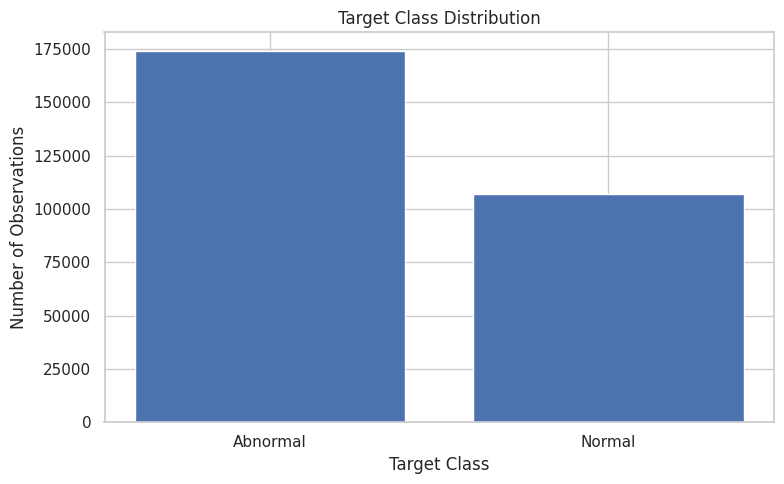

In [60]:
plt.figure(figsize=(8, 5))

plt.bar(
    class_distribution["Class"],
    class_distribution["Count"]
)

plt.xlabel("Target Class")
plt.ylabel("Number of Observations")
plt.title("Target Class Distribution")

plt.tight_layout()
plt.show()

### 1.8.4 Class Imbalance Assessment

In [61]:
majority_count = class_counts.max()
minority_count = class_counts.min()

majority_class = class_counts.idxmax()
minority_class = class_counts.idxmin()

imbalance_ratio = majority_count / minority_count
minority_percentage = (minority_count / len(y)) * 100

imbalance_summary = pd.DataFrame({
    "Metric": [
        "Majority Class",
        "Majority Count",
        "Minority Class",
        "Minority Count",
        "Majority Percentage",
        "Minority Percentage",
        "Majority-to-Minority Ratio"
    ],
    "Value": [
        majority_class,
        majority_count,
        minority_class,
        minority_count,
        (majority_count / len(y)) * 100,
        minority_percentage,
        imbalance_ratio
    ]
})

display(imbalance_summary)

,Metric,Value
0,Majority Class,Abnormal
1,Majority Count,174101
2,Minority Class,Normal
3,Minority Count,106884
4,Majority Percentage,61.960959
5,Minority Percentage,38.039041
6,Majority-to-Minority Ratio,1.628878


In [62]:
majority_baseline_accuracy = majority_count / len(y)

print(
    f"Majority-class baseline accuracy: "
    f"{majority_baseline_accuracy:.4f}"
)

print(
    f"Majority-class baseline accuracy: "
    f"{majority_baseline_accuracy * 100:.2f}%"
)

Majority-class baseline accuracy: 0.6196
Majority-class baseline accuracy: 61.96%


In [63]:
assert majority_count + minority_count == len(y)
assert imbalance_ratio >= 1
assert 0 < minority_percentage <= 50

print("Class imbalance assessment completed successfully.")

Class imbalance assessment completed successfully.


In [64]:
print("=" * 60)
print("1.8 TARGET VARIABLE IDENTIFICATION — FINAL STATUS")
print("=" * 60)

print(f"Target column:             {TARGET_COLUMN}")
print(f"Target classes:            {sorted(actual_target_classes)}")
print(f"Binary encoding:           Normal=0, Abnormal=1")
print(f"Majority class:            {majority_class}")
print(f"Minority class:            {minority_class}")
print(f"Imbalance ratio:           {imbalance_ratio:.4f}")
print(f"Minority percentage:       {minority_percentage:.2f}%")

print("\nTarget Variable Identification completed successfully.")

1.8 TARGET VARIABLE IDENTIFICATION — FINAL STATUS
Target column:             label
Target classes:            ['Abnormal', 'Normal']
Binary encoding:           Normal=0, Abnormal=1
Majority class:            Abnormal
Minority class:            Normal
Imbalance ratio:           1.6289
Minority percentage:       38.04%

Target Variable Identification completed successfully.


## 1.9 Exploratory Data Analysis (EDA)

### 1.9.1 Target Distribution

In [65]:
target_distribution = (
    df_working["label"]
    .value_counts()
    .rename_axis("Target_Class")
    .reset_index(name="Count")
)

target_distribution["Percentage"] = (
    target_distribution["Count"]
    / len(df_working)
    * 100
)

display(target_distribution)

,Target_Class,Count,Percentage
0,Abnormal,174101,61.960959
1,Normal,106884,38.039041


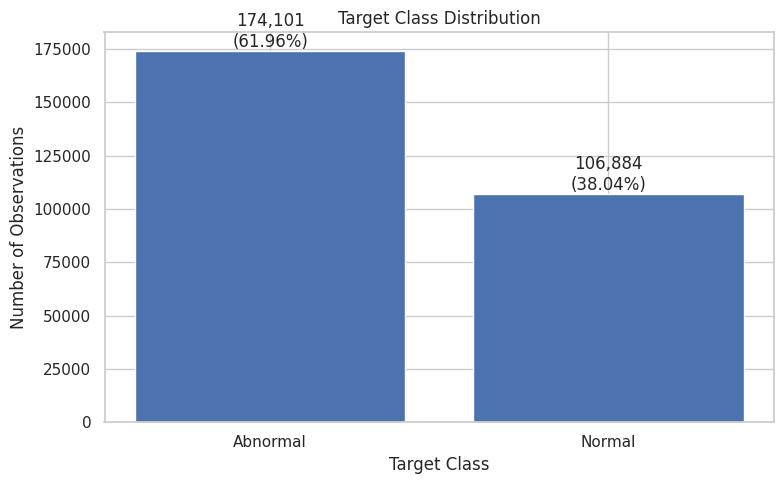

In [66]:
plt.figure(figsize=(8, 5))

bars = plt.bar(
    target_distribution["Target_Class"],
    target_distribution["Count"]
)

plt.xlabel("Target Class")
plt.ylabel("Number of Observations")
plt.title("Target Class Distribution")

for bar, count, percentage in zip(
    bars,
    target_distribution["Count"],
    target_distribution["Percentage"]
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{count:,}\n({percentage:.2f}%)",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

#### Distribution using binary target

In [67]:
binary_target_distribution = (
    y_binary
    .value_counts()
    .sort_index()
    .rename_axis("Encoded_Target")
    .reset_index(name="Count")
)

binary_target_distribution["Percentage"] = (
    binary_target_distribution["Count"]
    / len(y_binary)
    * 100
)

display(binary_target_distribution)

,Encoded_Target,Count,Percentage
0,0,106884,38.039041
1,1,174101,61.960959


In [68]:
assert target_distribution["Count"].sum() == len(df_working)
assert abs(target_distribution["Percentage"].sum() - 100) < 1e-6

assert set(df_working["label"].unique()) == {
    "Normal",
    "Abnormal"
}

print("Target distribution verified successfully.")

Target distribution verified successfully.


### Target Distribution Insights

The dataset contains two target classes: Normal and Abnormal.

Abnormal observations form the majority class, representing approximately 61.96% of the dataset, while Normal observations represent approximately 38.04%.

This distribution indicates moderate class imbalance rather than an extreme imbalance. Therefore, accuracy should be interpreted alongside Precision, Recall, F1-Score, Specificity, and PR-AUC during model evaluation.

Because the project focuses on threshold optimization, the class distribution will also be considered when selecting a clinically appropriate decision threshold.

## 1.9.2 Numerical Feature Distributions

### 1.9.2.1 Distribution Summary

In [69]:
numerical_distribution_summary = df_working[numerical_features].describe().T

numerical_distribution_summary["Skewness"] = (
    df_working[numerical_features].skew()
)

numerical_distribution_summary["Missing"] = (
    df_working[numerical_features].isna().sum()
)

numerical_distribution_summary = numerical_distribution_summary[
    [
        "count",
        "mean",
        "std",
        "min",
        "25%",
        "50%",
        "75%",
        "max",
        "Skewness",
        "Missing"
    ]
]

display(numerical_distribution_summary)

,count,mean,std,min,25%,50%,75%,max,Skewness,Missing
age,280985.0,49.665865,21.682350,2.000000,32.000000,50.000000,67.000000,89.000000,-0.058827,0
age_normalized,280985.0,0.547883,0.249222,0.000000,0.344827,0.551724,0.747126,1.000000,-0.058827,0
bmi,280985.0,27.490663,7.040373,10.010000,22.100000,27.320000,32.700000,95.690000,0.308086,0
hypertension,280985.0,0.128218,0.187346,0.000000,0.000000,0.071429,0.217063,1.000000,2.909880,0
heart_disease,280985.0,0.073390,0.138243,0.000000,0.000000,0.007299,0.115053,1.000000,4.402708,0
HbA1c_level,280985.0,5.947475,0.954072,3.500000,5.384805,5.800000,6.865766,9.000000,-0.194985,0
glucose,280985.0,135.258646,38.477865,70.000000,100.000000,138.000000,160.000000,300.000000,0.380192,0
cholesterol,280985.0,224.045525,35.525530,150.000000,202.000000,225.000000,243.000000,300.000000,0.032259,0
sleep_hours,280985.0,6.954652,1.426412,4.000000,6.200000,6.975185,7.700000,10.000000,0.044339,0
triglycerides,280985.0,178.995744,67.336085,50.000000,129.000000,179.000000,242.000000,400.000000,-0.068191,0


### 1.9.2.2 Skewness Analysis

In [70]:
skewness_summary = (
    df_working[numerical_features]
    .skew()
    .sort_values(ascending=False)
    .rename("Skewness")
    .reset_index()
)

skewness_summary.columns = [
    "Feature",
    "Skewness"
]

skewness_summary["Distribution"] = np.select(
    [
        skewness_summary["Skewness"] > 1,
        skewness_summary["Skewness"] < -1
    ],
    [
        "Highly Right-Skewed",
        "Highly Left-Skewed"
    ],
    default="Approximately Symmetric"
)

display(skewness_summary)

,Feature,Skewness,Distribution
0,heart_disease,4.402708,Highly Right-Skewed
1,hypertension,2.909880,Highly Right-Skewed
2,blood_pressure,0.465468,Approximately Symmetric
3,glucose,0.380192,Approximately Symmetric
4,bmi,0.308086,Approximately Symmetric
5,sleep_hours,0.044339,Approximately Symmetric
6,cholesterol,0.032259,Approximately Symmetric
7,systolic_bp,0.013176,Approximately Symmetric
8,salt_intake,0.008539,Approximately Symmetric
9,alcohol_intake,-0.000737,Approximately Symmetric


### 1.9.2.3 Distribution Visualization

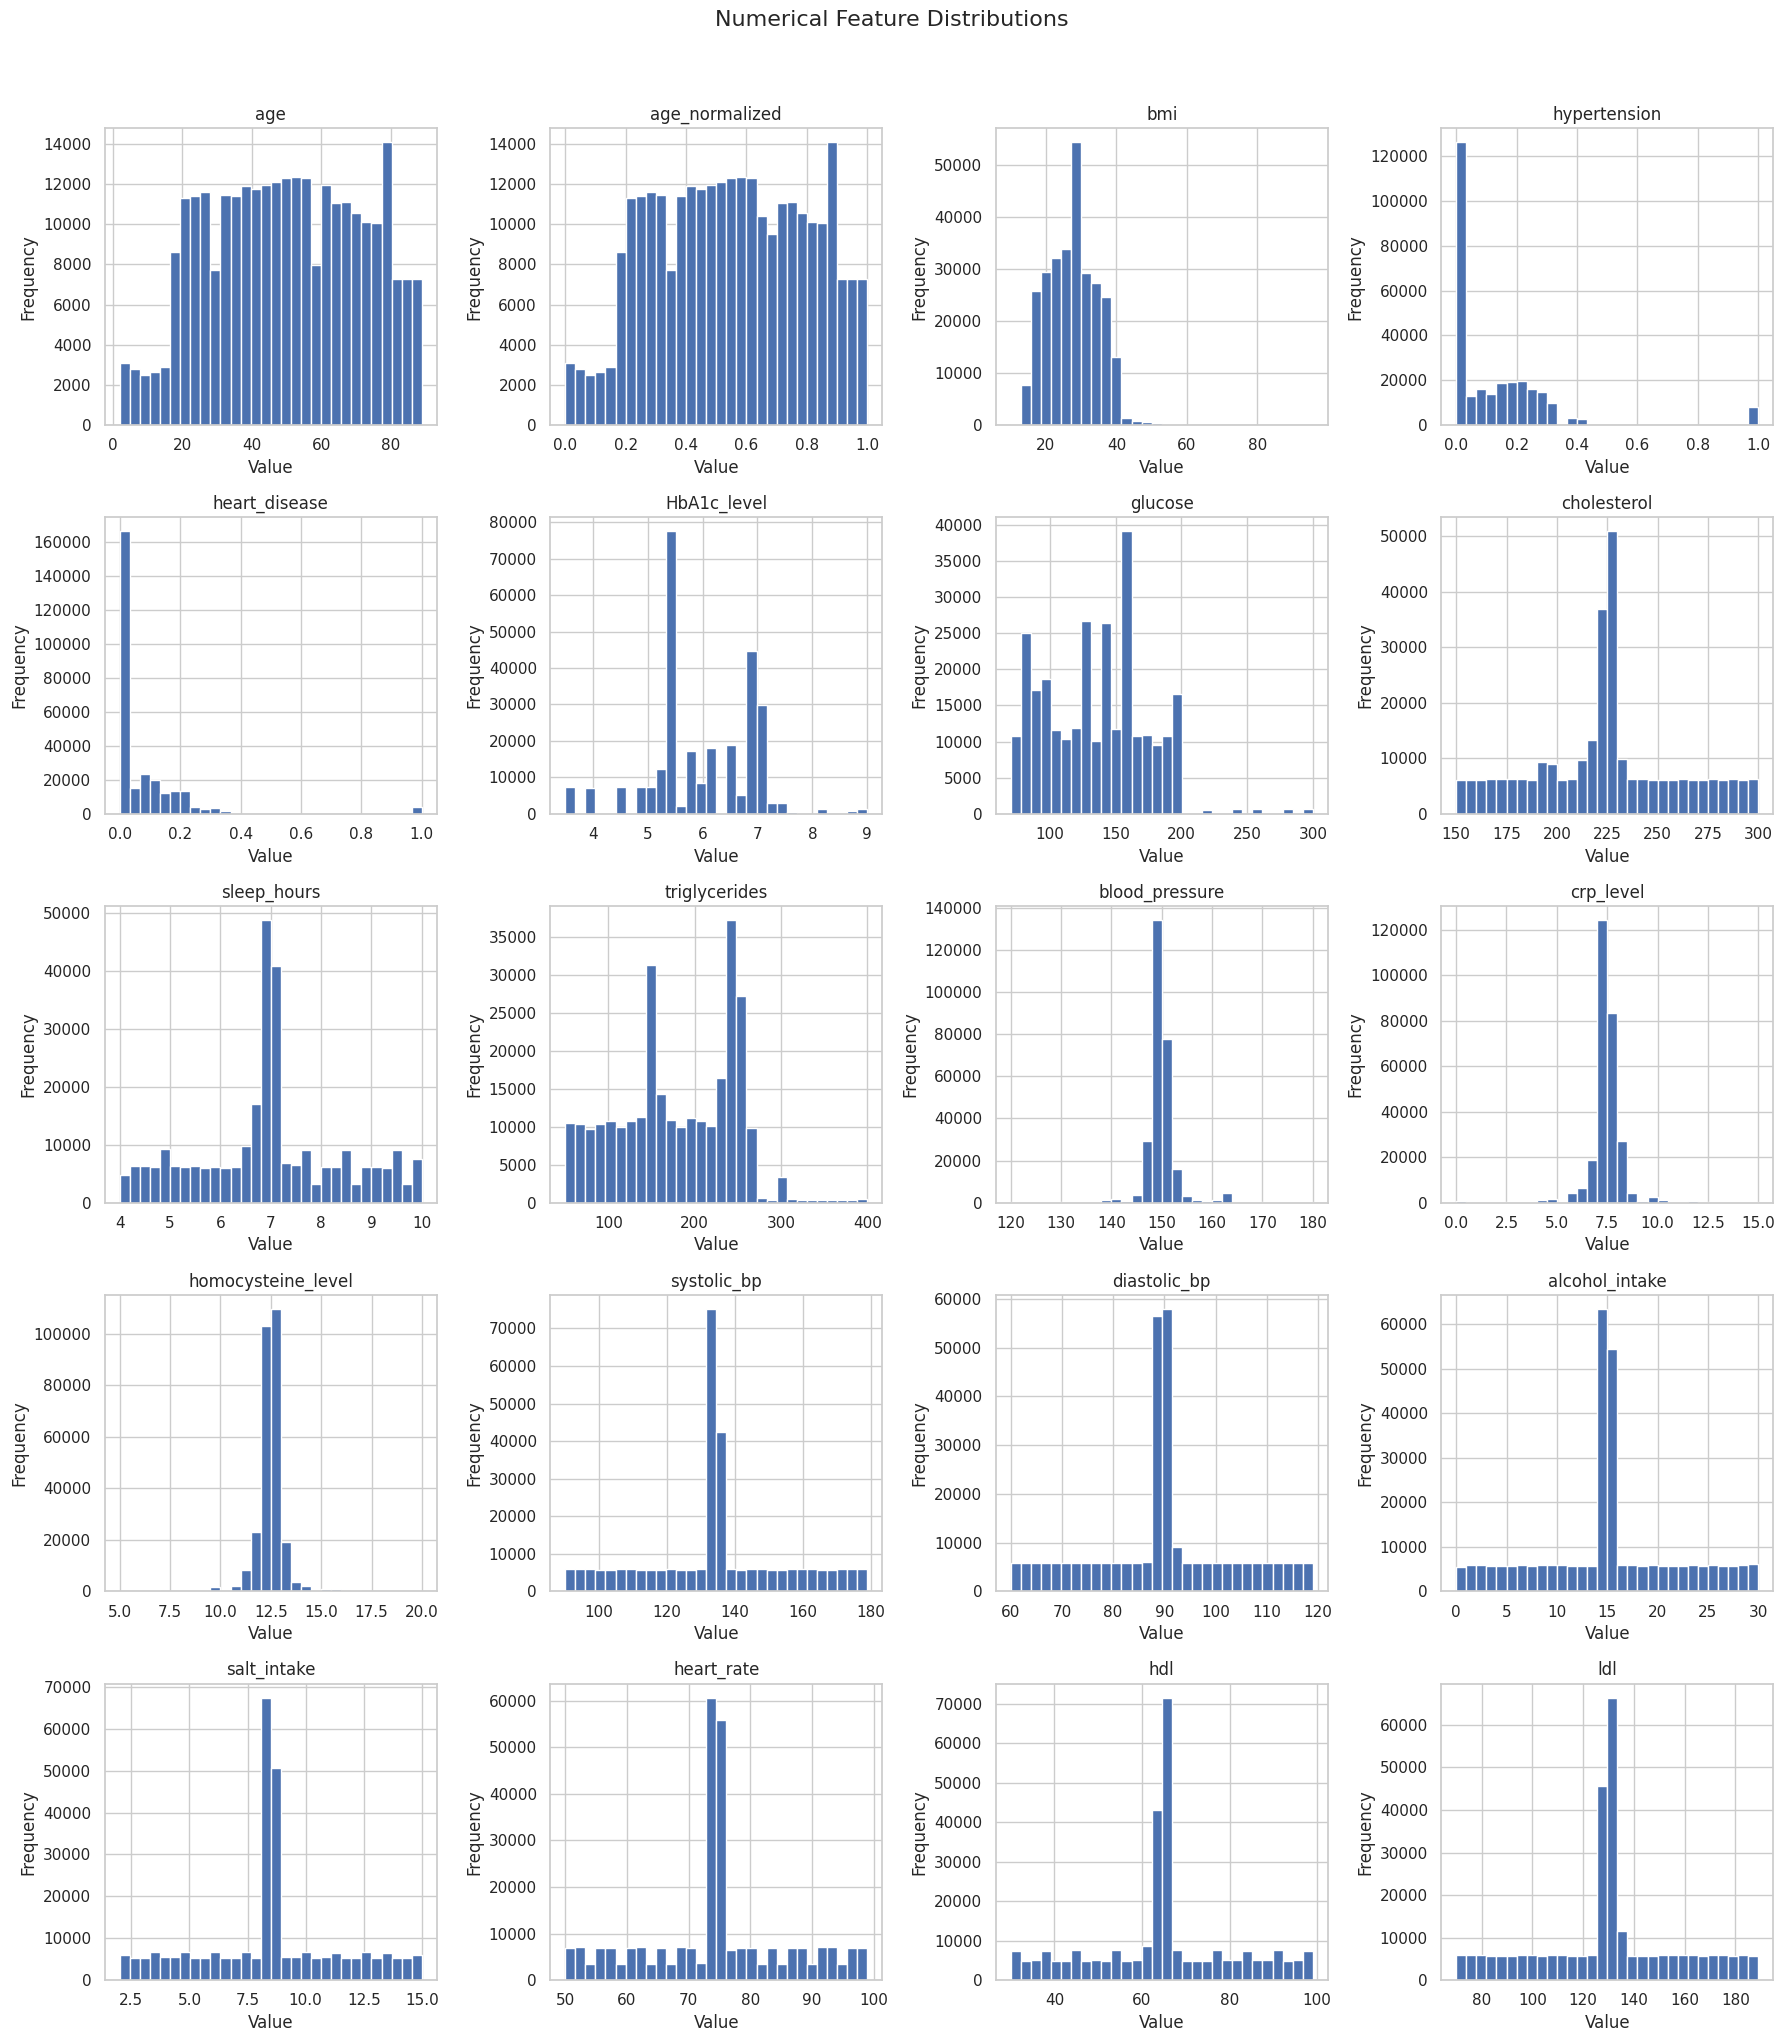

In [71]:
n_features = len(numerical_features)
n_cols = 4
n_rows = int(np.ceil(n_features / n_cols))

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(18, 4 * n_rows)
)

axes = axes.flatten()

for i, feature in enumerate(numerical_features):
    axes[i].hist(
        df_working[feature],
        bins=30
    )

    axes[i].set_title(feature)
    axes[i].set_xlabel("Value")
    axes[i].set_ylabel("Frequency")

for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.suptitle(
    "Numerical Feature Distributions",
    fontsize=16,
    y=1.02
)

plt.tight_layout()
plt.show()

### 1.9.2.4 Range and Variability Analysis

In [72]:
range_summary = pd.DataFrame({
    "Feature": numerical_features,
    "Minimum": df_working[numerical_features].min().values,
    "Maximum": df_working[numerical_features].max().values,
    "Range": (
        df_working[numerical_features].max()
        - df_working[numerical_features].min()
    ).values,
    "Standard_Deviation": (
        df_working[numerical_features].std().values
    )
})

range_summary = range_summary.sort_values(
    by="Range",
    ascending=False
)

display(range_summary)

,Feature,Minimum,Maximum,Range,Standard_Deviation
9,triglycerides,50.000000,400.000000,350.000000,67.336085
6,glucose,70.000000,300.000000,230.000000,38.477865
7,cholesterol,150.000000,300.000000,150.000000,35.525530
19,ldl,70.000000,189.000000,119.000000,27.352521
13,systolic_bp,90.000000,179.000000,89.000000,20.542140
0,age,2.000000,89.000000,87.000000,21.682350
2,bmi,10.010000,95.690000,85.680000,7.040373
18,hdl,30.000000,99.000000,69.000000,15.938525
10,blood_pressure,120.000000,180.000000,60.000000,4.148644
14,diastolic_bp,60.000000,119.000000,59.000000,13.667219


In [73]:
assert len(numerical_features) == 20
assert df_working[numerical_features].isna().sum().sum() == 0
assert np.isfinite(
    df_working[numerical_features].to_numpy()
).all()

print("Numerical feature distribution analysis completed successfully.")
print(f"Numerical features analyzed: {len(numerical_features)}")

Numerical feature distribution analysis completed successfully.
Numerical features analyzed: 20


### Numerical Distribution Insights

The numerical features show different scales and distribution shapes across the dataset.

Several clinical measurements have naturally different ranges, such as age, BMI, glucose, cholesterol, blood pressure, and lipid measurements. Therefore, numerical scaling will be important for scale-sensitive models such as Logistic Regression.

Skewness is also examined to identify variables with asymmetric distributions. However, skewness alone is not considered a reason to remove observations or apply transformations.

Extreme values will be investigated separately during the outlier analysis stage. The current analysis is descriptive and does not modify the dataset.

These findings will inform the preprocessing pipeline while preserving the original observations and preventing data leakage.

### 1.9.3 Categorical Feature Distributions

#### 1.9.3.1 Categorical Feature Summary

In [74]:
categorical_distribution_summary = pd.DataFrame({
    "Feature": categorical_features,
    "Unique_Categories": [
        df_working[feature].nunique()
        for feature in categorical_features
    ],
    "Missing_Values": [
        df_working[feature].isna().sum()
        for feature in categorical_features
    ],
    "Most_Frequent_Category": [
        df_working[feature].mode().iloc[0]
        for feature in categorical_features
    ],
    "Most_Frequent_Count": [
        df_working[feature].value_counts().iloc[0]
        for feature in categorical_features
    ]
})

categorical_distribution_summary["Most_Frequent_Percentage"] = (
    categorical_distribution_summary["Most_Frequent_Count"]
    / len(df_working)
    * 100
)

display(categorical_distribution_summary)

,Feature,Unique_Categories,Missing_Values,Most_Frequent_Category,Most_Frequent_Count,Most_Frequent_Percentage
0,composite_key,192,0,Middle_Female_Overweight_Never_No,6097,2.169867
1,age_level,4,0,Mature,87632,31.187430
2,gender,2,0,Female,148763,52.943396
3,bmi_level,4,0,Obese,98377,35.011477
4,smoking,3,0,Never,127764,45.470043
5,diabetes,2,0,No,180351,64.185277
6,physical_activity,3,0,High,120019,42.713668
7,family_history,2,0,No,157182,55.939641
8,stress_level,3,0,High,101298,36.051035
9,low_hdl_cholesterol,2,0,No,225935,80.408207


### 1.9.3.2 Cardinality Analysis

In [75]:
cardinality_summary = (
    categorical_distribution_summary[
        ["Feature", "Unique_Categories"]
    ]
    .sort_values(
        by="Unique_Categories",
        ascending=False
    )
)

display(cardinality_summary)

,Feature,Unique_Categories
0,composite_key,192
17,sublabel,8
16,disease_flags,8
3,bmi_level,4
1,age_level,4
15,source_dataset,3
4,smoking,3
13,education_level,3
12,sugar_consumption,3
6,physical_activity,3


### 1.9.3.3 Category Frequency Tables

In [76]:
for feature in categorical_features:
    print(f"\n{'=' * 70}")
    print(f"Feature: {feature}")
    print(f"{'=' * 70}")

    frequency_table = (
        df_working[feature]
        .value_counts(dropna=False)
        .rename_axis("Category")
        .reset_index(name="Count")
    )

    frequency_table["Percentage"] = (
        frequency_table["Count"]
        / len(df_working)
        * 100
    )

    display(frequency_table)


Feature: composite_key


,Category,Count,Percentage
0,Middle_Female_Overweight_Never_No,6097,2.169867
1,Mature_Female_Overweight_Never_No,5778,2.056338
2,Middle_Female_Obese_Never_No,5020,1.786572
3,Mature_Female_Obese_Never_No,4986,1.774472
4,Middle_Female_Normal_Never_No,4806,1.710412
...,...,...,...
187,Young_Female_Underweight_Current_No,184,0.065484
188,Young_Female_Underweight_Never_Yes,176,0.062637
189,Young_Male_Underweight_Former_Yes,175,0.062281
190,Young_Male_Underweight_Current_Yes,161,0.057298



Feature: age_level


,Category,Count,Percentage
0,Mature,87632,31.187430
1,Middle,85344,30.373152
2,Senior,70225,24.992437
3,Young,37784,13.446981



Feature: gender


...

,Category,Count,Percentage
0,"0,0,0",106884,38.039041
1,"0,0,1",69806,24.843319
2,"1,0,1",66473,23.657135
3,"1,0,0",31918,11.359325
4,"0,1,0",2595,0.923537
5,"1,1,0",1398,0.497535
6,"0,1,1",1066,0.379380
7,"1,1,1",845,0.300728



Feature: sublabel


,Category,Count,Percentage
0,N,106884,38.039041
1,HY,69806,24.843319
2,DI_HY,66473,23.657135
3,DI,31918,11.359325
4,HT,2595,0.923537
5,DI_HT,1398,0.497535
6,HT_HY,1066,0.379380
7,DI_HT_HY,845,0.300728



Feature: label


,Category,Count,Percentage
0,Abnormal,174101,61.960959
1,Normal,106884,38.039041


### 1.9.3.4 Visualize Categorical Distributions

In [77]:
top_categorical_features = [
    feature
    for feature in categorical_features
    if df_working[feature].nunique() <= 8
]

print(
    f"Categorical features with <= 8 categories: "
    f"{len(top_categorical_features)}"
)

print(top_categorical_features)

Categorical features with <= 8 categories: 18
['age_level', 'gender', 'bmi_level', 'smoking', 'diabetes', 'physical_activity', 'family_history', 'stress_level', 'low_hdl_cholesterol', 'high_ldl_cholesterol', 'high_blood_pressure', 'sugar_consumption', 'education_level', 'employment_status', 'source_dataset', 'disease_flags', 'sublabel', 'label']


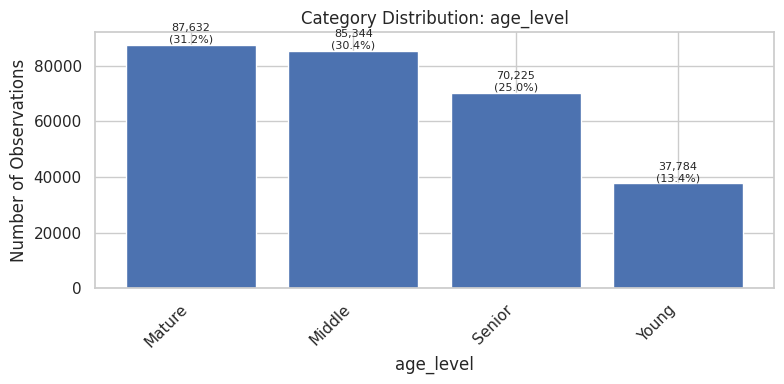

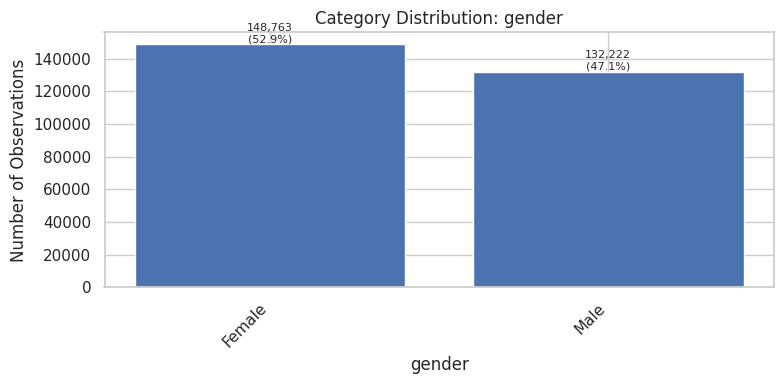

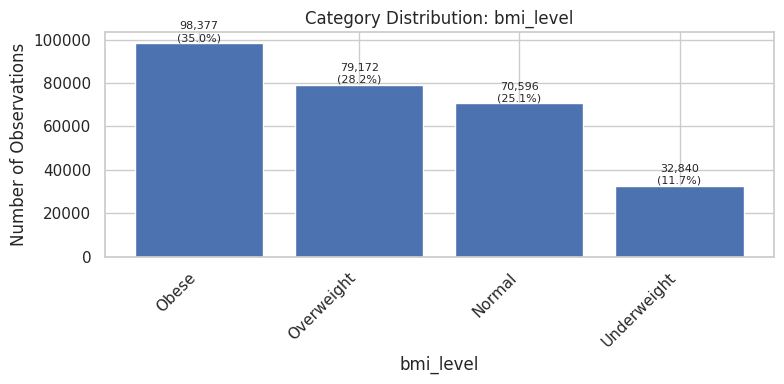

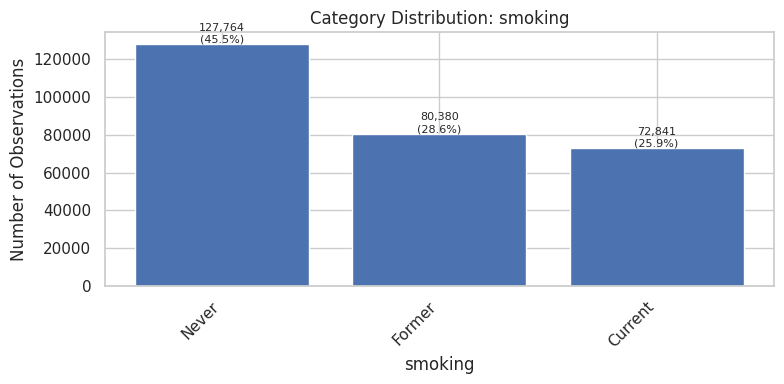

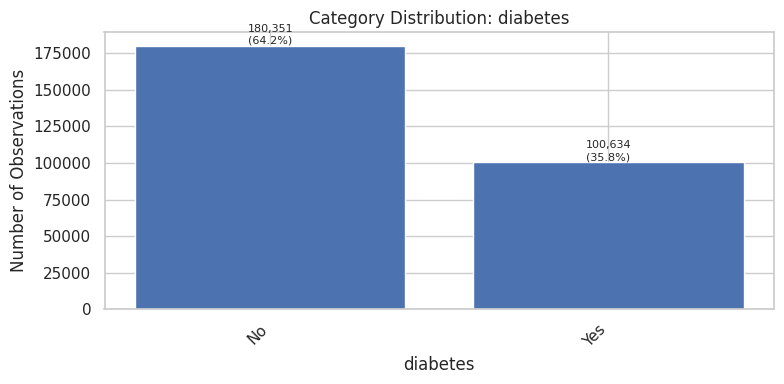

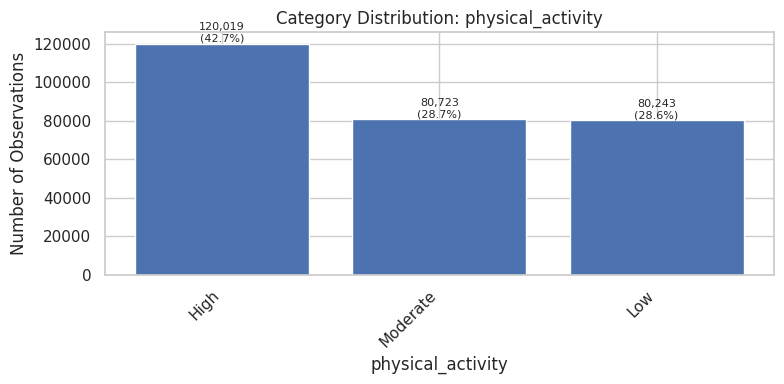

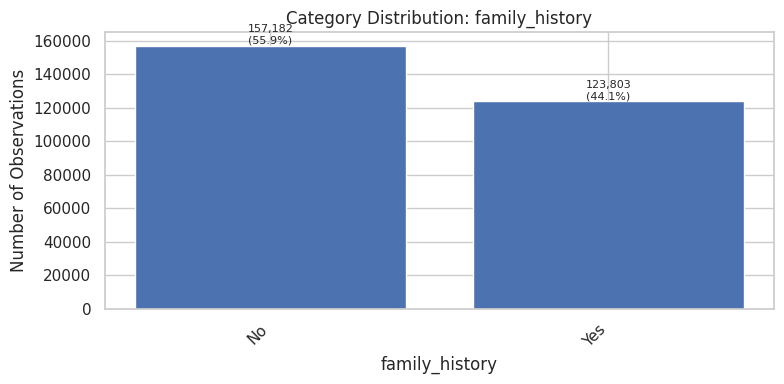

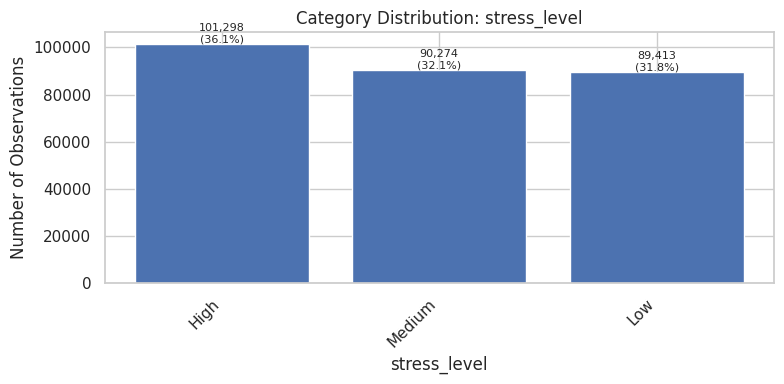

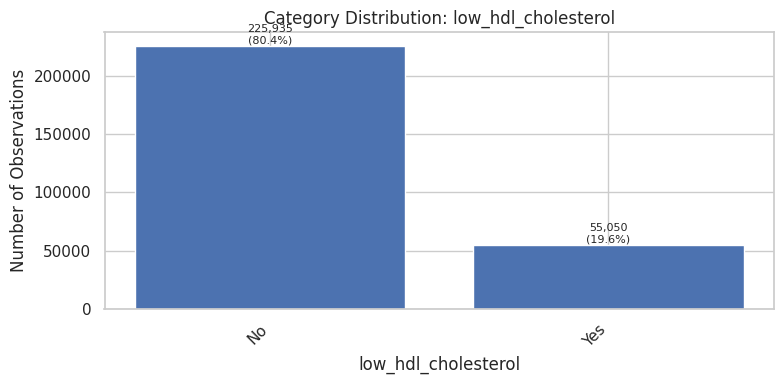

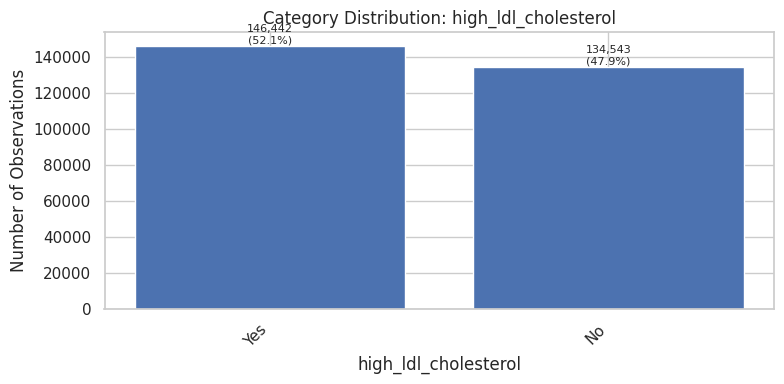

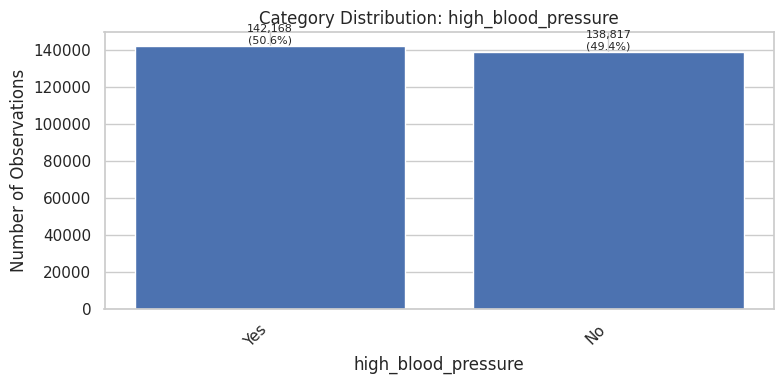

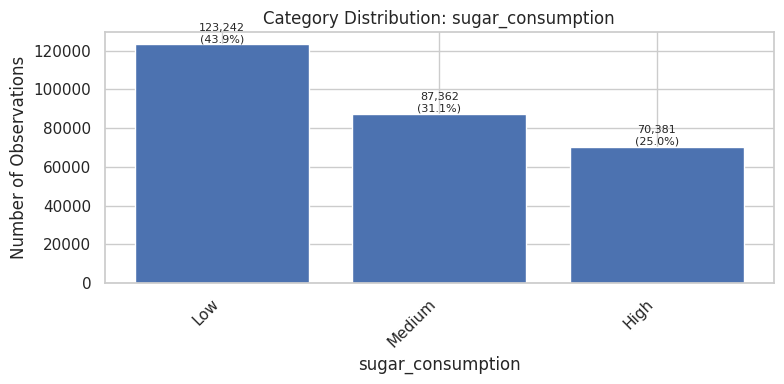

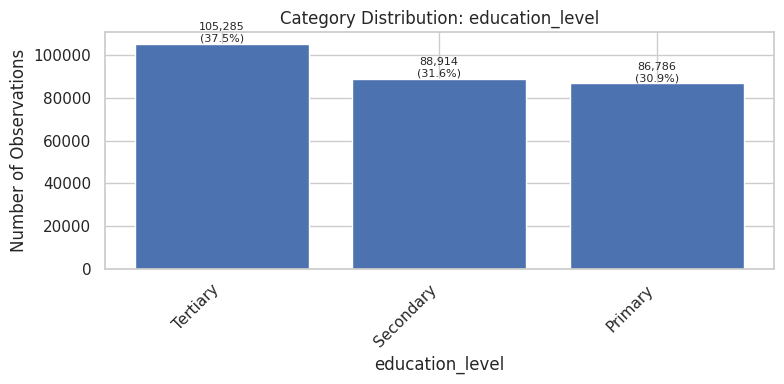

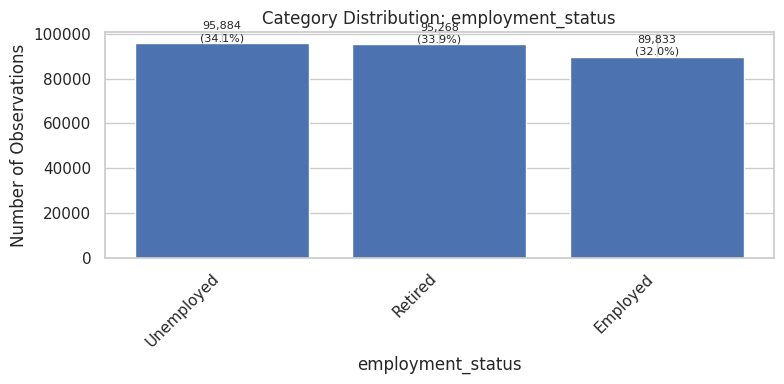

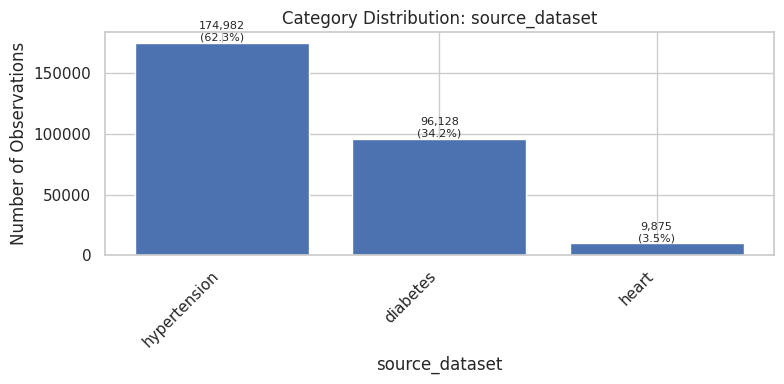

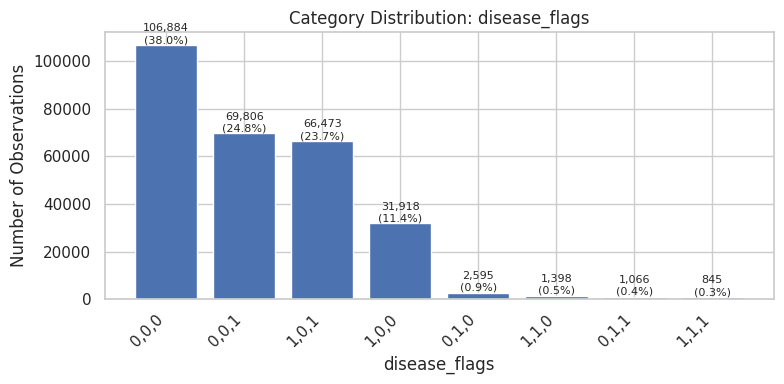

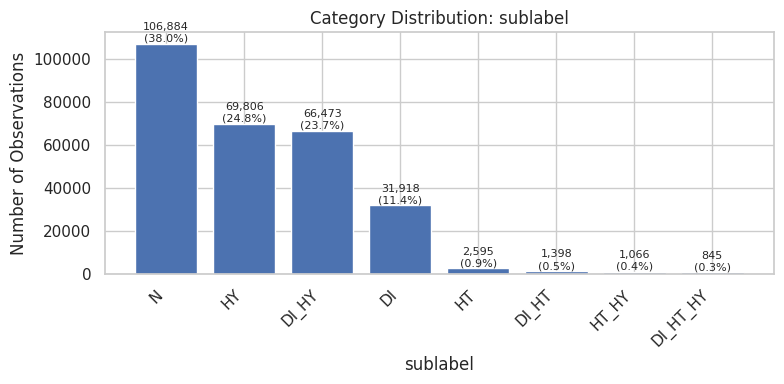

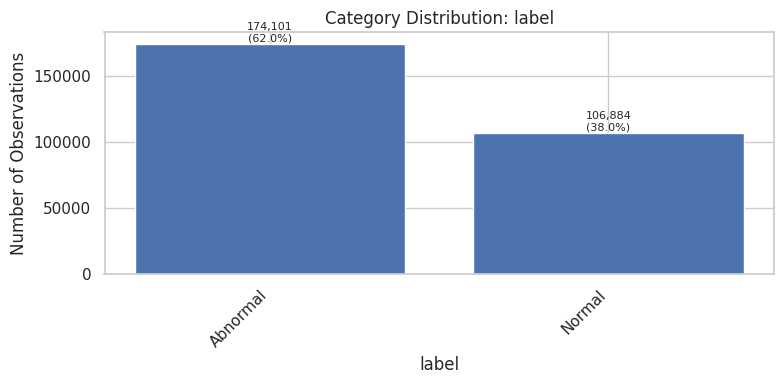

In [78]:
for feature in top_categorical_features:
    counts = df_working[feature].value_counts()

    plt.figure(figsize=(8, 4))

    bars = plt.bar(
        counts.index.astype(str),
        counts.values
    )

    plt.title(f"Category Distribution: {feature}")
    plt.xlabel(feature)
    plt.ylabel("Number of Observations")
    plt.xticks(rotation=45, ha="right")

    for bar, count in zip(bars, counts.values):
        percentage = count / len(df_working) * 100

        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
            f"{count:,}\n({percentage:.1f}%)",
            ha="center",
            va="bottom",
            fontsize=8
        )

    plt.tight_layout()
    plt.show()

### 1.9.3.5 High-Cardinality Inspection

In [79]:
HIGH_CARDINALITY_THRESHOLD = 20

high_cardinality_features = (
    categorical_distribution_summary[
        categorical_distribution_summary["Unique_Categories"]
        > HIGH_CARDINALITY_THRESHOLD
    ]
)

display(high_cardinality_features)

,Feature,Unique_Categories,Missing_Values,Most_Frequent_Category,Most_Frequent_Count,Most_Frequent_Percentage
0,composite_key,192,0,Middle_Female_Overweight_Never_No,6097,2.169867


In [80]:
assert len(categorical_features) == 19

assert (
    categorical_distribution_summary["Missing_Values"]
    .sum()
    == 0
)

assert (
    categorical_distribution_summary["Unique_Categories"]
    >= 2
).all()

print("Categorical feature distribution analysis completed successfully.")
print(f"Categorical features analyzed: {len(categorical_features)}")

Categorical feature distribution analysis completed successfully.
Categorical features analyzed: 19


### Categorical Distribution Insights

The dataset contains multiple categorical variables with different levels of cardinality.

Most clinical and demographic categorical variables contain a small number of categories and can be handled using categorical encoding techniques.

The `composite_key` feature has relatively high cardinality and represents a combination of other attributes. It will therefore be treated as metadata/grouping information rather than a direct predictive feature.

The `sublabel` and `disease_flags` variables are strongly related to the target definition and represent potential target leakage. They should not be included as model predictors.

The `source_dataset` feature also requires careful consideration because it identifies the originating dataset and may introduce source-related information into the prediction process.

No categorical observations are removed based solely on their frequency. Feature selection and leakage decisions will be finalized during preprocessing.

### 1.9.4 Feature vs Target Analysis

### 1.9.4.1 Numerical Features vs Target

Class-wise Summary

In [81]:
numerical_target_summary = (
    df_working
    .groupby("label")[numerical_features]
    .agg(["mean", "median", "std"])
)

display(numerical_target_summary)

age                   age_normalized                            bmi                  hypertension  \
               mean median        std           mean    median       std       mean median       std         mean   
label                                                                                                               
Abnormal  54.036617   55.0  20.321704       0.598122  0.609195  0.233583  27.878518  27.70  7.228029     0.191672   
Normal    42.546443   42.0  21.941276       0.466051  0.459770  0.252198  26.858895  27.32  6.675457     0.024858   

                             heart_disease                  HbA1c_level                         glucose         \
            median       std          mean median       std        mean    median       std        mean median   
label                                                                                                            
Abnormal  0.165398  0.209861       0.10979   0.08  0.162486    6.286106  6.750000  0.856204  136.653380  136.0   
Normal    0.000000  0.057358       0.01410   0.00  0.039527    5.395885  5.419802  0.841313  132.986794  140.0   

                    cholesterol                        sleep_hours                     triglycerides         \
                std        mean      median        std        mean    median       std          mean median   
label                                                                                                         
Abnormal  40.438704  224.616905  225.000000  41.349656    6.995076  7.000000  1.650417    159.914268  156.0   
Normal    34.930962  223.114816  225.071183  23.051589    6.888808  6.968389  0.951318    210.077141  241.5   

                    blood_pressure                       crp_level                     homocysteine_level             \
                std           mean      median       std      mean    median       std               mean     median   
label                                                                                                                  
Abnormal  64.505197     149.926928  149.807692  4.466371  7.461042  7.446517  1.119352          12.465352  12.441519   
Normal    59.858072     149.822488  149.587719  3.570160  7.534874  7.462859  0.811290          12.465282  12.508636   

                   systolic_bp                        diastolic_bp                       alcohol_intake             \
               std        mean      median        std         mean     median        std           mean     median   
label                                                                                                                
Abnormal  1.082095  134.518668  134.407710  24.178367    89.464616  89.519231  16.077665      14.973511  14.947588   
Normal    0.796806  134.220126  134.130435  12.531921    89.496435  89.504587   8.366935      15.051918  14.998050   

                   salt_intake                     heart_rate                              hdl                        \
               std        mean    median       std       mean     median        std       mean     median        std   
label                                                                                                                  
Abnormal  8.037569    8.483349  8.490022  3.482990  74.495524  74.487247  13.416277  64.578085  64.516058  18.768619   
Normal    4.172570    8.476063  8.477600  1.811903  74.500306  74.487247   6.974038  64.659744  64.716216   9.697346   

                 ldl                         
                mean      median        std  
label                                        
Abnormal  129.509748  129.565673  32.189972  
Normal    130.078036  130.217467  16.697112

Mean Difference

In [82]:
class_means = (
    df_working
    .groupby("label")[numerical_features]
    .mean()
    .T
)

class_means["Absolute_Mean_Difference"] = (
    class_means["Abnormal"] -
    class_means["Normal"]
).abs()

class_means["Percentage_Difference"] = (
    (
        class_means["Abnormal"] -
        class_means["Normal"]
    )
    / class_means["Normal"].replace(0, np.nan)
    * 100
)

class_means = class_means.sort_values(
    by="Absolute_Mean_Difference",
    ascending=False
)

display(class_means)

label,Abnormal,Normal,Absolute_Mean_Difference,Percentage_Difference
triglycerides,159.914268,210.077141,50.162873,-23.878311
age,54.036617,42.546443,11.490174,27.006191
glucose,136.653380,132.986794,3.666587,2.757106
cholesterol,224.616905,223.114816,1.502089,0.673236
bmi,27.878518,26.858895,1.019623,3.796220
HbA1c_level,6.286106,5.395885,0.890221,16.498148
ldl,129.509748,130.078036,0.568288,-0.436882
systolic_bp,134.518668,134.220126,0.298542,0.222427
hypertension,0.191672,0.024858,0.166814,671.060593
age_normalized,0.598122,0.466051,0.132071,28.338242


### 1.9.4.2 Numerical Distribution by Target

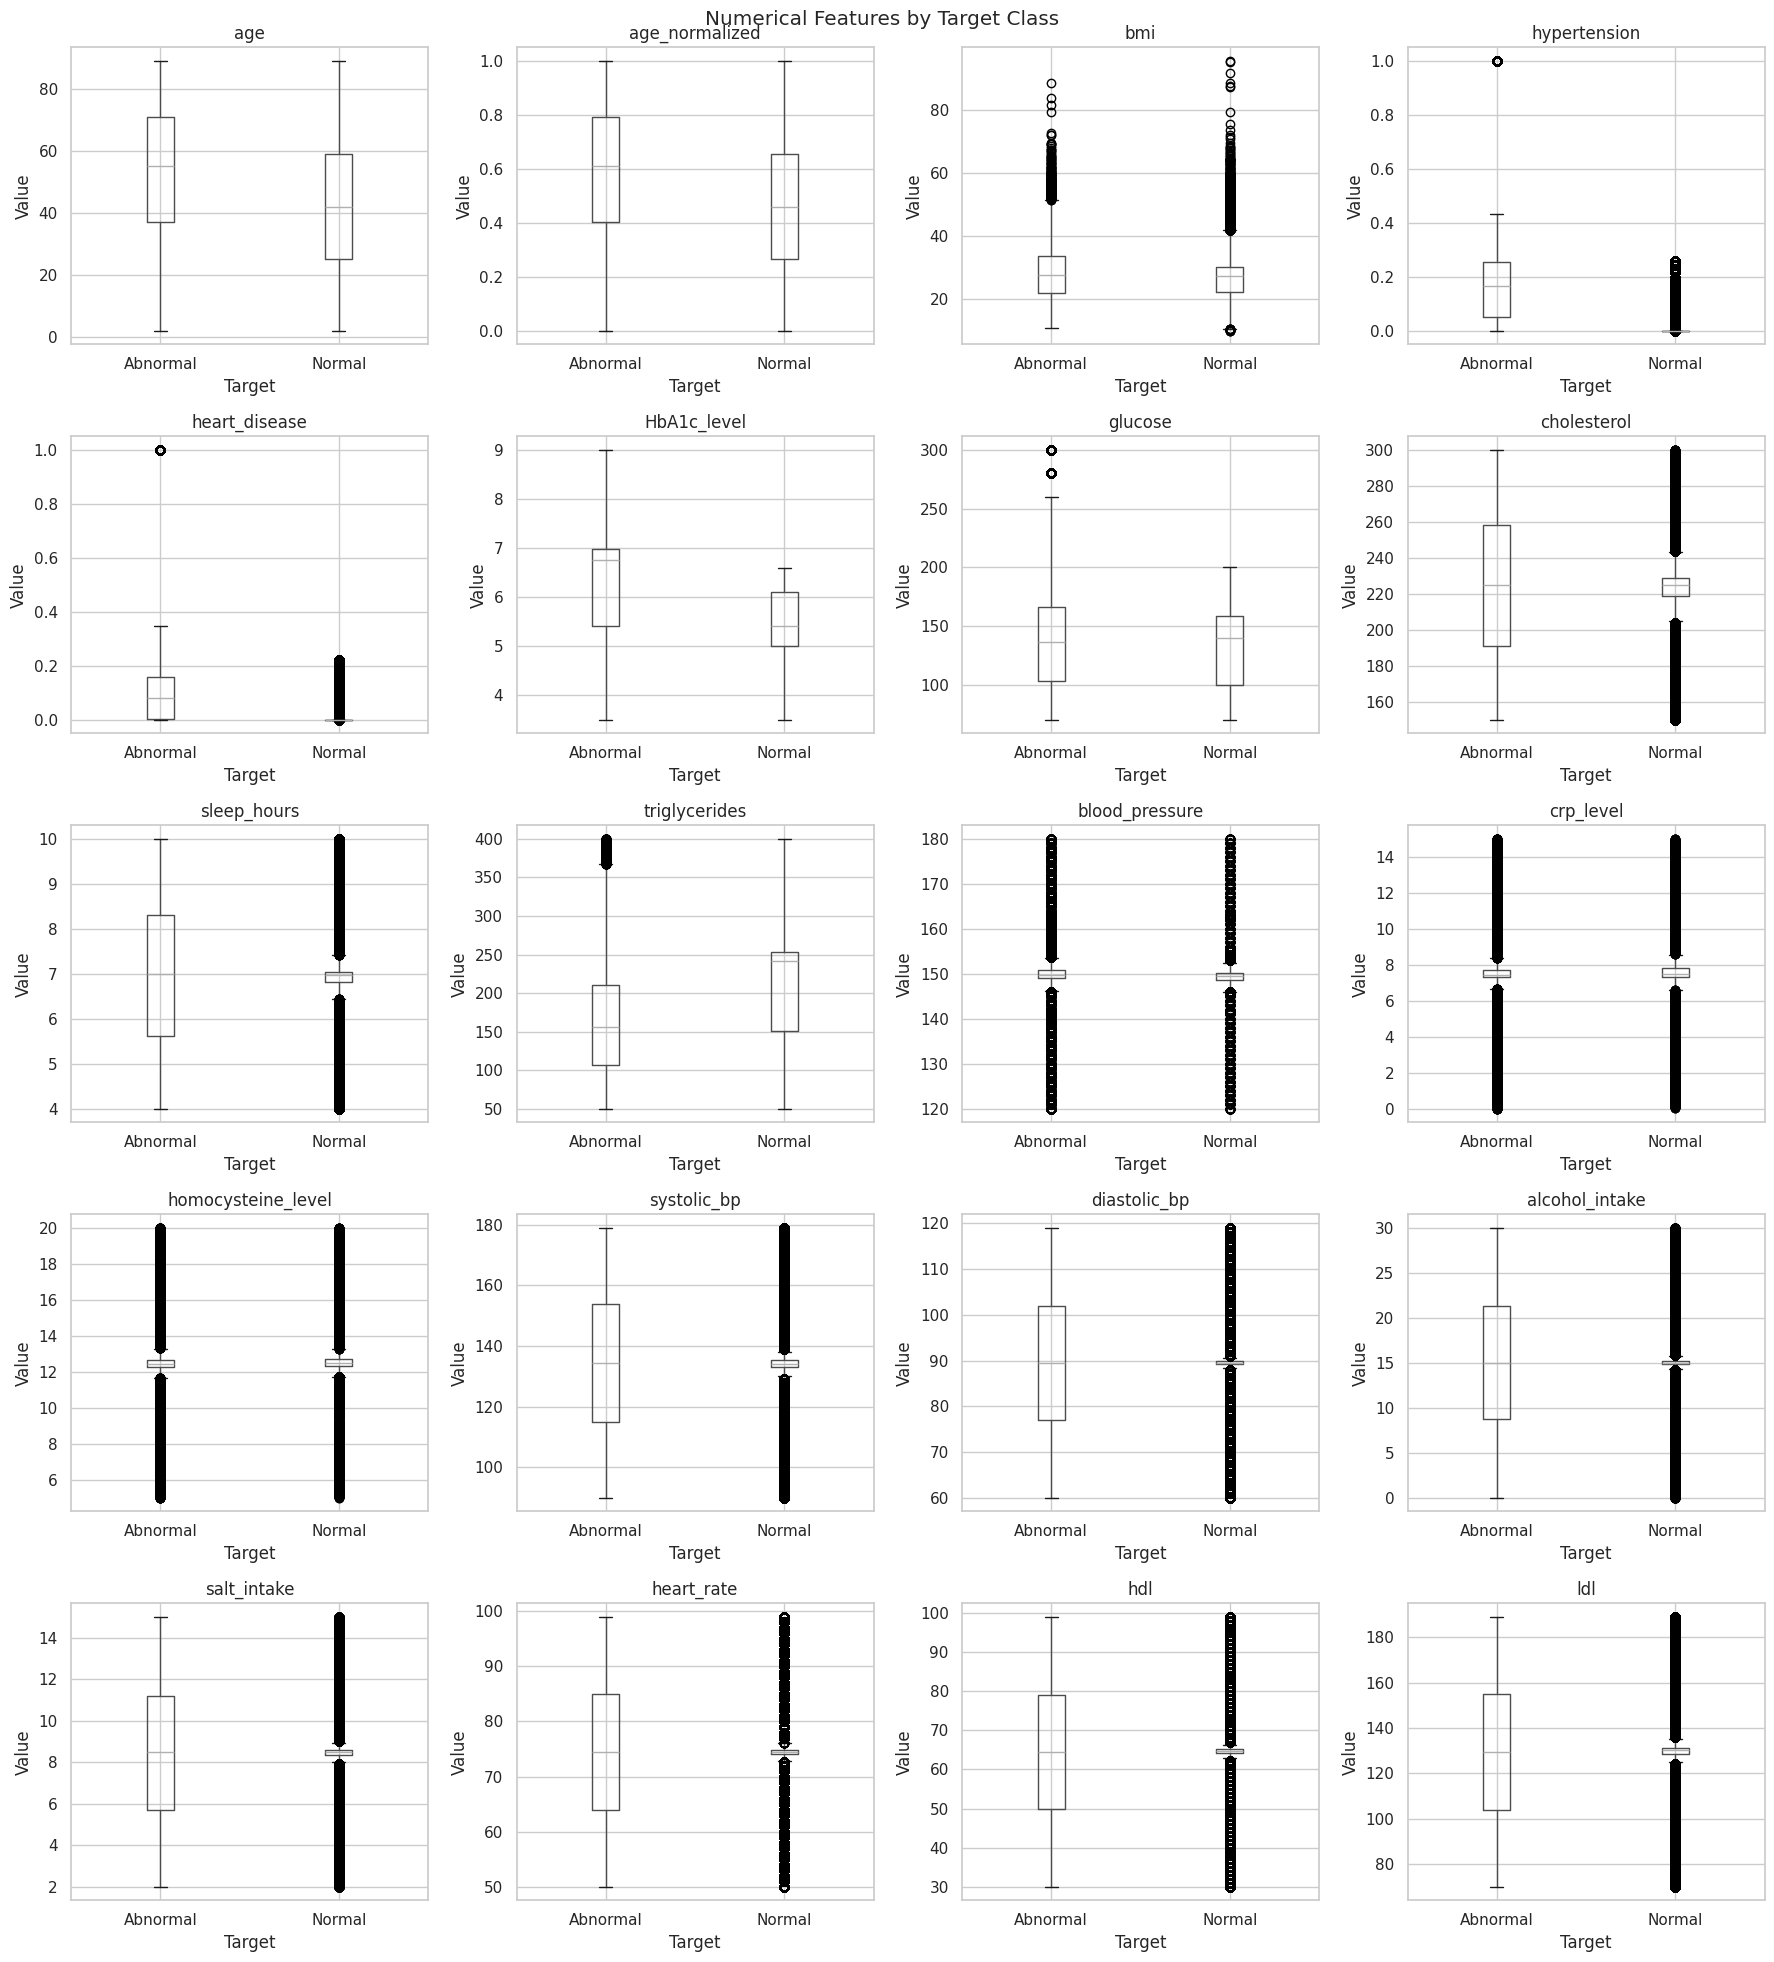

In [83]:
n_features = len(numerical_features)
n_cols = 4
n_rows = int(np.ceil(n_features / n_cols))

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(18, 4 * n_rows)
)

axes = axes.flatten()

for i, feature in enumerate(numerical_features):
    df_working.boxplot(
        column=feature,
        by="label",
        ax=axes[i]
    )

    axes[i].set_title(feature)
    axes[i].set_xlabel("Target")
    axes[i].set_ylabel("Value")

plt.suptitle("Numerical Features by Target Class")

for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

### 1.9.4.3 Categorical Features vs Target

In [84]:
categorical_analysis_features = [
    feature
    for feature in categorical_features
    if feature not in [
        "label",
        "sublabel",
        "disease_flags",
        "composite_key"
    ]
]

print(
    f"Categorical features included in target analysis: "
    f"{len(categorical_analysis_features)}"
)

print(categorical_analysis_features)

Categorical features included in target analysis: 15
['age_level', 'gender', 'bmi_level', 'smoking', 'diabetes', 'physical_activity', 'family_history', 'stress_level', 'low_hdl_cholesterol', 'high_ldl_cholesterol', 'high_blood_pressure', 'sugar_consumption', 'education_level', 'employment_status', 'source_dataset']


In [85]:
for feature in categorical_analysis_features:

    target_proportion = pd.crosstab(
        df_working[feature],
        df_working["label"],
        normalize="index"
    ) * 100

    print(f"\n{'=' * 70}")
    print(f"Target Distribution by: {feature}")
    print(f"{'=' * 70}")

    display(target_proportion.round(2))


Target Distribution by: age_level


label,Abnormal,Normal
age_level,,
Mature,64.41,35.59
Middle,59.30,40.70
Senior,76.29,23.71
Young,35.68,64.32



Target Distribution by: gender


label,Abnormal,Normal
gender,,
Female,58.90,41.10
Male,65.41,34.59



Target Distribution by: bmi_level


...

label,Abnormal,Normal
education_level,,
Primary,66.85,33.15
Secondary,64.22,35.78
Tertiary,56.02,43.98



Target Distribution by: employment_status


label,Abnormal,Normal
employment_status,,
Employed,64.65,35.35
Retired,61.43,38.57
Unemployed,59.97,40.03



Target Distribution by: source_dataset


label,Abnormal,Normal
source_dataset,,
diabetes,16.60,83.40
heart,80.00,20.00
hypertension,85.86,14.14


### 1.9.4.4 Categorical Feature Visualization

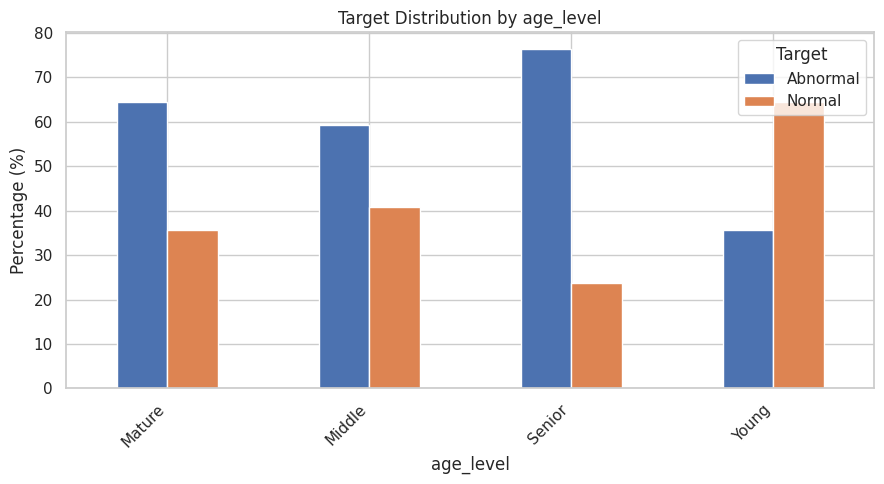

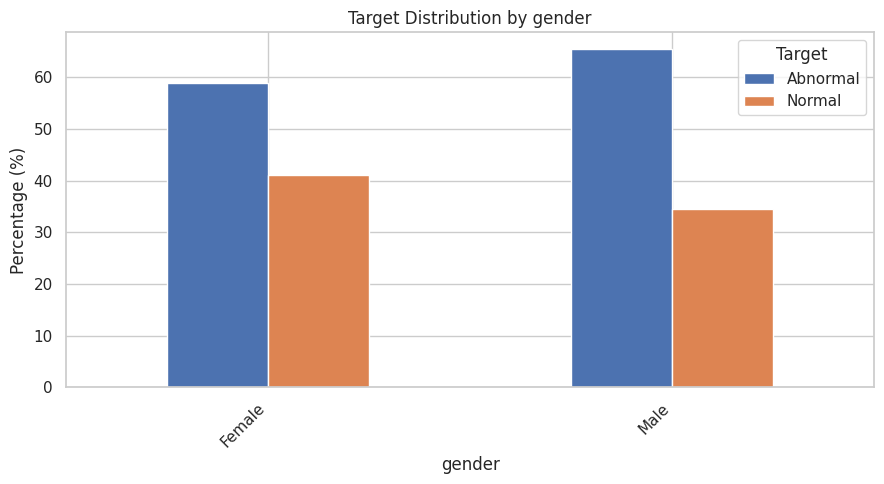

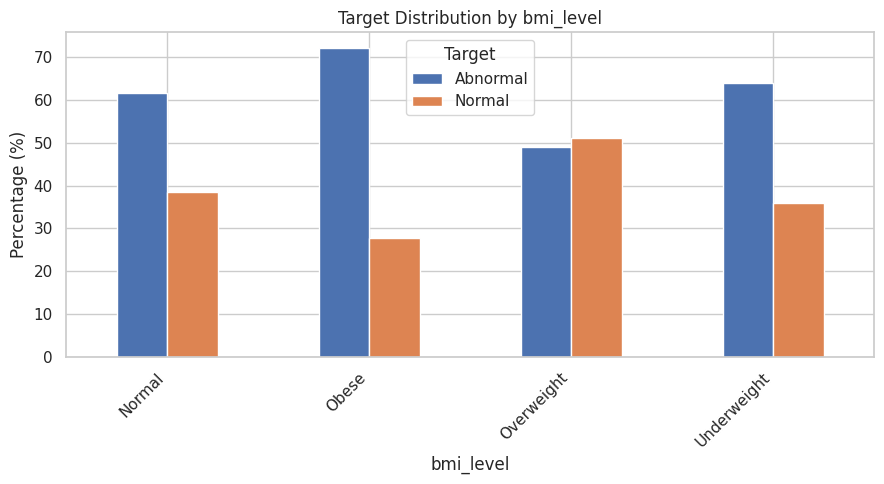

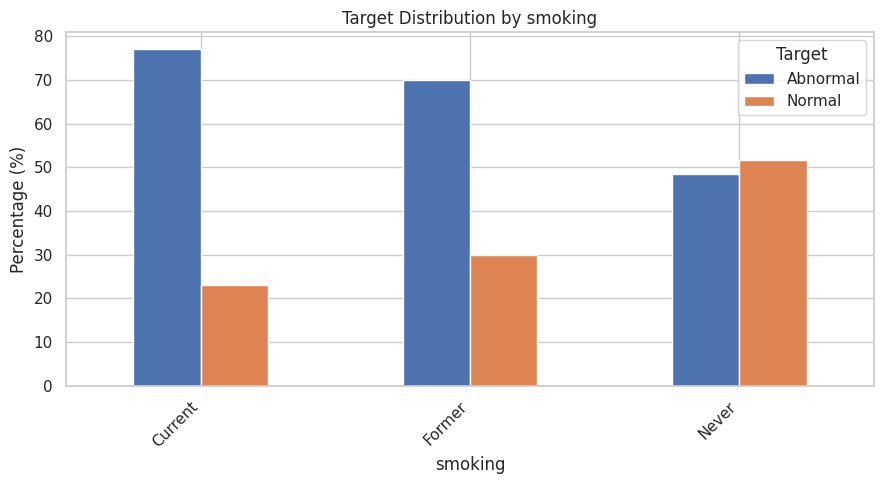

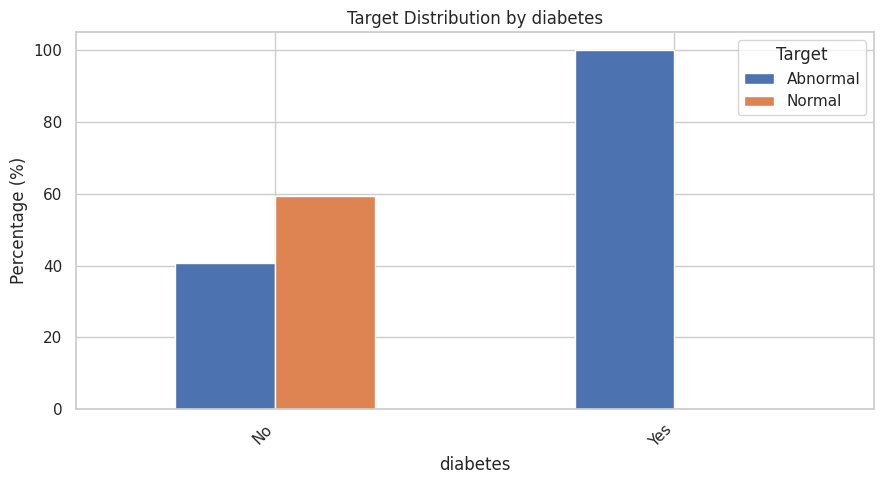

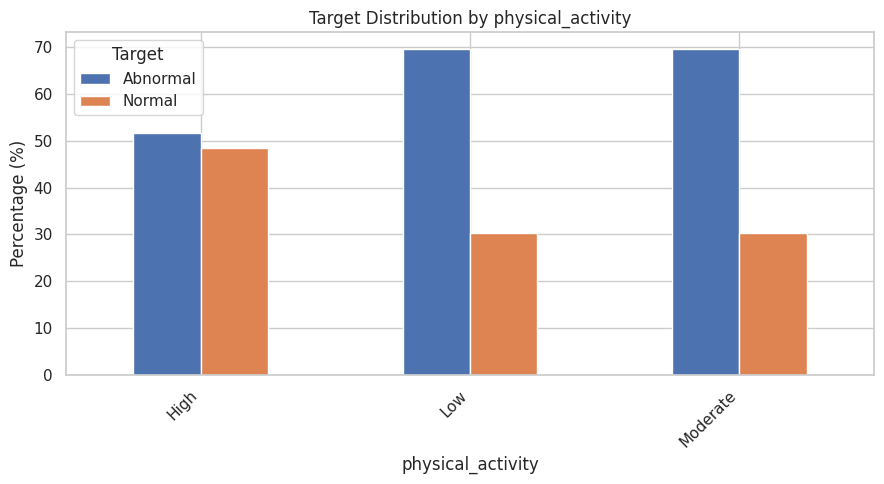

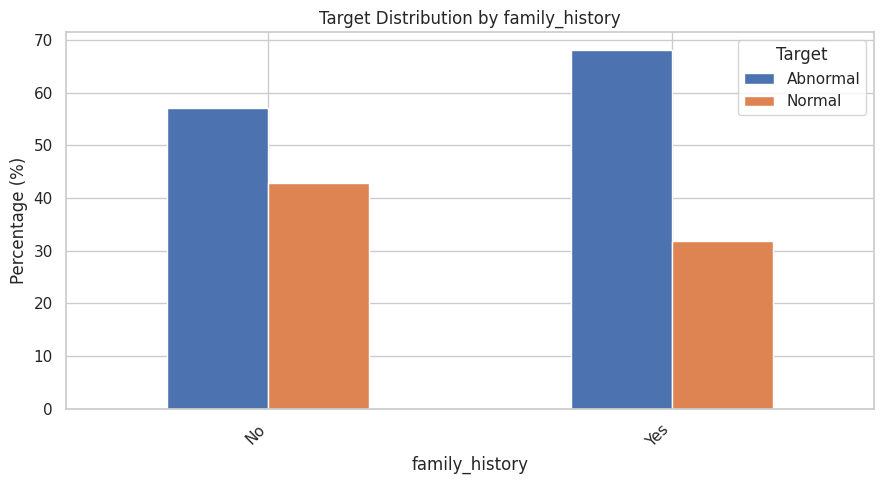

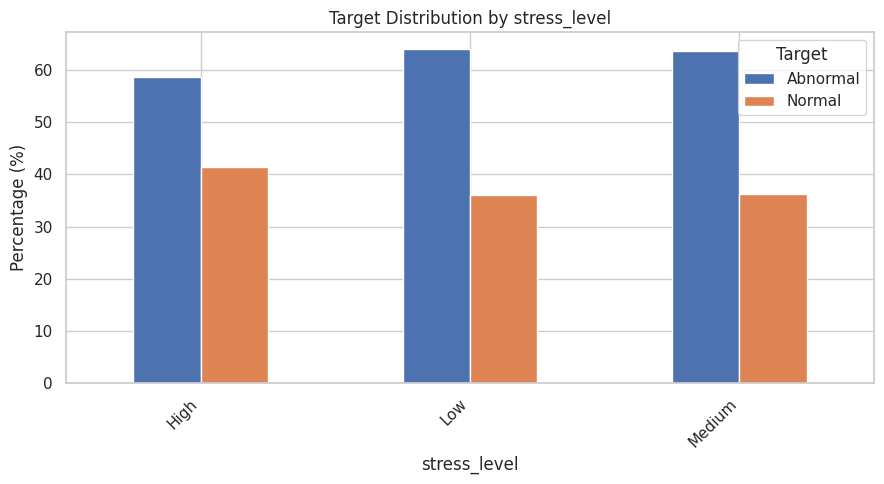

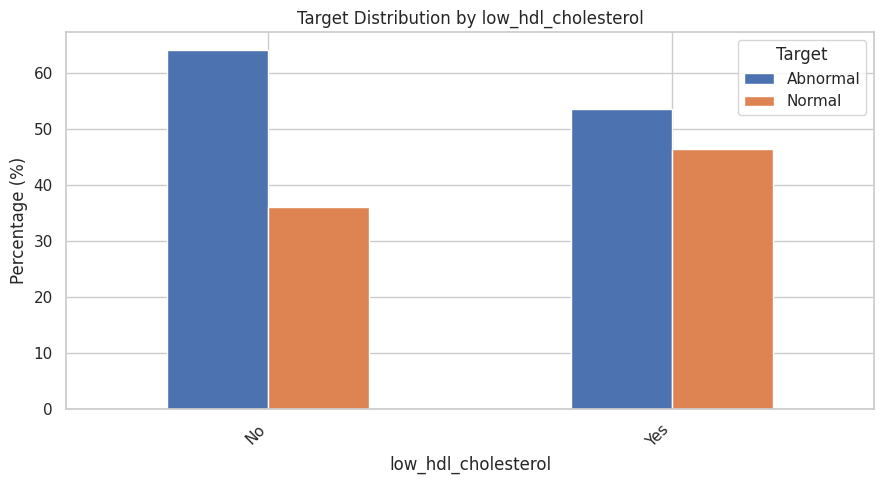

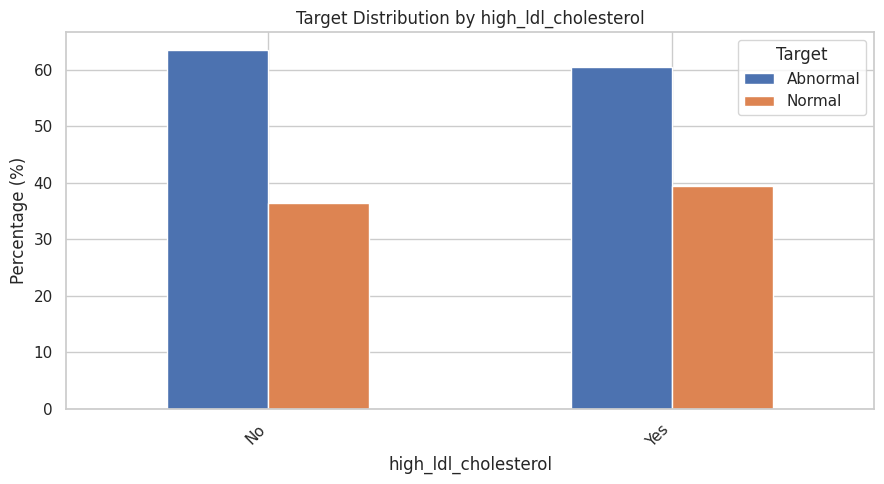

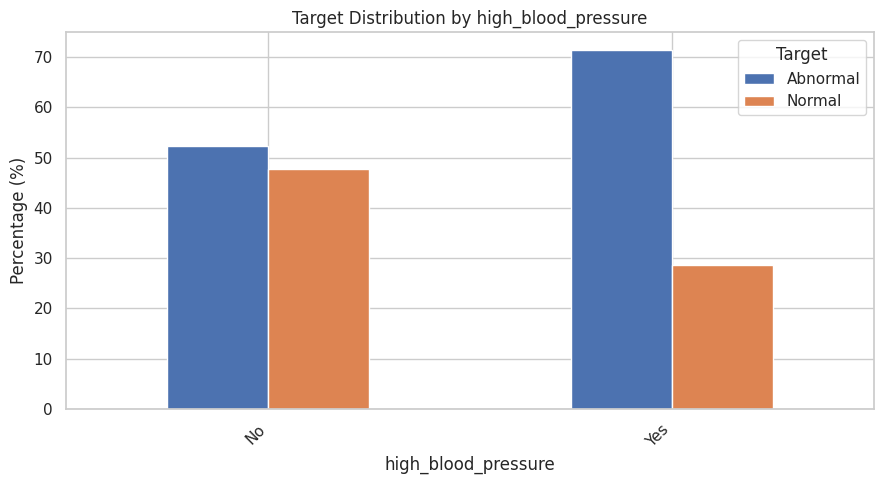

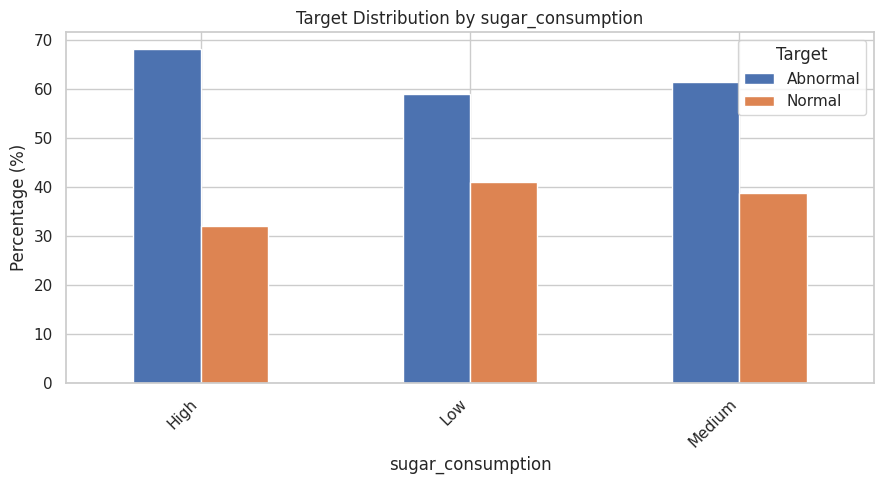

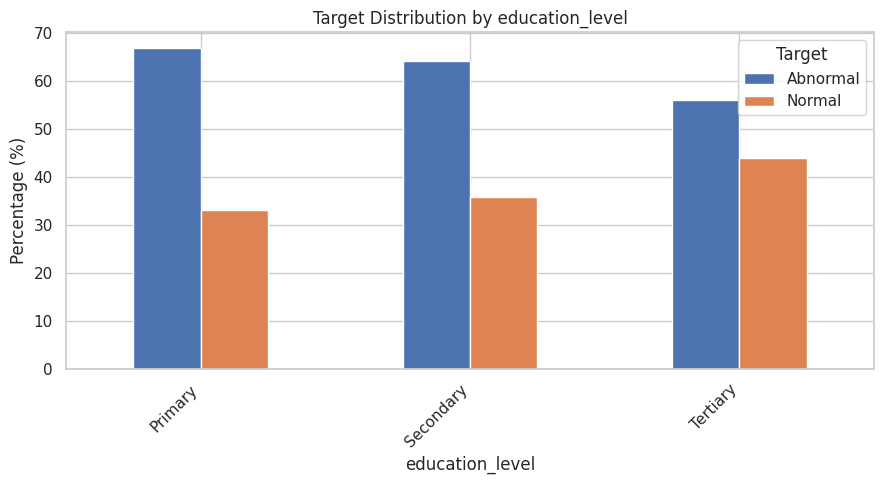

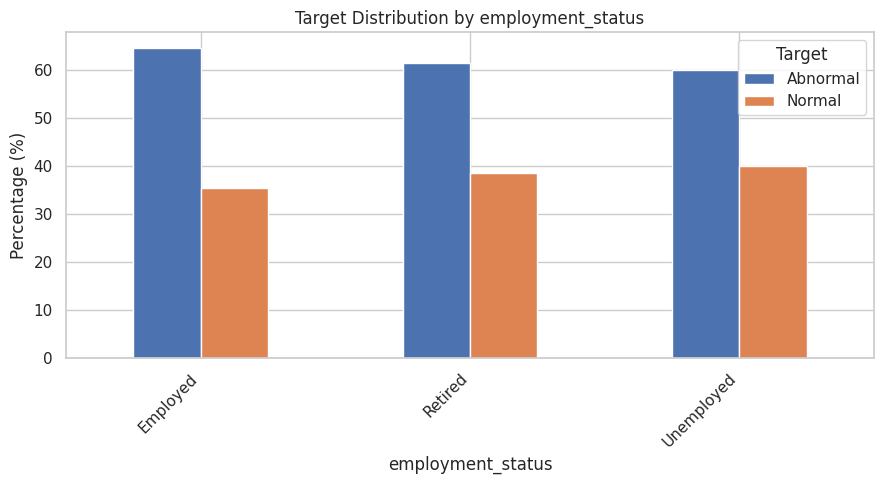

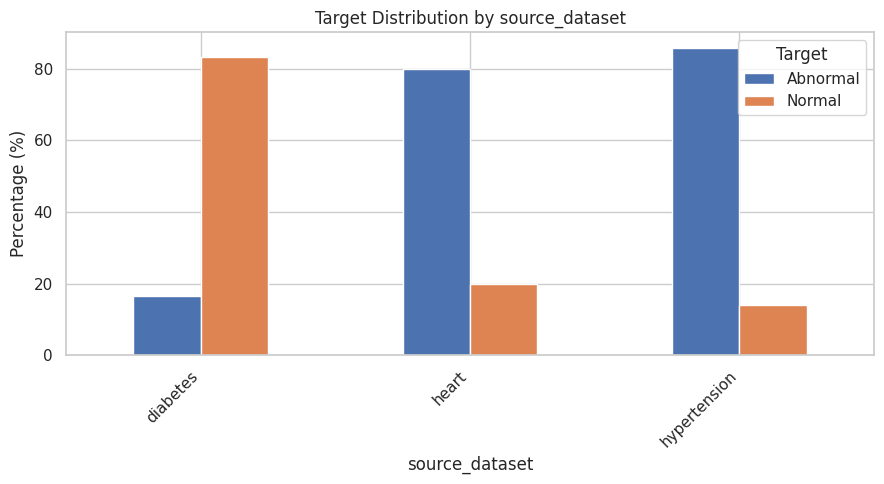

In [86]:
for feature in categorical_analysis_features:

    target_proportion = (
        pd.crosstab(
            df_working[feature],
            df_working["label"],
            normalize="index"
        ) * 100
    )

    target_proportion.plot(
        kind="bar",
        figsize=(9, 5)
    )

    plt.title(f"Target Distribution by {feature}")
    plt.xlabel(feature)
    plt.ylabel("Percentage (%)")
    plt.xticks(rotation=45, ha="right")
    plt.legend(title="Target")
    plt.tight_layout()
    plt.show()

### 1.9.4.5 Numerical Association Ranking

In [87]:
from scipy.stats import pointbiserialr

In [88]:
association_results = []

for feature in numerical_features:
    correlation, p_value = pointbiserialr(
        y_binary,
        df_working[feature]
    )

    association_results.append({
        "Feature": feature,
        "Point_Biserial_Correlation": correlation,
        "Absolute_Correlation": abs(correlation),
        "P_Value": p_value
    })

numerical_association = (
    pd.DataFrame(association_results)
    .sort_values(
        by="Absolute_Correlation",
        ascending=False
    )
)

display(numerical_association)

,Feature,Point_Biserial_Correlation,Absolute_Correlation,P_Value
5,HbA1c_level,0.452993,0.452993,0.000000e+00
3,hypertension,0.432277,0.432277,0.000000e+00
9,triglycerides,-0.361667,0.361667,0.000000e+00
4,heart_disease,0.336046,0.336046,0.000000e+00
0,age,0.257273,0.257273,0.000000e+00
1,age_normalized,0.257273,0.257273,0.000000e+00
2,bmi,0.070310,0.070310,9.003792e-305
6,glucose,0.046262,0.046262,6.152413e-133
8,sleep_hours,0.036169,0.036169,5.600545e-82
11,crp_level,-0.035353,0.035353,2.106180e-78


### Interpreting Numerical Associations

The point-biserial correlation provides an exploratory measure of the relationship between each numerical feature and the binary target.

A larger absolute correlation indicates a stronger linear association with the target.

The correlation sign indicates direction:

- Positive correlation: higher feature values tend to be associated with the Abnormal class.
- Negative correlation: higher feature values tend to be associated with the Normal class.

These values should not be interpreted as causal relationships. Statistical significance is also influenced by the very large sample size, so practical effect size and model performance are more important than p-values alone.

In [89]:
assert "label" in df_working.columns

assert set(
    numerical_association["Feature"]
) == set(numerical_features)

assert "sublabel" not in categorical_analysis_features
assert "disease_flags" not in categorical_analysis_features
assert "composite_key" not in categorical_analysis_features

print("Feature vs target analysis completed successfully.")

Feature vs target analysis completed successfully.


### Feature vs Target Insights

The analysis shows that numerical and categorical variables can have different distributions across the Normal and Abnormal target classes.

Class-wise numerical summaries identify variables whose central tendency and spread differ between the two groups. Categorical target proportions provide a similar view for demographic, behavioral, and clinical categories.

The exploratory association analysis helps prioritize variables for further investigation, but feature importance will ultimately be evaluated within the trained model.

Target-related variables such as `sublabel` and `disease_flags` are excluded from predictive modeling because they contain information closely connected to the target definition. `composite_key` is also excluded because it is constructed metadata rather than an independent clinical measurement.

These results provide exploratory understanding without modifying the dataset or claiming causal relationships.

### 1.9.5 Correlation Analysis

### 1.9.5.1 Correlation Matrix

In [91]:
correlation_matrix = (
    df_working[numerical_features]
    .corr(method="pearson")
)

display(correlation_matrix.round(3))

,age,age_normalized,bmi,hypertension,heart_disease,HbA1c_level,glucose,cholesterol,sleep_hours,triglycerides,blood_pressure,crp_level,homocysteine_level,systolic_bp,diastolic_bp,alcohol_intake,salt_intake,heart_rate,hdl,ldl
age,1.000,1.000,0.099,0.389,0.404,0.107,0.033,0.032,0.046,-0.166,-0.144,0.042,0.043,0.004,0.000,0.000,0.005,-0.002,-0.003,-0.011
age_normalized,1.000,1.000,0.099,0.389,0.404,0.107,0.033,0.032,0.046,-0.166,-0.144,0.042,0.043,0.004,0.000,0.000,0.005,-0.002,-0.003,-0.011
bmi,0.099,0.099,1.000,0.185,0.069,0.036,0.028,0.027,0.032,-0.012,-0.091,-0.038,0.063,-0.000,0.000,-0.005,-0.000,-0.003,-0.005,-0.005
hypertension,0.389,0.389,0.185,1.000,0.292,0.266,0.034,0.011,0.019,-0.115,-0.033,0.008,0.014,0.001,-0.002,-0.002,0.001,0.001,-0.002,-0.006
heart_disease,0.404,0.404,0.069,0.292,1.000,0.224,0.030,0.007,0.016,-0.122,-0.047,-0.012,-0.016,0.002,0.001,-0.001,0.002,-0.002,-0.002,-0.006
HbA1c_level,0.107,0.107,0.036,0.266,0.224,1.000,0.051,0.012,0.018,-0.167,0.070,-0.038,-0.013,0.005,-0.001,-0.002,0.002,-0.001,-0.002,-0.004
glucose,0.033,0.033,0.028,0.034,0.030,0.051,1.000,0.001,0.001,-0.002,0.002,0.001,-0.005,0.002,0.001,-0.001,-0.000,-0.003,0.001,-0.002
cholesterol,0.032,0.032,0.027,0.011,0.007,0.012,0.001,1.000,0.019,-0.028,-0.032,0.006,0.021,-0.002,0.002,-0.003,-0.000,-0.000,-0.002,-0.001
sleep_hours,0.046,0.046,0.032,0.019,0.016,0.018,0.001,0.019,1.000,-0.044,-0.050,0.027,0.014,0.002,-0.005,-0.002,0.002,-0.004,-0.003,-0.006
triglycerides,-0.166,-0.166,-0.012,-0.115,-0.122,-0.167,-0.002,-0.028,-0.044,1.000,0.041,-0.001,-0.013,-0.003,0.005,0.005,-0.002,0.004,0.003,0.005


### 1.9.5.2 Correlation Heatmap

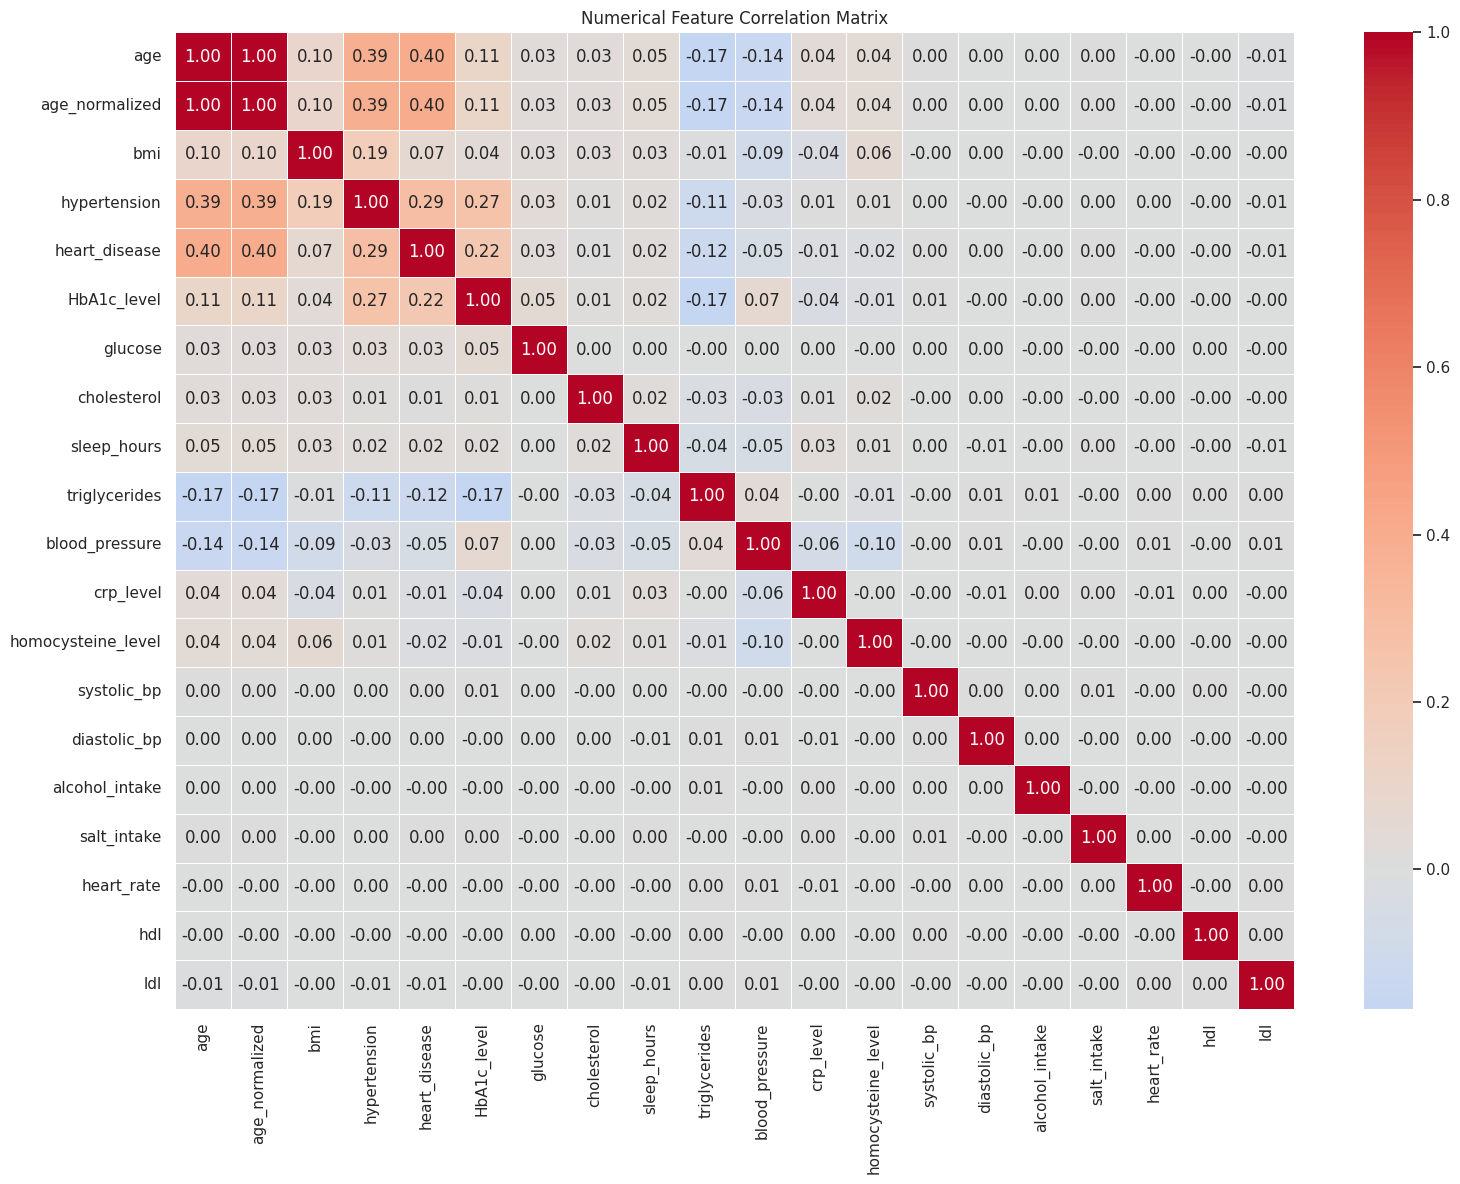

In [92]:
plt.figure(figsize=(16, 12))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title("Numerical Feature Correlation Matrix")
plt.tight_layout()
plt.show()

### 1.9.5.3 Identify Strong Correlations

In [93]:
correlation_pairs = (
    correlation_matrix
    .where(
        np.triu(
            np.ones(correlation_matrix.shape),
            k=1
        ).astype(bool)
    )
    .stack()
    .reset_index()
)

correlation_pairs.columns = [
    "Feature_1",
    "Feature_2",
    "Correlation"
]

correlation_pairs["Absolute_Correlation"] = (
    correlation_pairs["Correlation"].abs()
)

strong_correlations = (
    correlation_pairs[
        correlation_pairs["Absolute_Correlation"] >= 0.70
    ]
    .sort_values(
        by="Absolute_Correlation",
        ascending=False
    )
)

display(strong_correlations)

,Feature_1,Feature_2,Correlation,Absolute_Correlation
0,age,age_normalized,1.0,1.0


### 1.9.5.4 Moderate-to-Strong Correlations

In [94]:
moderate_strong_correlations = (
    correlation_pairs[
        correlation_pairs["Absolute_Correlation"] >= 0.50
    ]
    .sort_values(
        by="Absolute_Correlation",
        ascending=False
    )
)

display(moderate_strong_correlations)

,Feature_1,Feature_2,Correlation,Absolute_Correlation
0,age,age_normalized,1.0,1.0


### 1.9.5.5 Correlation with Target

In [95]:
target_correlations = (
    df_working[numerical_features]
    .corrwith(y_binary)
    .rename("Target_Correlation")
    .reset_index()
)

target_correlations.columns = [
    "Feature",
    "Target_Correlation"
]

target_correlations["Absolute_Correlation"] = (
    target_correlations["Target_Correlation"].abs()
)

target_correlations = target_correlations.sort_values(
    by="Absolute_Correlation",
    ascending=False
)

display(target_correlations)

,Feature,Target_Correlation,Absolute_Correlation
5,HbA1c_level,0.452993,0.452993
3,hypertension,0.432277,0.432277
9,triglycerides,-0.361667,0.361667
4,heart_disease,0.336046,0.336046
0,age,0.257273,0.257273
1,age_normalized,0.257273,0.257273
2,bmi,0.070310,0.070310
6,glucose,0.046262,0.046262
8,sleep_hours,0.036169,0.036169
11,crp_level,-0.035353,0.035353


In [96]:
assert correlation_matrix.shape == (
    len(numerical_features),
    len(numerical_features)
)

assert np.allclose(
    correlation_matrix,
    correlation_matrix.T
)

assert np.allclose(
    np.diag(correlation_matrix),
    1.0
)

assert not correlation_matrix.isna().any().any()

print("Correlation analysis completed successfully.")
print(
    f"Numerical features analyzed: "
    f"{len(numerical_features)}"
)
print(
    f"Strong correlation pairs (|r| >= 0.70): "
    f"{len(strong_correlations)}"
)

Correlation analysis completed successfully.
Numerical features analyzed: 20
Strong correlation pairs (|r| >= 0.70): 1


### Correlation Analysis Insights

The correlation matrix provides an overview of linear relationships among numerical clinical variables.

Strongly correlated feature pairs may contain overlapping information. This can be important for Logistic Regression because multicollinearity may affect coefficient stability and interpretation.

However, correlation alone does not justify removing a feature. Features that are clinically meaningful may be retained even when they are correlated, provided that validation confirms their usefulness.

The correlation analysis also identifies numerical variables that have stronger linear associations with the binary target. These associations are exploratory and should not be interpreted as causal relationships.

Potentially redundant variables will be reviewed during preprocessing rather than removed automatically during EDA.

### 1.9.6 Outlier Analysis

### 1.9.6.1 IQR-Based Outlier Detection

## 1.9.6 Outlier Analysis

Outlier analysis identifies observations that fall unusually far from the central distribution of a numerical feature.

The Interquartile Range (IQR) method is used:

- Q1 = 25th percentile
- Q3 = 75th percentile
- IQR = Q3 − Q1
- Lower Bound = Q1 − 1.5 × IQR
- Upper Bound = Q3 + 1.5 × IQR

Values outside these bounds are classified as statistical outliers.

Important:
A statistical outlier is not automatically an invalid clinical value. Extreme values may represent legitimate patient observations. Therefore, outlier detection is used for assessment rather than automatic deletion.

In [97]:
# ============================================
# IQR-Based Outlier Detection
# ============================================

outlier_summary = []

for feature in numerical_features:
    q1 = df_working[feature].quantile(0.25)
    q3 = df_working[feature].quantile(0.75)
    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    outlier_mask = (
        (df_working[feature] < lower_bound) |
        (df_working[feature] > upper_bound)
    )

    outlier_count = outlier_mask.sum()
    outlier_percentage = (
        outlier_count / len(df_working)
    ) * 100

    outlier_summary.append({
        "Feature": feature,
        "Q1": q1,
        "Q3": q3,
        "IQR": iqr,
        "Lower_Bound": lower_bound,
        "Upper_Bound": upper_bound,
        "Outlier_Count": outlier_count,
        "Outlier_Percentage": outlier_percentage
    })

outlier_summary_df = (
    pd.DataFrame(outlier_summary)
    .sort_values(
        by="Outlier_Percentage",
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    outlier_summary_df.round(3)
)

,Feature,Q1,Q3,IQR,Lower_Bound,Upper_Bound,Outlier_Count,Outlier_Percentage
0,heart_rate,70.000,79.000,9.000,56.500,92.500,49076,17.466
1,diastolic_bp,84.000,95.000,11.000,67.500,111.500,46574,16.575
2,systolic_bp,126.000,143.000,17.000,100.500,168.500,43045,15.319
3,ldl,118.000,141.000,23.000,83.500,175.500,40744,14.500
4,alcohol_intake,12.000,17.900,5.900,3.150,26.750,37343,13.290
5,salt_intake,7.200,9.800,2.600,3.300,13.700,33549,11.940
6,hdl,58.000,72.000,14.000,37.000,93.000,32420,11.538
7,homocysteine_level,12.288,12.686,0.398,11.690,13.284,30993,11.030
8,blood_pressure,148.946,150.721,1.775,146.285,153.383,30312,10.788
9,crp_level,7.295,7.759,0.464,6.599,8.454,30297,10.782


In [98]:
# ============================================
# Highest Outlier Rates
# ============================================

display(
    outlier_summary_df[
        [
            "Feature",
            "Outlier_Count",
            "Outlier_Percentage"
        ]
    ]
    .head(10)
    .round(2)
)

,Feature,Outlier_Count,Outlier_Percentage
0,heart_rate,49076,17.47
1,diastolic_bp,46574,16.58
2,systolic_bp,43045,15.32
3,ldl,40744,14.50
4,alcohol_intake,37343,13.29
5,salt_intake,33549,11.94
6,hdl,32420,11.54
7,homocysteine_level,30993,11.03
8,blood_pressure,30312,10.79
9,crp_level,30297,10.78


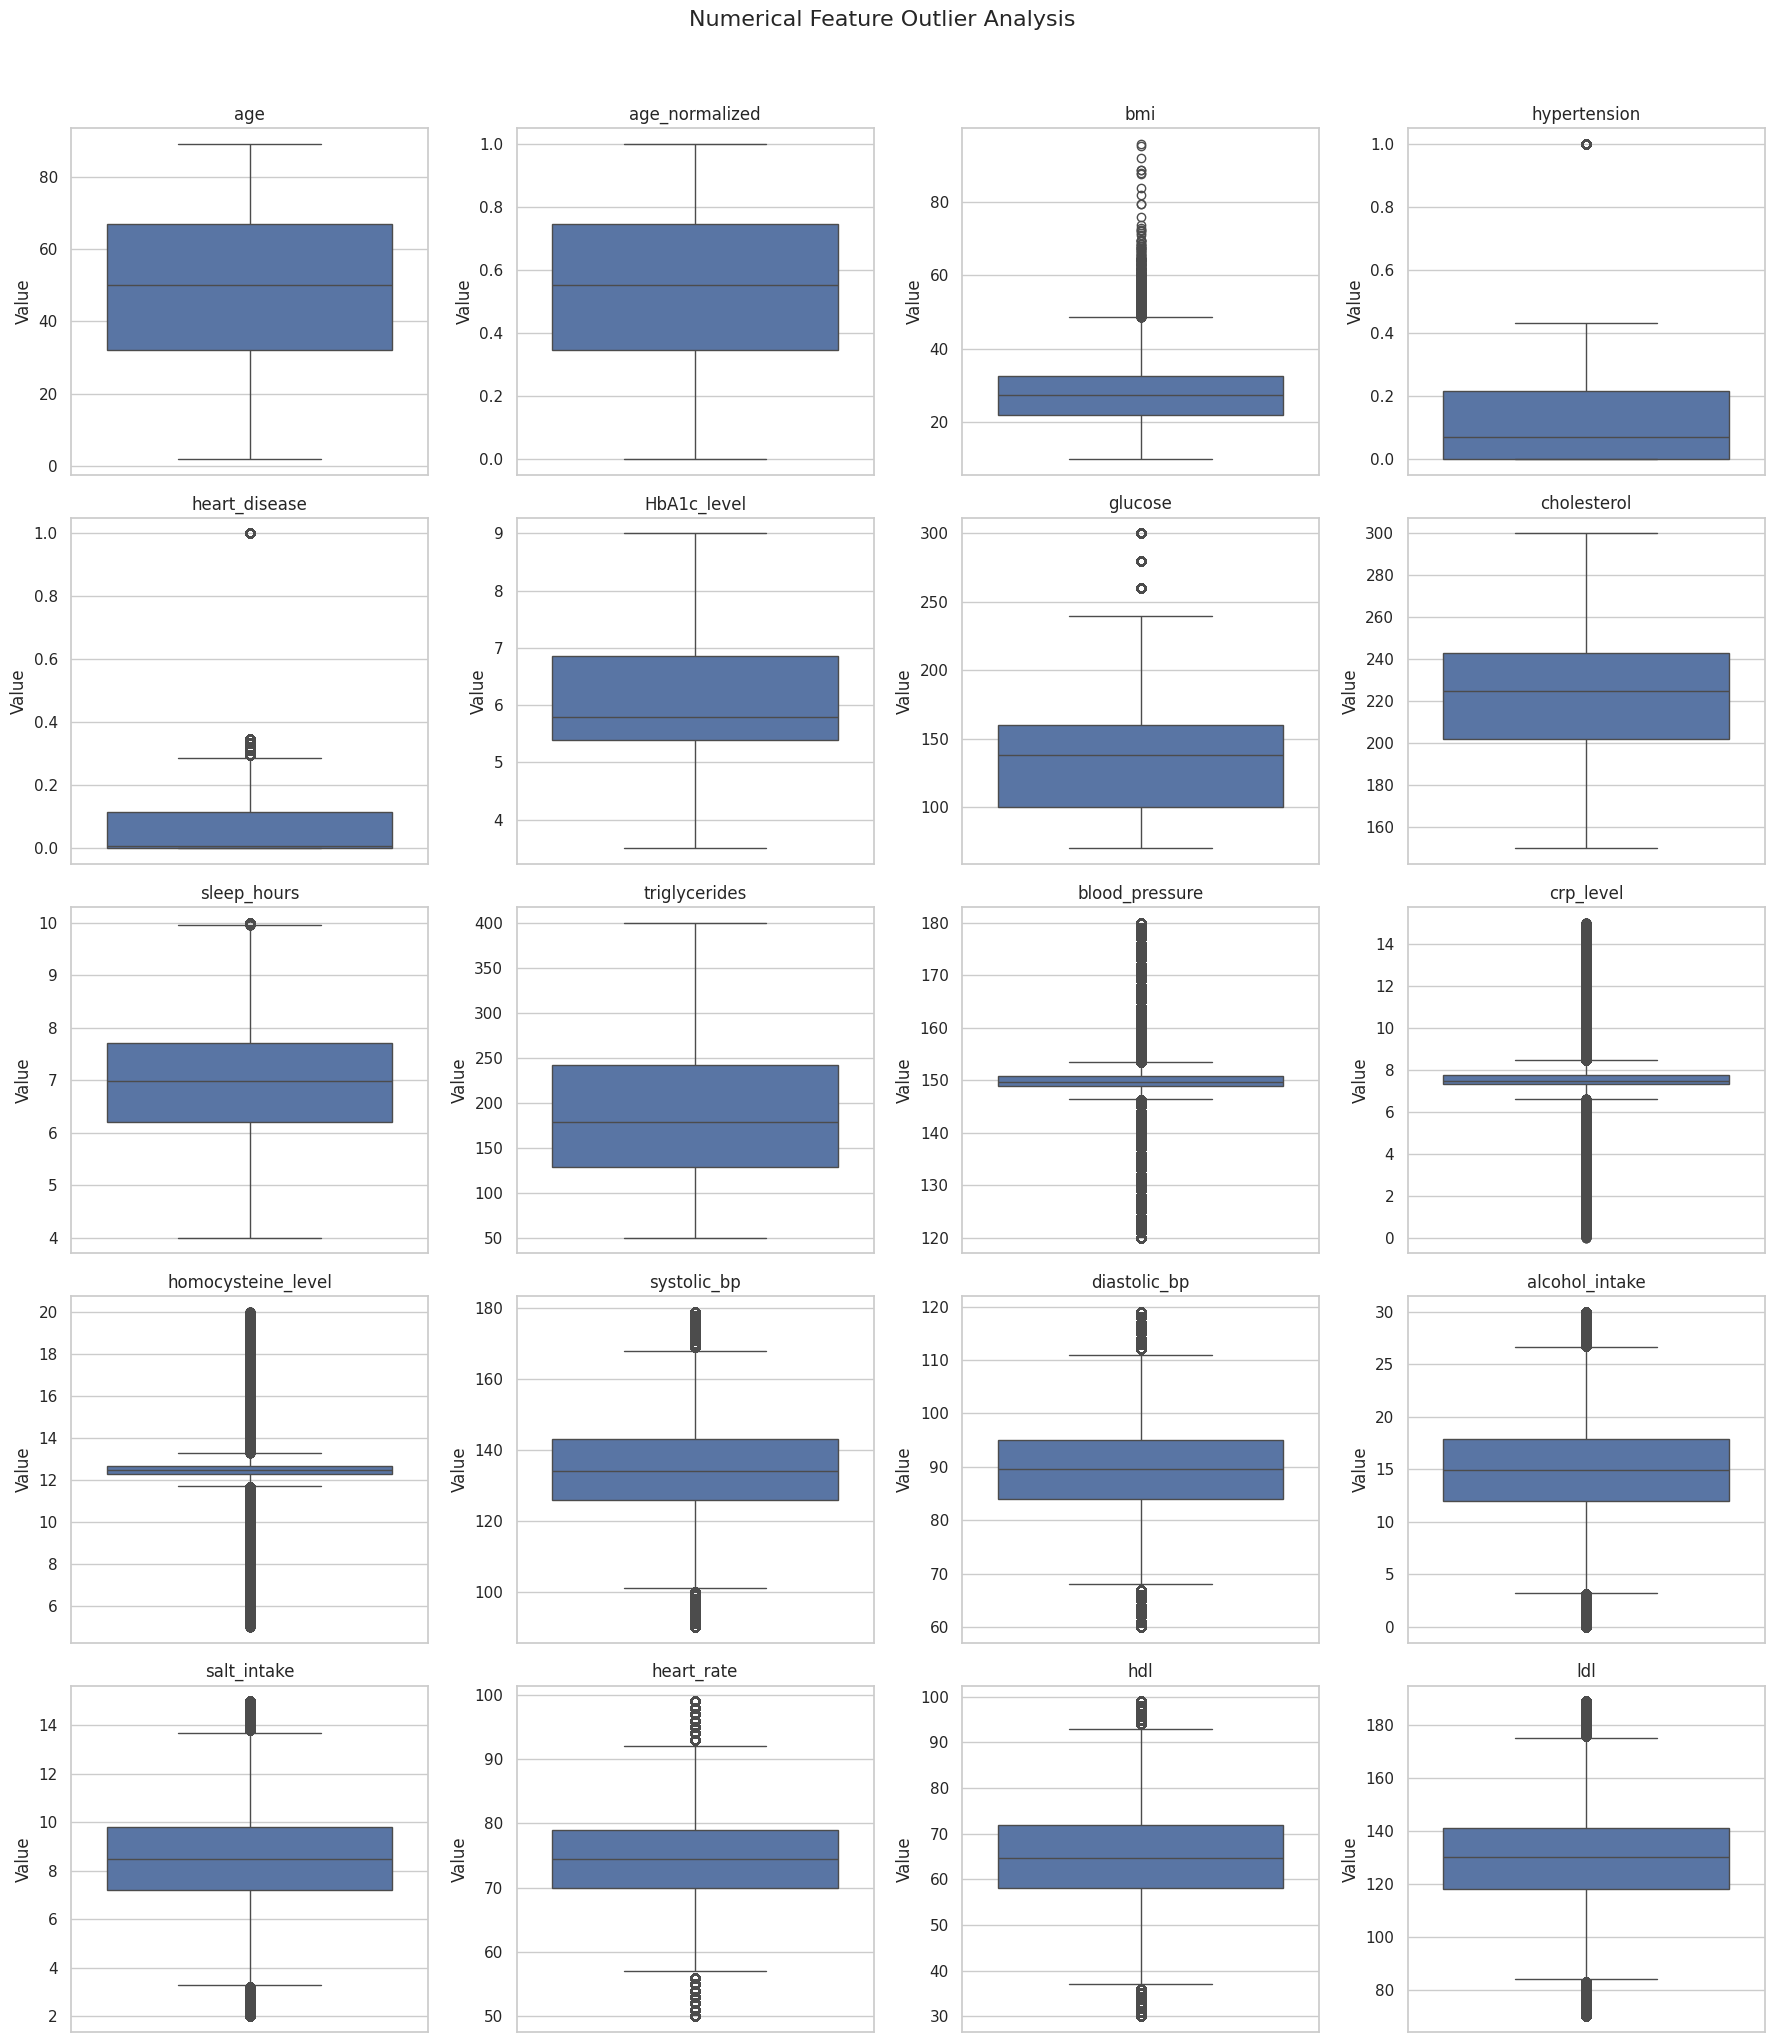

In [99]:
# ============================================
# Boxplots for Numerical Features
# ============================================

n_features = len(numerical_features)
n_cols = 4
n_rows = int(np.ceil(n_features / n_cols))

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(18, n_rows * 4)
)

axes = axes.flatten()

for i, feature in enumerate(numerical_features):
    sns.boxplot(
        y=df_working[feature],
        ax=axes[i]
    )

    axes[i].set_title(feature)
    axes[i].set_ylabel("Value")

# Hide unused axes
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle(
    "Numerical Feature Outlier Analysis",
    fontsize=16,
    y=1.02
)

plt.tight_layout()
plt.show()

In [100]:
# ============================================
# Verify Outlier Analysis Did Not Modify Data
# ============================================

assert df_working.shape == df_original.shape

assert list(df_working.columns) == list(
    df_original.columns
)

print("Outlier analysis completed without modifying the dataset.")
print(f"Rows retained: {len(df_working):,}")
print(f"Numerical features analyzed: {len(numerical_features)}")

Outlier analysis completed without modifying the dataset.
Rows retained: 280,985
Numerical features analyzed: 20


### 1.9.7 Class-wise Feature Analysis

### Numerical Class Separation

Class-wise numerical analysis evaluates how the distributions of numerical features differ between the Normal and Abnormal target classes.

The analysis compares:

- Mean
- Median
- Standard deviation
- Absolute mean difference
- Standardized mean difference

The goal is to identify features that show meaningful class separation.

These results are exploratory and describe statistical differences between classes. They do not establish causal relationships or clinical significance.

In [101]:
# Define target classes
normal_mask = y_binary == 0
abnormal_mask = y_binary == 1

normal_data = df_working.loc[normal_mask, numerical_features]
abnormal_data = df_working.loc[abnormal_mask, numerical_features]

classwise_numeric_summary = []

for feature in numerical_features:
    normal_values = normal_data[feature]
    abnormal_values = abnormal_data[feature]

    normal_mean = normal_values.mean()
    abnormal_mean = abnormal_values.mean()

    normal_median = normal_values.median()
    abnormal_median = abnormal_values.median()

    normal_std = normal_values.std()
    abnormal_std = abnormal_values.std()

    mean_difference = abnormal_mean - normal_mean

    classwise_numeric_summary.append({
        "Feature": feature,
        "Normal_Mean": normal_mean,
        "Abnormal_Mean": abnormal_mean,
        "Mean_Difference": mean_difference,
        "Normal_Median": normal_median,
        "Abnormal_Median": abnormal_median,
        "Normal_STD": normal_std,
        "Abnormal_STD": abnormal_std
    })

classwise_numeric_summary_df = (
    pd.DataFrame(classwise_numeric_summary)
    .sort_values(
        by="Mean_Difference",
        key=lambda x: x.abs(),
        ascending=False
    )
    .reset_index(drop=True)
)

display(classwise_numeric_summary_df.round(3))

,Feature,Normal_Mean,Abnormal_Mean,Mean_Difference,Normal_Median,Abnormal_Median,Normal_STD,Abnormal_STD
0,triglycerides,210.077,159.914,-50.163,241.500,156.000,59.858,64.505
1,age,42.546,54.037,11.490,42.000,55.000,21.941,20.322
2,glucose,132.987,136.653,3.667,140.000,136.000,34.931,40.439
3,cholesterol,223.115,224.617,1.502,225.071,225.000,23.052,41.350
4,bmi,26.859,27.879,1.020,27.320,27.700,6.675,7.228
5,HbA1c_level,5.396,6.286,0.890,5.420,6.750,0.841,0.856
6,ldl,130.078,129.510,-0.568,130.217,129.566,16.697,32.190
7,systolic_bp,134.220,134.519,0.299,134.130,134.408,12.532,24.178
8,hypertension,0.025,0.192,0.167,0.000,0.165,0.057,0.210
9,age_normalized,0.466,0.598,0.132,0.460,0.609,0.252,0.234


### Effect Size Ranking Cohen's d

Cohen's d provides a standardized measure of the difference between the Normal and Abnormal class means.

The pooled standard deviation is used to account for differences in feature variability.

A larger absolute Cohen's d indicates stronger statistical separation between the two classes.

Cohen's d is used here as an exploratory effect-size measure. It should not be interpreted as evidence of causality or clinical importance.

In [102]:
effect_size_results = []

for feature in numerical_features:
    normal_values = normal_data[feature]
    abnormal_values = abnormal_data[feature]

    normal_mean = normal_values.mean()
    abnormal_mean = abnormal_values.mean()

    normal_std = normal_values.std()
    abnormal_std = abnormal_values.std()

    n_normal = len(normal_values)
    n_abnormal = len(abnormal_values)

    pooled_std = np.sqrt(
        (
            (n_normal - 1) * normal_std**2 +
            (n_abnormal - 1) * abnormal_std**2
        )
        /
        (n_normal + n_abnormal - 2)
    )

    if pooled_std == 0:
        cohens_d = 0.0
    else:
        cohens_d = (
            abnormal_mean - normal_mean
        ) / pooled_std

    effect_size_results.append({
        "Feature": feature,
        "Cohens_d": cohens_d,
        "Absolute_Cohens_d": abs(cohens_d),
        "Normal_Mean": normal_mean,
        "Abnormal_Mean": abnormal_mean
    })

effect_size_df = (
    pd.DataFrame(effect_size_results)
    .sort_values(
        by="Absolute_Cohens_d",
        ascending=False
    )
    .reset_index(drop=True)
)

display(effect_size_df.round(4))

,Feature,Cohens_d,Absolute_Cohens_d,Normal_Mean,Abnormal_Mean
0,HbA1c_level,1.0466,1.0466,5.3959,6.2861
1,hypertension,0.9874,0.9874,0.0249,0.1917
2,triglycerides,-0.7991,0.7991,210.0771,159.9143
3,heart_disease,0.7349,0.7349,0.0141,0.1098
4,age,0.5484,0.5484,42.5464,54.0366
5,age_normalized,0.5484,0.5484,0.4661,0.5981
6,bmi,0.1452,0.1452,26.8589,27.8785
7,glucose,0.0954,0.0954,132.9868,136.6534
8,sleep_hours,0.0745,0.0745,6.8888,6.9951
9,crp_level,-0.0729,0.0729,7.5349,7.4610


### 1.9.7.3 Top Class-Separating Features

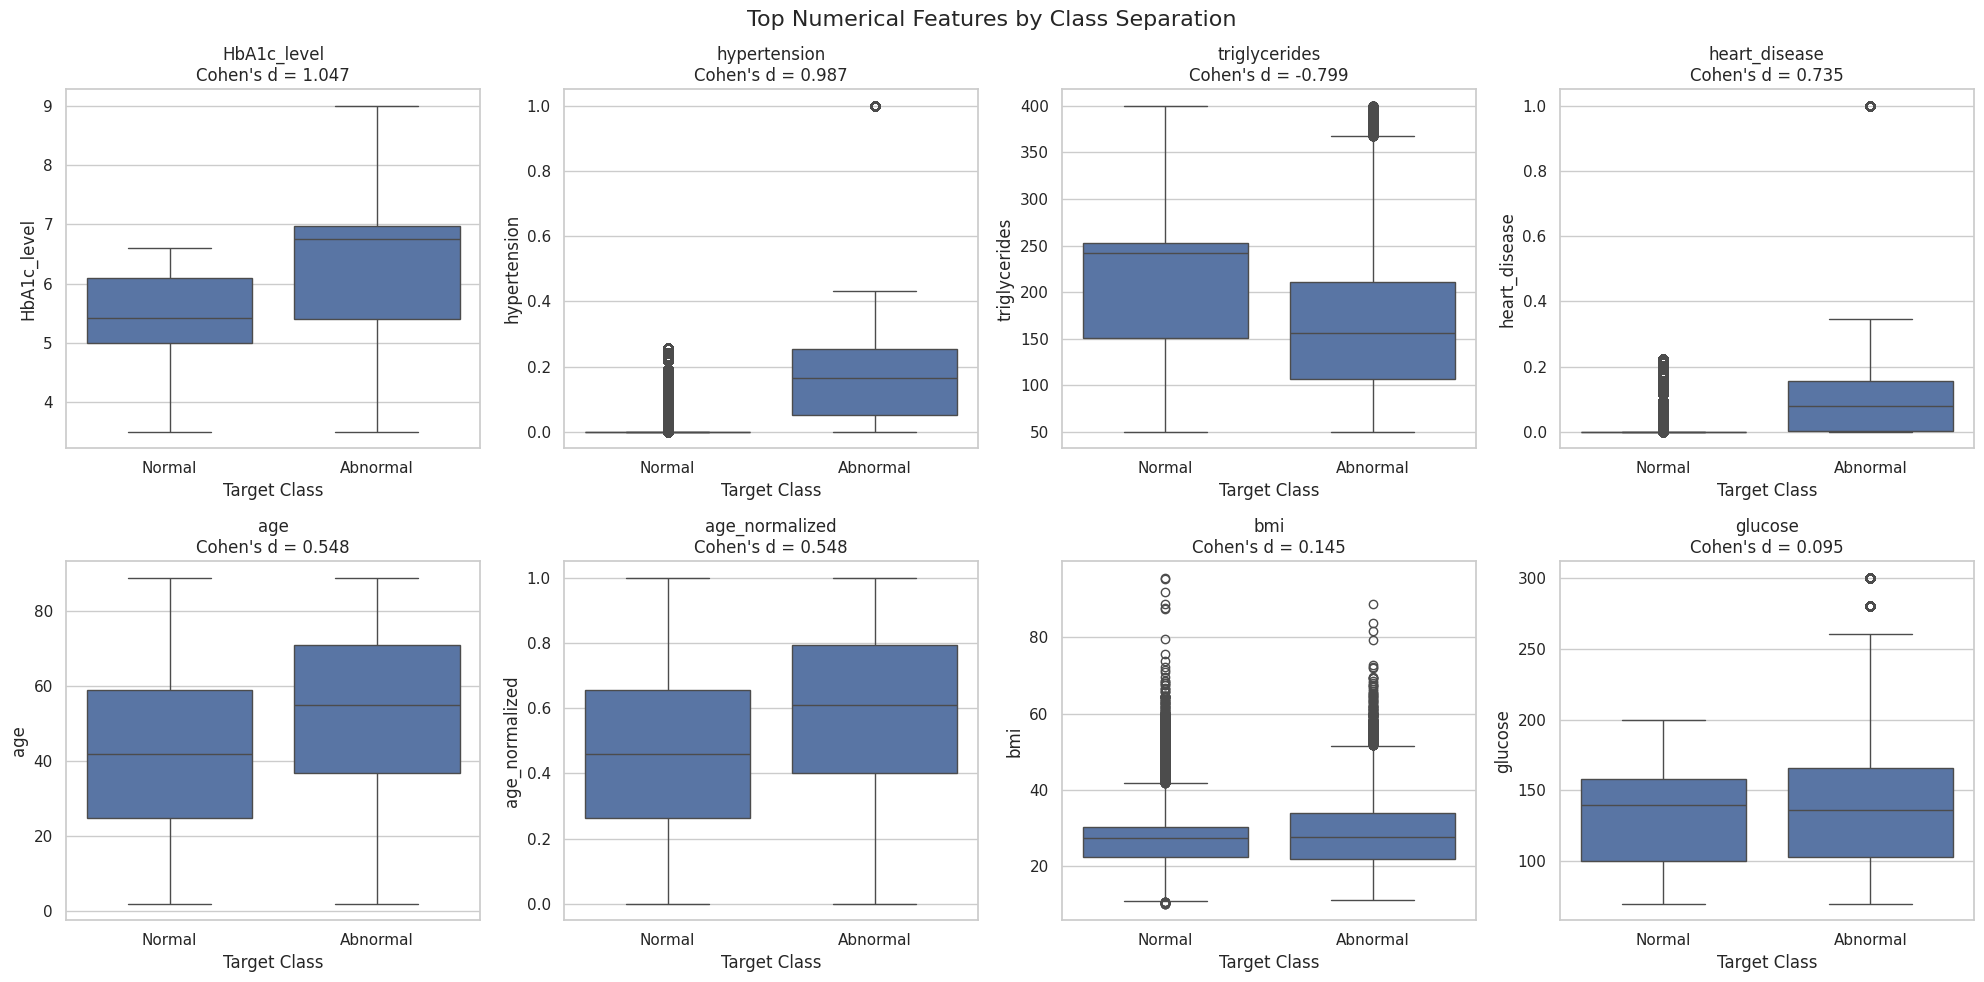

In [103]:
TOP_N_EFFECT_SIZE = 8

top_effect_features = (
    effect_size_df
    .head(TOP_N_EFFECT_SIZE)["Feature"]
    .tolist()
)

n_features = len(top_effect_features)

fig, axes = plt.subplots(
    nrows=2,
    ncols=4,
    figsize=(20, 10)
)

axes = axes.flatten()

for ax, feature in zip(axes, top_effect_features):
    sns.boxplot(
        data=df_working,
        x="label",
        y=feature,
        ax=ax
    )

    ax.set_title(
        f"{feature}\n"
        f"Cohen's d = "
        f"{effect_size_df.loc[
            effect_size_df["Feature"] == feature,
            "Cohens_d"
        ].iloc[0]:.3f}"
    )

    ax.set_xlabel("Target Class")
    ax.set_ylabel(feature)

plt.suptitle(
    "Top Numerical Features by Class Separation",
    fontsize=16
)

plt.tight_layout()
plt.show()

### 1.9.7.4 Categorical Class Separation

###  Categorical Class Separation

Categorical features are evaluated using class proportions and Cramér's V.

Cramér's V measures the strength of association between a categorical feature and the binary target.

Target-related fields and constructed metadata are excluded to prevent leakage during predictive interpretation.

The analysis is descriptive and does not imply causality.

In [104]:
from scipy.stats import chi2_contingency

# Exclude target-related and metadata fields
categorical_analysis_features = [
    feature for feature in categorical_features
    if feature not in [
        "label",
        "sublabel",
        "disease_flags",
        "composite_key",
        "source_dataset"
    ]
]

categorical_effect_results = []

for feature in categorical_analysis_features:

    contingency_table = pd.crosstab(
        df_working[feature],
        y_binary
    )

    chi2, p_value, _, _ = chi2_contingency(
        contingency_table
    )

    n = contingency_table.to_numpy().sum()
    r, k = contingency_table.shape

    phi2 = chi2 / n

    # Bias-corrected Cramér's V
    phi2_corrected = max(
        0,
        phi2 - (
            ((k - 1) * (r - 1)) / (n - 1)
        )
    )

    r_corrected = (
        r - ((r - 1) ** 2) / (n - 1)
    )

    k_corrected = (
        k - ((k - 1) ** 2) / (n - 1)
    )

    denominator = min(
        k_corrected - 1,
        r_corrected - 1
    )

    if denominator > 0:
        cramers_v = np.sqrt(
            phi2_corrected / denominator
        )
    else:
        cramers_v = 0.0

    categorical_effect_results.append({
        "Feature": feature,
        "Cramers_V": cramers_v,
        "Chi_Square": chi2,
        "P_Value": p_value,
        "Categories": df_working[feature].nunique()
    })

categorical_effect_df = (
    pd.DataFrame(categorical_effect_results)
    .sort_values(
        by="Cramers_V",
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    categorical_effect_df.round(4)
)

,Feature,Cramers_V,Chi_Square,P_Value,Categories
0,diabetes,0.5853,96251.9207,0.0,2
1,smoking,0.2616,19229.4172,0.0,3
2,age_level,0.2507,17667.6310,0.0,4
3,high_blood_pressure,0.1964,10840.0456,0.0,2
4,bmi_level,0.1899,10130.8776,0.0,4
5,physical_activity,0.1846,9581.9250,0.0,3
6,family_history,0.1115,3494.9219,0.0,2
7,education_level,0.0971,2651.6539,0.0,3
8,low_hdl_cholesterol,0.0851,2034.3820,0.0,2
9,sugar_consumption,0.0757,1611.0443,0.0,3


In [105]:
TOP_N_CATEGORICAL = 6

top_categorical_features = (
    categorical_effect_df
    .head(TOP_N_CATEGORICAL)["Feature"]
    .tolist()
)

for feature in top_categorical_features:

    proportion_table = pd.crosstab(
        df_working[feature],
        y_binary,
        normalize="index"
    ) * 100

    proportion_table.columns = [
        "Normal_%",
        "Abnormal_%"
    ]

    print(f"\n{feature}")
    display(proportion_table.round(2))


diabetes


,Normal_%,Abnormal_%
diabetes,,
No,59.26,40.74
Yes,0.00,100.00



smoking


,Normal_%,Abnormal_%
smoking,,
Current,23.01,76.99
Former,30.02,69.98
Never,51.66,48.34



age_level


...

,Normal_%,Abnormal_%
high_blood_pressure,,
No,47.69,52.31
Yes,28.62,71.38



bmi_level


,Normal_%,Abnormal_%
bmi_level,,
Normal,38.49,61.51
Obese,27.86,72.14
Overweight,51.12,48.88
Underweight,36.03,63.97



physical_activity


,Normal_%,Abnormal_%
physical_activity,,
High,48.42,51.58
Low,30.28,69.72
Moderate,30.32,69.68


In [106]:
# Verify both target classes are represented
assert normal_mask.sum() > 0
assert abnormal_mask.sum() > 0

# Verify numerical analysis covers all numerical features
assert set(effect_size_df["Feature"]) == set(numerical_features)

# Verify categorical analysis excludes leakage-related fields
assert not set([
    "label",
    "sublabel",
    "disease_flags",
    "composite_key"
]).intersection(
    set(categorical_effect_df["Feature"])
)

# Verify dataset was not modified
assert df_working.shape == df_original.shape

print("Class-wise feature analysis completed successfully.")
print(f"Normal observations: {normal_mask.sum():,}")
print(f"Abnormal observations: {abnormal_mask.sum():,}")
print(f"Numerical features analyzed: {len(numerical_features)}")
print(
    f"Categorical features analyzed: "
    f"{len(categorical_analysis_features)}"
)

Class-wise feature analysis completed successfully.
Normal observations: 106,884
Abnormal observations: 174,101
Numerical features analyzed: 20
Categorical features analyzed: 14


### Class-wise Feature Analysis Conclusion

Class-wise analysis identified numerical and categorical features that differ between the Normal and Abnormal target classes.

For numerical features, Cohen's d was used to rank the magnitude of class separation. For categorical features, Cramér's V was used to quantify the strength of association with the target.

These findings provide exploratory evidence about potentially informative features for the later modeling stage.

No features were removed based solely on these results. Feature selection, preprocessing, and leakage decisions will be validated during the modeling pipeline.

Most importantly, statistical association should not be interpreted as causation or direct clinical significance.

### Distribution Summary

This section consolidates the major distribution characteristics identified during exploratory data analysis.

The analysis considers:

- Target class distribution
- Numerical feature variability
- Feature skewness
- Categorical cardinality
- Class separation
- Correlation structure
- Potential distribution-related modeling considerations

These observations will guide preprocessing and model design without making automatic feature-removal decisions.

In [108]:
# Numerical distribution summary
distribution_summary = []

for feature in numerical_features:
    values = df_working[feature]

    distribution_summary.append({
        "Feature": feature,
        "Min": values.min(),
        "Max": values.max(),
        "Mean": values.mean(),
        "Median": values.median(),
        "STD": values.std(),
        "Skewness": values.skew(),
        "Unique_Values": values.nunique()
    })

distribution_summary_df = (
    pd.DataFrame(distribution_summary)
    .sort_values(
        by="Skewness",
        key=lambda x: x.abs(),
        ascending=False
    )
    .reset_index(drop=True)
)

display(distribution_summary_df.round(4))

,Feature,Min,Max,Mean,Median,STD,Skewness,Unique_Values
0,heart_disease,0.0000,1.0000,0.0734,0.0073,0.1382,4.4027,125
1,hypertension,0.0000,1.0000,0.1282,0.0714,0.1873,2.9099,137
2,blood_pressure,120.0000,180.0000,149.8872,149.7133,4.1486,0.4655,197
3,glucose,70.0000,300.0000,135.2586,138.0000,38.4779,0.3802,154
4,bmi,10.0100,95.6900,27.4907,27.3200,7.0404,0.3081,14122
5,crp_level,0.0036,14.9971,7.4891,7.4585,1.0139,-0.2792,9992
6,HbA1c_level,3.5000,9.0000,5.9475,5.8000,0.9541,-0.1950,192
7,triglycerides,50.0000,400.0000,178.9957,179.0000,67.3361,-0.0682,525
8,age,2.0000,89.0000,49.6659,50.0000,21.6824,-0.0588,88
9,age_normalized,0.0000,1.0000,0.5479,0.5517,0.2492,-0.0588,151


### 1.9.8.2 Skewness Classification

In [109]:
def classify_skewness(skewness):
    absolute_skewness = abs(skewness)

    if absolute_skewness < 0.5:
        return "Approximately Symmetric"
    elif absolute_skewness < 1.0:
        return "Moderately Skewed"
    else:
        return "Highly Skewed"


distribution_summary_df["Skewness_Category"] = (
    distribution_summary_df["Skewness"]
    .apply(classify_skewness)
)

display(
    distribution_summary_df[
        [
            "Feature",
            "Skewness",
            "Skewness_Category"
        ]
    ].round(4)
)

,Feature,Skewness,Skewness_Category
0,heart_disease,4.4027,Highly Skewed
1,hypertension,2.9099,Highly Skewed
2,blood_pressure,0.4655,Approximately Symmetric
3,glucose,0.3802,Approximately Symmetric
4,bmi,0.3081,Approximately Symmetric
5,crp_level,-0.2792,Approximately Symmetric
6,HbA1c_level,-0.1950,Approximately Symmetric
7,triglycerides,-0.0682,Approximately Symmetric
8,age,-0.0588,Approximately Symmetric
9,age_normalized,-0.0588,Approximately Symmetric


###1.9.8.3 Categorical Distribution and Cardinality

###  Categorical Distribution and Cardinality

Categorical features are reviewed based on their number of unique categories and the frequency of their most common category.

Low-cardinality categorical features can generally be encoded using one-hot encoding.

High-cardinality or constructed metadata fields require additional consideration because direct encoding may increase dimensionality or introduce leakage.

Target-related fields remain excluded from predictive modeling.

In [110]:
categorical_distribution_summary = []

for feature in categorical_features:
    value_counts = df_working[feature].value_counts(
        normalize=True
    )

    categorical_distribution_summary.append({
        "Feature": feature,
        "Unique_Categories": df_working[feature].nunique(),
        "Most_Common_Category": value_counts.index[0],
        "Most_Common_Percentage": value_counts.iloc[0] * 100
    })

categorical_distribution_df = (
    pd.DataFrame(categorical_distribution_summary)
    .sort_values(
        by="Unique_Categories",
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    categorical_distribution_df.round(2)
)

,Feature,Unique_Categories,Most_Common_Category,Most_Common_Percentage
0,composite_key,192,Middle_Female_Overweight_Never_No,2.17
1,sublabel,8,N,38.04
2,disease_flags,8,"0,0,0",38.04
3,bmi_level,4,Obese,35.01
4,age_level,4,Mature,31.19
5,source_dataset,3,hypertension,62.27
6,smoking,3,Never,45.47
7,education_level,3,Tertiary,37.47
8,sugar_consumption,3,Low,43.86
9,physical_activity,3,High,42.71


### 1.9.8.4 Overall EDA Distribution Profile

In [111]:
# Verify numerical summary
assert len(distribution_summary_df) == len(numerical_features)

# Verify categorical summary
assert len(categorical_distribution_df) == len(categorical_features)

# Verify target distribution
assert y_binary.notna().all()
assert y_binary.nunique() == 2

# Verify original dataset remains unchanged
assert df_working.shape == df_original.shape
assert list(df_working.columns) == list(df_original.columns)

print("Data distribution analysis completed successfully.")
print(f"Rows analyzed: {len(df_working):,}")
print(f"Numerical features: {len(numerical_features)}")
print(f"Categorical features: {len(categorical_features)}")
print(f"Target classes: {y_binary.nunique()}")

Data distribution analysis completed successfully.
Rows analyzed: 280,985
Numerical features: 20
Categorical features: 19
Target classes: 2


## 1.10 Data Preprocessing

### 1.10.1 Remove Unnecessary Columns

### Remove Unnecessary Columns

The first preprocessing step is to remove columns that should not be used as predictive features.

Columns are excluded for one of three main reasons:

1. Target-related information that can cause target leakage.
2. Constructed metadata or identifiers that do not represent independent predictive measurements.
3. Dataset-source metadata that may encode the origin of an observation rather than the underlying clinical characteristics.

The target variable `label` is kept separately as the prediction target.

The following columns are excluded from the feature matrix:

- `composite_key`
- `sublabel`
- `disease_flags`
- `source_dataset`

These exclusions are made before model training to reduce leakage and metadata-driven learning.

In [112]:
# Define columns that should not be used as predictive features
UNNECESSARY_COLUMNS = [
    "composite_key",
    "sublabel",
    "disease_flags",
    "source_dataset"
]

# Create a clean modeling dataset
df_preprocessed = df_working.drop(
    columns=UNNECESSARY_COLUMNS
).copy()

# Separate target from predictors
X_preprocessed = df_preprocessed.drop(
    columns=["label"]
).copy()

y_preprocessed = y_binary.copy()

print("Columns removed:")
print(UNNECESSARY_COLUMNS)

print("\nOriginal shape:")
print(df_working.shape)

print("\nPreprocessed feature shape:")
print(X_preprocessed.shape)

print("\nRemaining columns:")
print(X_preprocessed.columns.tolist())

Columns removed:
['composite_key', 'sublabel', 'disease_flags', 'source_dataset']

Original shape:
(280985, 39)

Preprocessed feature shape:
(280985, 34)

Remaining columns:
['age_level', 'gender', 'bmi_level', 'smoking', 'diabetes', 'age', 'age_normalized', 'bmi', 'hypertension', 'heart_disease', 'HbA1c_level', 'glucose', 'cholesterol', 'sleep_hours', 'triglycerides', 'physical_activity', 'family_history', 'stress_level', 'low_hdl_cholesterol', 'high_ldl_cholesterol', 'blood_pressure', 'high_blood_pressure', 'sugar_consumption', 'crp_level', 'homocysteine_level', 'systolic_bp', 'diastolic_bp', 'alcohol_intake', 'salt_intake', 'heart_rate', 'hdl', 'ldl', 'education_level', 'employment_status']


### 1.10.2 Handle Missing Values

In [113]:
# Check missing values after column removal
missing_summary = (
    X_preprocessed.isna()
    .sum()
    .sort_values(ascending=False)
)

total_missing = missing_summary.sum()

print(f"Total missing values: {total_missing}")

if total_missing > 0:
    display(
        missing_summary[
            missing_summary > 0
        ]
    )
else:
    print("No missing values detected.")

Total missing values: 0
No missing values detected.


### 1.10.3 Handle Invalid Values

In [114]:
# Define basic plausibility checks
invalid_rules = {
    "age": (0, 120),
    "bmi": (0, 100),
    "glucose": (0, 500),
    "cholesterol": (0, 500),
    "sleep_hours": (0, 24),
    "triglycerides": (0, 1000),
    "systolic_bp": (0, 300),
    "diastolic_bp": (0, 200),
    "heart_rate": (0, 300),
    "hdl": (0, 200),
    "ldl": (0, 500)
}

invalid_summary = []

for feature, (lower, upper) in invalid_rules.items():

    invalid_mask = (
        (X_preprocessed[feature] < lower) |
        (X_preprocessed[feature] > upper)
    )

    invalid_count = invalid_mask.sum()

    invalid_summary.append({
        "Feature": feature,
        "Lower_Bound": lower,
        "Upper_Bound": upper,
        "Invalid_Count": invalid_count
    })

invalid_values_df = pd.DataFrame(
    invalid_summary
)

display(invalid_values_df)

,Feature,Lower_Bound,Upper_Bound,Invalid_Count
0,age,0,120,0
1,bmi,0,100,0
2,glucose,0,500,0
3,cholesterol,0,500,0
4,sleep_hours,0,24,0
5,triglycerides,0,1000,0
6,systolic_bp,0,300,0
7,diastolic_bp,0,200,0
8,heart_rate,0,300,0
9,hdl,0,200,0


In [115]:
total_invalid_values = (
    invalid_values_df["Invalid_Count"].sum()
)

print(
    f"Total values outside predefined plausibility ranges: "
    f"{total_invalid_values}"
)

if total_invalid_values == 0:
    print("No invalid values detected.")
else:
    print(
        "Invalid values require investigation before modeling."
    )

Total values outside predefined plausibility ranges: 0
No invalid values detected.


### 1.10.4 Handle Duplicates

In [116]:
# Check exact duplicates in the current modeling dataset
exact_duplicate_count = X_preprocessed.duplicated().sum()

print(
    f"Exact duplicate feature rows: "
    f"{exact_duplicate_count:,}"
)

Exact duplicate feature rows: 2,284


In [117]:
# 1.10.4 Handle Duplicates

exact_duplicate_count = X_preprocessed.duplicated().sum()

print(
    f"Exact duplicate feature rows detected: "
    f"{exact_duplicate_count:,}"
)

duplicate_percentage = (
    exact_duplicate_count / len(X_preprocessed)
) * 100

print(
    f"Duplicate percentage: "
    f"{duplicate_percentage:.2f}%"
)

Exact duplicate feature rows detected: 2,284
Duplicate percentage: 0.81%


In [118]:
# Identify unique feature rows
unique_mask = ~X_preprocessed.duplicated(keep="first")

X_preprocessed = X_preprocessed.loc[unique_mask].copy()
y_preprocessed = y_preprocessed.loc[unique_mask].copy()

print(f"Rows after duplicate removal: {len(X_preprocessed):,}")
print(f"Rows removed: {exact_duplicate_count:,}")

Rows after duplicate removal: 278,701
Rows removed: 2,284


In [119]:
# Verify duplicate removal and X/y alignment

assert X_preprocessed.duplicated().sum() == 0
assert len(X_preprocessed) == len(y_preprocessed)
assert X_preprocessed.index.equals(y_preprocessed.index)

print("Duplicate handling completed successfully.")
print(f"Final feature rows: {len(X_preprocessed):,}")
print(f"Final target rows: {len(y_preprocessed):,}")

Duplicate handling completed successfully.
Final feature rows: 278,701
Final target rows: 278,701


### 1.10.5 Encode Categorical Features

### 1.10.5.1 Identify Final Feature Types

In [120]:
# 1.10.5 Encode Categorical Features

# Identify numerical and categorical features
# after removing unnecessary and target-related columns.

model_numerical_features = (
    X_preprocessed
    .select_dtypes(include=np.number)
    .columns
    .tolist()
)

model_categorical_features = (
    X_preprocessed
    .select_dtypes(include=["object", "category"])
    .columns
    .tolist()
)

print(
    f"Numerical features: {len(model_numerical_features)}"
)

print(
    f"Categorical features: {len(model_categorical_features)}"
)

print("\nNumerical features:")
print(model_numerical_features)

print("\nCategorical features:")
print(model_categorical_features)

Numerical features: 20
Categorical features: 14

Numerical features:
['age', 'age_normalized', 'bmi', 'hypertension', 'heart_disease', 'HbA1c_level', 'glucose', 'cholesterol', 'sleep_hours', 'triglycerides', 'blood_pressure', 'crp_level', 'homocysteine_level', 'systolic_bp', 'diastolic_bp', 'alcohol_intake', 'salt_intake', 'heart_rate', 'hdl', 'ldl']

Categorical features:
['age_level', 'gender', 'bmi_level', 'smoking', 'diabetes', 'physical_activity', 'family_history', 'stress_level', 'low_hdl_cholesterol', 'high_ldl_cholesterol', 'high_blood_pressure', 'sugar_consumption', 'education_level', 'employment_status']


### 1.10.5.2 Inspect Categorical Cardinality

In [121]:
categorical_cardinality = (
    X_preprocessed[model_categorical_features]
    .nunique()
    .sort_values(ascending=False)
    .rename("Unique_Categories")
    .to_frame()
)

display(categorical_cardinality)

,Unique_Categories
age_level,4
bmi_level,4
physical_activity,3
smoking,3
employment_status,3
stress_level,3
education_level,3
sugar_consumption,3
diabetes,2
gender,2


### 1.10.5.3 Define One-Hot Encoding Strategy

In [122]:
categorical_encoder = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=True
)

print("One-Hot Encoder configured successfully.")
print("Unknown categories will be ignored during inference.")
print("Sparse output is enabled for memory-efficient processing.")

One-Hot Encoder configured successfully.
Unknown categories will be ignored during inference.
Sparse output is enabled for memory-efficient processing.


### 1.10.5.4 Leakage Prevention

In [123]:
categorical_encoder.fit_transform(X_preprocessed)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 9475834 stored elements and shape (278701, 48247)>

In [124]:
# Verification

assert len(model_numerical_features) > 0
assert len(model_categorical_features) > 0

assert set(model_numerical_features).isdisjoint(
    set(model_categorical_features)
)

assert "label" not in model_numerical_features
assert "label" not in model_categorical_features

assert "sublabel" not in model_categorical_features
assert "disease_flags" not in model_categorical_features
assert "source_dataset" not in model_categorical_features
assert "composite_key" not in model_categorical_features

print("Categorical feature encoding strategy verified successfully.")
print(
    f"Numerical features: {len(model_numerical_features)}"
)
print(
    f"Categorical features: {len(model_categorical_features)}"
)

Categorical feature encoding strategy verified successfully.
Numerical features: 20
Categorical features: 14


### 1.10.6 Scale Numerical Features

### 1.10.6.2 Define StandardScaler

In [125]:
# Scale Numerical Features

numerical_scaler = StandardScaler()

print("StandardScaler configured successfully.")
print(
    f"Numerical features to be scaled: "
    f"{len(model_numerical_features)}"
)

StandardScaler configured successfully.
Numerical features to be scaled: 20


In [126]:
numerical_scaler.fit(X_preprocessed[model_numerical_features])

StandardScaler()

In [127]:
# Verification

assert len(model_numerical_features) > 0
assert isinstance(numerical_scaler, StandardScaler)

print("Numerical scaling strategy verified successfully.")
print("Scaling method: StandardScaler")
print("Scaler has not been fitted yet.")

Numerical scaling strategy verified successfully.
Scaling method: StandardScaler
Scaler has not been fitted yet.


### 1.10.7 Handle Class Imbalance

Our target distribution is:

Abnormal: 61.96%
Normal: 38.04%
Majority/minority ratio: ~1.63:1

This is moderate imbalance, not severe.

For this particular project, we should not use SMOTE or random undersampling in the baseline. The main purpose of this project is threshold optimization, and synthetic/resampled training data can complicate probability calibration and make the predicted probabilities less representative of the original population.

Instead, we will retain the natural class distribution and handle clinical risk primarily through threshold optimization.

### 1.10.7.1 Define Class Imbalance Strategy

In [128]:
#  Handle Class Imbalance

CLASS_IMBALANCE_STRATEGY = "none"

class_distribution = (
    y_preprocessed
    .value_counts()
    .sort_index()
)

class_percentages = (
    y_preprocessed
    .value_counts(normalize=True)
    .sort_index()
    * 100
)

imbalance_summary = pd.DataFrame({
    "Class": class_distribution.index,
    "Count": class_distribution.values,
    "Percentage": class_percentages.values
})

display(imbalance_summary)

,Class,Count,Percentage
0,0,104648,37.548484
1,1,174053,62.451516


### 1.10.7.2 Calculate Imbalance Ratio

In [129]:
class_counts = y_preprocessed.value_counts()

majority_count = class_counts.max()
minority_count = class_counts.min()

imbalance_ratio = (
    majority_count / minority_count
)

print(
    f"Majority class count: {majority_count:,}"
)

print(
    f"Minority class count: {minority_count:,}"
)

print(
    f"Majority/Minority ratio: {imbalance_ratio:.4f}"
)

Majority class count: 174,053
Minority class count: 104,648
Majority/Minority ratio: 1.6632


In [130]:
# Verification

assert CLASS_IMBALANCE_STRATEGY == "none"
assert len(y_preprocessed) == len(X_preprocessed)
assert y_preprocessed.nunique() == 2
assert imbalance_ratio < 2.0

print("Class imbalance strategy verified successfully.")
print(
    f"Strategy: {CLASS_IMBALANCE_STRATEGY}"
)
print(
    f"Class ratio: {imbalance_ratio:.4f}:1"
)
print(
    "Natural class distribution will be retained "
    "for the baseline model."
)

Class imbalance strategy verified successfully.
Strategy: none
Class ratio: 1.6632:1
Natural class distribution will be retained for the baseline model.


### 1.10.8 Build Reproducible Preprocessing Pipeline

### 1.10.8.1 Numerical Transformation

In [131]:
# Numerical preprocessing pipeline

numerical_transformer = Pipeline(
    steps=[
        ("scaler", StandardScaler())
    ]
)

print("Numerical transformer created successfully.")

Numerical transformer created successfully.


### 1.10.8.2 Categorical Transformation

In [132]:
# Categorical preprocessing pipeline

categorical_transformer = Pipeline(
    steps=[
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=True
            )
        )
    ]
)

print("Categorical transformer created successfully.")

Categorical transformer created successfully.


### 1.10.8.3 Combine Transformations

In [133]:
# Combine numerical and categorical preprocessing

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numerical_transformer,
            model_numerical_features
        ),
        (
            "cat",
            categorical_transformer,
            model_categorical_features
        )
    ],
    remainder="drop"
)

print("Reproducible preprocessing pipeline created successfully.")

Reproducible preprocessing pipeline created successfully.


In [134]:
# Final preprocessing verification

assert len(model_numerical_features) > 0
assert len(model_categorical_features) > 0

assert isinstance(preprocessor, ColumnTransformer)

transformer_names = [
    name for name, _, _ in preprocessor.transformers
]

assert "num" in transformer_names
assert "cat" in transformer_names

print("Reproducible preprocessing pipeline verified successfully.")
print(
    f"Numerical features: "
    f"{len(model_numerical_features)}"
)
print(
    f"Categorical features: "
    f"{len(model_categorical_features)}"
)
print("Pipeline status: Defined but not fitted.")

Reproducible preprocessing pipeline verified successfully.
Numerical features: 20
Categorical features: 14
Pipeline status: Defined but not fitted.


## 1.11 Data Splitting

In [135]:
# Data Splitting

# Step 1: Separate the final test set
X_train, X_test, y_train, y_test = train_test_split(
    X_preprocessed,
    y_preprocessed,
    test_size=TEST_SIZE,
    stratify=y_preprocessed,
    random_state=RANDOM_STATE
)

# Step 2: Split the remaining training data
# 25% of the remaining 80% = 20% of the original dataset
validation_fraction_of_remaining = (
    VALIDATION_SIZE / (1 - TEST_SIZE)
)

X_train, X_validation, y_train, y_validation = train_test_split(
    X_train,
    y_train,
    test_size=validation_fraction_of_remaining,
    stratify=y_train,
    random_state=RANDOM_STATE
)

print("Data splitting completed successfully.")

Data splitting completed successfully.


### 1.11.3 Verify Dataset Sizes

In [136]:
split_summary = pd.DataFrame({
    "Dataset": [
        "Train",
        "Validation",
        "Test"
    ],
    "Rows": [
        len(X_train),
        len(X_validation),
        len(X_test)
    ],
    "Percentage": [
        len(X_train) / len(X_preprocessed) * 100,
        len(X_validation) / len(X_preprocessed) * 100,
        len(X_test) / len(X_preprocessed) * 100
    ]
})

display(split_summary)

,Dataset,Rows,Percentage
0,Train,167220,59.999785
1,Validation,55740,19.999928
2,Test,55741,20.000287


In [137]:
def class_distribution(y):
    return (
        y.value_counts(normalize=True)
        .sort_index()
        .mul(100)
        .rename("Percentage")
        .to_frame()
    )


train_distribution = class_distribution(y_train)
validation_distribution = class_distribution(y_validation)
test_distribution = class_distribution(y_test)

print("Train class distribution:")
display(train_distribution)

print("Validation class distribution:")
display(validation_distribution)

print("Test class distribution:")
display(test_distribution)

Train class distribution:


,Percentage
label,
0,37.54814
1,62.45186


Validation class distribution:


,Percentage
label,
0,37.549336
1,62.450664


Test class distribution:


,Percentage
label,
0,37.548663
1,62.451337


In [138]:
# Verify X/y alignment
assert len(X_train) == len(y_train)
assert len(X_validation) == len(y_validation)
assert len(X_test) == len(y_test)

# Verify no overlap between datasets
assert set(X_train.index).isdisjoint(X_validation.index)
assert set(X_train.index).isdisjoint(X_test.index)
assert set(X_validation.index).isdisjoint(X_test.index)

# Verify complete partition
total_split_rows = (
    len(X_train)
    + len(X_validation)
    + len(X_test)
)

assert total_split_rows == len(X_preprocessed)

# Verify both classes exist in every split
assert y_train.nunique() == 2
assert y_validation.nunique() == 2
assert y_test.nunique() == 2

print("Data splitting verification completed successfully.")
print(f"Train rows: {len(X_train):,}")
print(f"Validation rows: {len(X_validation):,}")
print(f"Test rows: {len(X_test):,}")
print(f"Total rows: {total_split_rows:,}")

Data splitting verification completed successfully.
Train rows: 167,220
Validation rows: 55,740
Test rows: 55,741
Total rows: 278,701


### 1.12 Leakage Prevention

### 1.12.1 Fit Preprocessing on Training Data Only

In [139]:
#  Fit Preprocessing on Training Data Only

preprocessor.fit(X_train)

print("Preprocessor fitted successfully.")
print("Fitting data: Training set only.")
print(f"Training rows used: {len(X_train):,}")

Preprocessor fitted successfully.
Fitting data: Training set only.
Training rows used: 167,220


In [140]:
# Transform datasets using the training-fitted preprocessor

X_train_processed = preprocessor.transform(X_train)
X_validation_processed = preprocessor.transform(X_validation)
X_test_processed = preprocessor.transform(X_test)

print("Preprocessing transformation completed.")
print(f"Train processed shape: {X_train_processed.shape}")
print(
    f"Validation processed shape: "
    f"{X_validation_processed.shape}"
)
print(f"Test processed shape: {X_test_processed.shape}")

Preprocessing transformation completed.
Train processed shape: (167220, 58)
Validation processed shape: (55740, 58)
Test processed shape: (55741, 58)


In [141]:
# Verify preprocessing output

assert X_train_processed.shape[0] == len(X_train)
assert X_validation_processed.shape[0] == len(X_validation)
assert X_test_processed.shape[0] == len(X_test)

assert X_train_processed.shape[1] == X_validation_processed.shape[1]
assert X_train_processed.shape[1] == X_test_processed.shape[1]

print("Preprocessing leakage check passed.")
print(
    f"Processed feature count: "
    f"{X_train_processed.shape[1]}"
)

Preprocessing leakage check passed.
Processed feature count: 58


### 1.12.2 Prevent Target Leakage

In [142]:
#  Verify Target Is Not in Features

TARGET_RELATED_COLUMNS = [
    "label",
    "sublabel",
    "disease_flags"
]

leakage_columns_present = [
    column
    for column in TARGET_RELATED_COLUMNS
    if column in X_preprocessed.columns
]

print("Target leakage verification")
print("-" * 50)

print(f"Target column: {TARGET_COLUMN}")
print(f"Target present in X_preprocessed: {TARGET_COLUMN in X_preprocessed.columns}")

print("\nTarget-related columns found in X_preprocessed:")
print(leakage_columns_present)

assert TARGET_COLUMN not in X_preprocessed.columns
assert "sublabel" not in X_preprocessed.columns
assert "disease_flags" not in X_preprocessed.columns

print("\nTarget leakage check passed.")

Target leakage verification
--------------------------------------------------
Target column: label
Target present in X_preprocessed: False

Target-related columns found in X_preprocessed:
[]

Target leakage check passed.


### 1.12.2.2 Verify Processed Feature Names

In [143]:
# Inspect Processed Feature Names

processed_feature_names = preprocessor.get_feature_names_out()

leakage_terms = [
    "label",
    "sublabel",
    "disease_flags"
]

leakage_features = [
    feature
    for feature in processed_feature_names
    if any(term in feature.lower() for term in leakage_terms)
]

print("Processed feature leakage inspection")
print("-" * 50)

print(f"Total processed features: {len(processed_feature_names):,}")
print(f"Potential leakage features found: {len(leakage_features)}")

if leakage_features:
    print("\nPotential leakage features:")
    for feature in leakage_features:
        print(feature)
else:
    print("\nNo target-related features detected.")

Processed feature leakage inspection
--------------------------------------------------
Total processed features: 58
Potential leakage features found: 0

No target-related features detected.


### 1.12.3 Prevent Threshold Leakage

### Prevent Threshold Leakage

Threshold leakage occurs when the classification threshold is selected using information from the final test set.

In this project, threshold optimization will be performed using the validation set only.

The validation set will be used to compare thresholds and select the final operating point based on the defined clinical objective.

The test set will remain untouched during threshold selection and will only be used once for final holdout evaluation.

This separation prevents optimistic performance estimates and provides a more reliable estimate of real-world generalization.

In [144]:
#  Prevent Threshold Leakage

THRESHOLD_SELECTION_SET = "validation"
FINAL_EVALUATION_SET = "test"

print("Threshold leakage prevention")
print("-" * 50)

print(f"Threshold selection set: {THRESHOLD_SELECTION_SET}")
print(f"Final evaluation set: {FINAL_EVALUATION_SET}")

assert THRESHOLD_SELECTION_SET == "validation"
assert FINAL_EVALUATION_SET == "test"

print("\nThreshold leakage prevention rule verified.")

Threshold leakage prevention
--------------------------------------------------
Threshold selection set: validation
Final evaluation set: test

Threshold leakage prevention rule verified.


In [145]:
# Verify threshold-selection data and final test data are separated

threshold_selection_data = {
    "X": X_validation_processed,
    "y": y_validation
}

final_evaluation_data = {
    "X": X_test_processed,
    "y": y_test
}

assert threshold_selection_data["X"].shape[0] == len(y_validation)
assert final_evaluation_data["X"].shape[0] == len(y_test)

print("Validation set reserved for threshold selection.")
print("Test set reserved for final holdout evaluation.")
print("Threshold leakage check passed.")

Validation set reserved for threshold selection.
Test set reserved for final holdout evaluation.
Threshold leakage check passed.


### 1.12.4 Prevent Calibration Leakage

### Prevent Calibration Leakage

Probability calibration must be performed without using the final test set.

Calibration adjusts model probabilities so that predicted probabilities better reflect observed outcome frequencies.

To prevent leakage:

- The training data is used to fit the model and calibration procedure.
- The validation data is used to evaluate calibrated probabilities and select the operating threshold.
- The final test set remains untouched until the final holdout evaluation.

Calibration and threshold selection must not use the final test labels.

In [146]:
#  Prevent Calibration Leakage

CALIBRATION_TRAINING_SET = "train"
CALIBRATION_EVALUATION_SET = "validation"
FINAL_EVALUATION_SET = "test"

print("Calibration leakage prevention")
print("-" * 50)

print(f"Calibration training set: {CALIBRATION_TRAINING_SET}")
print(f"Calibration evaluation set: {CALIBRATION_EVALUATION_SET}")
print(f"Final evaluation set: {FINAL_EVALUATION_SET}")

assert CALIBRATION_TRAINING_SET == "train"
assert CALIBRATION_EVALUATION_SET == "validation"
assert FINAL_EVALUATION_SET == "test"

print("\nCalibration leakage prevention rule verified.")

Calibration leakage prevention
--------------------------------------------------
Calibration training set: train
Calibration evaluation set: validation
Final evaluation set: test

Calibration leakage prevention rule verified.


In [147]:
# Verify calibration datasets are correctly separated

assert X_train_processed.shape[0] == len(y_train)
assert X_validation_processed.shape[0] == len(y_validation)
assert X_test_processed.shape[0] == len(y_test)

assert len(y_train) == len(X_train)
assert len(y_validation) == len(X_validation)
assert len(y_test) == len(X_test)

print("Training data reserved for model/calibration fitting.")
print("Validation data reserved for calibration evaluation and threshold selection.")
print("Test data reserved for final holdout evaluation.")
print("Calibration leakage check passed.")

Training data reserved for model/calibration fitting.
Validation data reserved for calibration evaluation and threshold selection.
Test data reserved for final holdout evaluation.
Calibration leakage check passed.


### 1.12.5 Keep Final Test Set Untouched

###  Keep Final Test Set Untouched

The final test set is reserved exclusively for the final holdout evaluation.

It must not be used for:

- Model training
- Preprocessing fitting
- Calibration fitting
- Threshold selection
- Hyperparameter tuning
- Feature selection
- Clinical objective optimization

All development decisions will be made using the training and validation sets.

After the final threshold is locked, the model will be evaluated once on the untouched test set.

In [148]:
#  Verify Final Test Set Reservation

TEST_SET_USAGE = {
    "model_training": False,
    "preprocessing_fitting": False,
    "calibration_fitting": False,
    "threshold_selection": False,
    "hyperparameter_tuning": False,
    "feature_selection": False,
    "clinical_optimization": False,
    "final_holdout_evaluation": True
}

print("Final test-set usage policy")
print("-" * 50)

for activity, allowed in TEST_SET_USAGE.items():
    status = "Allowed" if allowed else "Not allowed"
    print(f"{activity:<30} : {status}")

Final test-set usage policy
--------------------------------------------------
model_training                 : Not allowed
preprocessing_fitting          : Not allowed
calibration_fitting            : Not allowed
threshold_selection            : Not allowed
hyperparameter_tuning          : Not allowed
feature_selection              : Not allowed
clinical_optimization          : Not allowed
final_holdout_evaluation       : Allowed


### Final Leakage Prevention Verification

In [149]:
# Final leakage prevention verification

assert TEST_SET_USAGE["model_training"] is False
assert TEST_SET_USAGE["preprocessing_fitting"] is False
assert TEST_SET_USAGE["calibration_fitting"] is False
assert TEST_SET_USAGE["threshold_selection"] is False
assert TEST_SET_USAGE["hyperparameter_tuning"] is False
assert TEST_SET_USAGE["feature_selection"] is False
assert TEST_SET_USAGE["clinical_optimization"] is False
assert TEST_SET_USAGE["final_holdout_evaluation"] is True

print("\nFinal test-set reservation verified.")
print("Test set will remain untouched until final holdout evaluation.")
print("Leakage prevention section completed successfully.")


Final test-set reservation verified.
Test set will remain untouched until final holdout evaluation.
Leakage prevention section completed successfully.


## 1.13 Probability Calibration

### Probability Calibration

Probability calibration evaluates whether predicted probabilities accurately represent the observed frequency of the positive class.

A well-calibrated model should produce probabilities that correspond closely to observed outcomes.

For example, among observations assigned a predicted probability of 0.70, approximately 70% should belong to the positive class over a sufficiently large group.

Calibration is important in this project because classification thresholds will be selected using predicted probabilities.

The calibration analysis will include:

- Reliability Diagram
- Brier Score
- Log Loss
- Sigmoid (Platt) Calibration
- Isotonic Calibration

The validation set will be used for calibration evaluation and threshold-related decisions, while the final test set remains untouched until final holdout evaluation.

In [150]:
# Calibration Requirement

CALIBRATION_METHODS = [
    "Uncalibrated",
    "Sigmoid (Platt)",
    "Isotonic"
]

CALIBRATION_METRICS = [
    "Brier Score",
    "Log Loss"
]

CALIBRATION_EVALUATION_SET = "validation"

print("Probability Calibration Configuration")
print("-" * 50)

print("Calibration methods:")
for method in CALIBRATION_METHODS:
    print(f"- {method}")

print("\nCalibration metrics:")
for metric in CALIBRATION_METRICS:
    print(f"- {metric}")

print(f"\nCalibration evaluation set: {CALIBRATION_EVALUATION_SET}")

assert len(CALIBRATION_METHODS) == 3
assert "Brier Score" in CALIBRATION_METRICS
assert "Log Loss" in CALIBRATION_METRICS
assert CALIBRATION_EVALUATION_SET == "validation"

print("\nCalibration requirements verified.")

Probability Calibration Configuration
--------------------------------------------------
Calibration methods:
- Uncalibrated
- Sigmoid (Platt)
- Isotonic

Calibration metrics:
- Brier Score
- Log Loss

Calibration evaluation set: validation

Calibration requirements verified.


### 1.13.2 Reliability Diagram



A reliability diagram compares predicted probabilities with the observed frequency of the positive class.

A perfectly calibrated model would follow the diagonal reference line.

The validation set will be used to evaluate calibration performance.

At this stage, the baseline Logistic Regression model is evaluated without additional probability calibration.

The final test set remains untouched.

###1.13.2.1 Train Baseline Logistic Regression

In [151]:
#  Train Baseline Logistic Regression

baseline_model = LogisticRegression(
    max_iter=1000,
    random_state=RANDOM_STATE
)

baseline_model.fit(
    X_train_processed,
    y_train
)

print("Baseline Logistic Regression trained successfully.")

Baseline Logistic Regression trained successfully.


###  Generate Validation Probabilities

In [152]:
#Generate Validation Probabilities

y_validation_probability_uncalibrated = (
    baseline_model.predict_proba(
        X_validation_processed
    )[:, 1]
)

print("Validation probabilities generated.")
print(
    f"Number of validation probabilities: "
    f"{len(y_validation_probability_uncalibrated):,}"
)

print(
    f"Minimum probability: "
    f"{y_validation_probability_uncalibrated.min():.4f}"
)

print(
    f"Maximum probability: "
    f"{y_validation_probability_uncalibrated.max():.4f}"
)

Validation probabilities generated.
Number of validation probabilities: 55,740
Minimum probability: 0.0044
Maximum probability: 1.0000


### 1.13.2.3 Calculate Reliability Data

In [153]:
#Calculate Reliability Data

prob_true, prob_pred = calibration_curve(
    y_validation,
    y_validation_probability_uncalibrated,
    n_bins=10,
    strategy="uniform"
)

print("Reliability data calculated successfully.")
print(f"Number of calibration bins: {len(prob_true)}")

Reliability data calculated successfully.
Number of calibration bins: 10


### 1.13.2.4 Plot Reliability Diagram

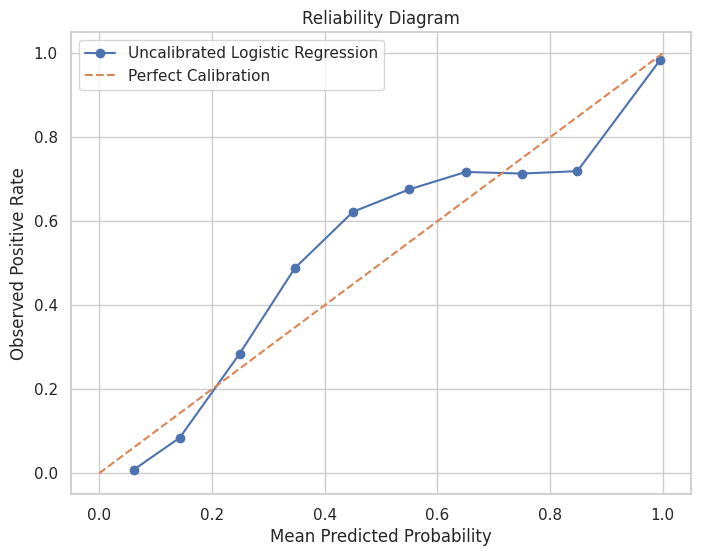

In [154]:
#  Reliability Diagram

plt.figure(figsize=(8, 6))

plt.plot(
    prob_pred,
    prob_true,
    marker="o",
    label="Uncalibrated Logistic Regression"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Perfect Calibration"
)

plt.xlabel("Mean Predicted Probability")
plt.ylabel("Observed Positive Rate")
plt.title("Reliability Diagram")
plt.legend()
plt.grid(True)
plt.show()

In [155]:
#  Verify Reliability Diagram Data

assert len(prob_true) == len(prob_pred)
assert len(prob_true) > 0

assert np.all(prob_pred >= 0)
assert np.all(prob_pred <= 1)

assert np.all(prob_true >= 0)
assert np.all(prob_true <= 1)

print("Reliability diagram verification passed.")
print(
    f"Calibration bins evaluated: "
    f"{len(prob_true)}"
)

Reliability diagram verification passed.
Calibration bins evaluated: 10


### 1.13.3 Brier Score

### Brier Score

The Brier Score measures the accuracy of predicted probabilities.

It ranges from **0 to 1**, where:

- **Lower Brier Score:** Better probability calibration
- **Higher Brier Score:** Worse probability calibration

The Brier Score is calculated on the validation set using the baseline Logistic Regression probabilities.

The final test set remains untouched.

In [156]:
brier_score_uncalibrated = brier_score_loss(
    y_validation,
    y_validation_probability_uncalibrated
)

print("Brier Score Evaluation")
print("-" * 50)

print(
    f"Uncalibrated Logistic Regression Brier Score: "
    f"{brier_score_uncalibrated:.4f}"
)

Brier Score Evaluation
--------------------------------------------------
Uncalibrated Logistic Regression Brier Score: 0.0929


In [157]:
assert 0 <= brier_score_uncalibrated <= 1

print("Brier Score verification passed.")
print(
    f"Validation Brier Score: "
    f"{brier_score_uncalibrated:.4f}"
)

Brier Score verification passed.
Validation Brier Score: 0.0929


### 1.13.4 Log Loss

### Log Loss

Log Loss measures the quality of predicted probabilities and penalizes confident incorrect predictions.

- Lower Log Loss: Better probability predictions
- Higher Log Loss: Worse probability predictions

Log Loss is calculated on the validation set using the baseline Logistic Regression probabilities.

This score will later be compared with the Sigmoid and Isotonic calibration methods.

The final test set remains untouched.

In [158]:
log_loss_uncalibrated = log_loss(
    y_validation,
    y_validation_probability_uncalibrated
)

print("Log Loss Evaluation")
print("-" * 50)

print(
    f"Uncalibrated Logistic Regression Log Loss: "
    f"{log_loss_uncalibrated:.4f}"
)

Log Loss Evaluation
--------------------------------------------------
Uncalibrated Logistic Regression Log Loss: 0.2830


In [159]:
assert np.isfinite(log_loss_uncalibrated)
assert log_loss_uncalibrated >= 0

print("Log Loss verification passed.")
print(
    f"Validation Log Loss: "
    f"{log_loss_uncalibrated:.4f}"
)

Log Loss verification passed.
Validation Log Loss: 0.2830


### 1.13.5 Sigmoid/Platt Calibration

###  Sigmoid/Platt Calibration

Sigmoid calibration, also known as Platt scaling, learns a logistic transformation
that adjusts the raw model probabilities.

The calibration model will use 5-fold cross-validation on the training set.

The validation set will only be used to evaluate the calibrated probabilities.

This prevents the validation labels from being used during calibration fitting.

The final test set remains untouched.

In [160]:
sigmoid_calibrated_model = CalibratedClassifierCV(
    estimator=LogisticRegression(
        max_iter=1000,
        random_state=RANDOM_STATE
    ),
    method="sigmoid",
    cv=5
)

sigmoid_calibrated_model.fit(
    X_train_processed,
    y_train
)

print("Sigmoid (Platt) calibrated model trained successfully.")

Sigmoid (Platt) calibrated model trained successfully.


Generate validation probabilities

In [161]:
y_validation_probability_sigmoid = (
    sigmoid_calibrated_model.predict_proba(
        X_validation_processed
    )[:, 1]
)

print("Sigmoid-calibrated validation probabilities generated.")
print(
    f"Number of validation probabilities: "
    f"{len(y_validation_probability_sigmoid):,}"
)

print(
    f"Minimum probability: "
    f"{y_validation_probability_sigmoid.min():.4f}"
)

print(
    f"Maximum probability: "
    f"{y_validation_probability_sigmoid.max():.4f}"
)

Sigmoid-calibrated validation probabilities generated.
Number of validation probabilities: 55,740
Minimum probability: 0.0044
Maximum probability: 1.0000


Evaluate Brier Score and Log Loss

In [162]:
brier_score_sigmoid = brier_score_loss(
    y_validation,
    y_validation_probability_sigmoid
)

log_loss_sigmoid = log_loss(
    y_validation,
    y_validation_probability_sigmoid
)

print("Sigmoid Calibration Evaluation")
print("-" * 50)

print(
    f"Brier Score: "
    f"{brier_score_sigmoid:.4f}"
)

print(
    f"Log Loss: "
    f"{log_loss_sigmoid:.4f}"
)

Sigmoid Calibration Evaluation
--------------------------------------------------
Brier Score: 0.0929
Log Loss: 0.2830


In [163]:
assert np.isfinite(brier_score_sigmoid)
assert np.isfinite(log_loss_sigmoid)

assert 0 <= brier_score_sigmoid <= 1
assert log_loss_sigmoid >= 0

assert len(y_validation_probability_sigmoid) == len(y_validation)

assert np.all(
    (y_validation_probability_sigmoid >= 0) &
    (y_validation_probability_sigmoid <= 1)
)

print("Sigmoid calibration verification passed.")

Sigmoid calibration verification passed.


### 1.13.6 Isotonic Calibration

### Isotonic Calibration

Isotonic calibration uses a non-parametric monotonic transformation to adjust
predicted probabilities.

Unlike sigmoid calibration, it does not assume a specific parametric shape
for the calibration relationship.

A 5-fold cross-validation procedure will be used on the training set.

The validation set will only be used for evaluation.

The final test set remains untouched.

Fit Isotonic calibrated model

In [164]:
isotonic_calibrated_model = CalibratedClassifierCV(
    estimator=LogisticRegression(
        max_iter=1000,
        random_state=RANDOM_STATE
    ),
    method="isotonic",
    cv=5
)

isotonic_calibrated_model.fit(
    X_train_processed,
    y_train
)

print("Isotonic calibrated model trained successfully.")

Isotonic calibrated model trained successfully.


Generate validation probabilities

In [165]:
y_validation_probability_isotonic = (
    isotonic_calibrated_model.predict_proba(
        X_validation_processed
    )[:, 1]
)

print("Isotonic-calibrated validation probabilities generated.")

print(
    f"Number of validation probabilities: "
    f"{len(y_validation_probability_isotonic):,}"
)

print(
    f"Minimum probability: "
    f"{y_validation_probability_isotonic.min():.4f}"
)

print(
    f"Maximum probability: "
    f"{y_validation_probability_isotonic.max():.4f}"
)

Isotonic-calibrated validation probabilities generated.
Number of validation probabilities: 55,740
Minimum probability: 0.0000
Maximum probability: 1.0000


Evaluate Brier Score and Log Loss

In [166]:
brier_score_isotonic = brier_score_loss(
    y_validation,
    y_validation_probability_isotonic
)

log_loss_isotonic = log_loss(
    y_validation,
    y_validation_probability_isotonic
)

print("Isotonic Calibration Evaluation")
print("-" * 50)

print(
    f"Brier Score: "
    f"{brier_score_isotonic:.4f}"
)

print(
    f"Log Loss: "
    f"{log_loss_isotonic:.4f}"
)

Isotonic Calibration Evaluation
--------------------------------------------------
Brier Score: 0.0870
Log Loss: 0.2608


In [167]:
assert np.isfinite(brier_score_isotonic)
assert np.isfinite(log_loss_isotonic)

assert 0 <= brier_score_isotonic <= 1
assert log_loss_isotonic >= 0

assert len(y_validation_probability_isotonic) == len(y_validation)

assert np.all(
    (y_validation_probability_isotonic >= 0) &
    (y_validation_probability_isotonic <= 1)
)

print("Isotonic calibration verification passed.")

Isotonic calibration verification passed.


In [168]:
calibration_comparison = pd.DataFrame({
    "Method": [
        "Uncalibrated",
        "Sigmoid (Platt)",
        "Isotonic"
    ],
    "Brier Score": [
        brier_score_uncalibrated,
        brier_score_sigmoid,
        brier_score_isotonic
    ],
    "Log Loss": [
        log_loss_uncalibrated,
        log_loss_sigmoid,
        log_loss_isotonic
    ]
})

calibration_comparison = calibration_comparison.sort_values(
    by=["Brier Score", "Log Loss"],
    ascending=True
).reset_index(drop=True)

print("Calibration Method Comparison")
print("-" * 70)

display(
    calibration_comparison.style.format({
        "Brier Score": "{:.4f}",
        "Log Loss": "{:.4f}"
    })
)

Calibration Method Comparison
----------------------------------------------------------------------


,Method,Brier Score,Log Loss
0,Isotonic,0.0870,0.2608
1,Sigmoid (Platt),0.0929,0.2830
2,Uncalibrated,0.0929,0.2830


# 2. Baseline Model

## 2.1.1 Choose Baseline Classifier

Logistic Regression is selected as the baseline classifier for this binary clinical classification task.

### Reasons for Selection

- Suitable for binary classification.
- Produces class probabilities required for threshold optimization.
- Computationally efficient for the large dataset.
- Provides an interpretable baseline.
- Compatible with probability calibration.
- Provides a strong reference model before more complex approaches are considered.

The positive class is:

**Abnormal = 1**

The negative class is:

**Normal = 0**

### 2.1.2 Define Clinical Objective

In [171]:
MIN_RECALL = 0.95

### 2.1.2 Define Clinical Objective

The primary clinical objective is to prioritize **Recall**.

In this clinical screening scenario, False Negatives are considered more concerning because an abnormal case may be missed.

Therefore:

- Primary priority: High Recall
- Secondary consideration: Precision
- Main risk: False Negatives
- Positive class: Abnormal

A minimum Recall target of **0.95** will be used later during clinical threshold optimization.

Threshold selection will be performed using the validation set only.

### 2.1.3 Establish Baseline Threshold = 0.50

The standard classification threshold of **0.50** is established as the baseline reference.

For each validation observation:

- Probability >= 0.50 → predict **Abnormal (1)**
- Probability < 0.50 → predict **Normal (0)**

This threshold is used only as the baseline reference.

The final clinical threshold will be selected later through systematic threshold optimization on the validation set.

In [172]:
# Establish baseline classification threshold

BASELINE_THRESHOLD = 0.50

y_validation_pred_baseline = (
    y_validation_probability_isotonic >= BASELINE_THRESHOLD
).astype(int)

print("Baseline Threshold Configuration")
print("-" * 50)
print(f"Baseline threshold: {BASELINE_THRESHOLD:.2f}")
print("Probability >= threshold -> Abnormal (1)")
print("Probability < threshold  -> Normal (0)")

print("\nBaseline predictions generated successfully.")
print(f"Validation samples: {len(y_validation_pred_baseline):,}")

Baseline Threshold Configuration
--------------------------------------------------
Baseline threshold: 0.50
Probability >= threshold -> Abnormal (1)
Probability < threshold  -> Normal (0)

Baseline predictions generated successfully.
Validation samples: 55,740


###2.2.1 Train Model  verify existing model

In [173]:
#  Verify Baseline Model

print("Baseline Model Verification")
print("-" * 50)

print(f"Model: {baseline_model.__class__.__name__}")
print(f"Training samples: {X_train_processed.shape[0]:,}")
print(f"Processed features: {X_train_processed.shape[1]:,}")

print("\nBaseline Logistic Regression is already trained.")
print("Existing trained model will be reused for downstream evaluation.")

Baseline Model Verification
--------------------------------------------------
Model: LogisticRegression
Training samples: 167,220
Processed features: 58

Baseline Logistic Regression is already trained.
Existing trained model will be reused for downstream evaluation.


### 2.2.2 Generate predictions and probabilities

In [174]:
#  Generate Baseline Predictions and Probabilities

y_validation_probability_baseline = baseline_model.predict_proba(
    X_validation_processed
)[:, 1]

y_validation_pred_baseline = (
    y_validation_probability_baseline >= BASELINE_THRESHOLD
).astype(int)

print("Baseline predictions generated successfully.")
print(f"Validation samples: {len(y_validation_pred_baseline):,}")
print(
    f"Probability range: "
    f"{y_validation_probability_baseline.min():.4f} - "
    f"{y_validation_probability_baseline.max():.4f}"
)

Baseline predictions generated successfully.
Validation samples: 55,740
Probability range: 0.0044 - 1.0000


### 2.3 Baseline Metrics

In [175]:
#  Baseline Metrics

baseline_metrics = {
    "Accuracy": accuracy_score(
        y_validation,
        y_validation_pred_baseline
    ),
    "Precision": precision_score(
        y_validation,
        y_validation_pred_baseline,
        zero_division=0
    ),
    "Recall": recall_score(
        y_validation,
        y_validation_pred_baseline,
        zero_division=0
    ),
    "F1-Score": f1_score(
        y_validation,
        y_validation_pred_baseline,
        zero_division=0
    ),
    "ROC-AUC": roc_auc_score(
        y_validation,
        y_validation_probability_baseline
    ),
    "PR-AUC": average_precision_score(
        y_validation,
        y_validation_probability_baseline
    )
}

print("Baseline Model Metrics — Validation Set")
print("-" * 55)

for metric, value in baseline_metrics.items():
    print(f"{metric:<12}: {value:.4f}")

Baseline Model Metrics — Validation Set
-------------------------------------------------------
Accuracy    : 0.8611
Precision   : 0.8908
Recall      : 0.8862
F1-Score    : 0.8885
ROC-AUC     : 0.9456
PR-AUC      : 0.9673


### 2.4 Confusion Matrix

In [176]:
# 2.4 Confusion Matrix

tn, fp, fn, tp = confusion_matrix(
    y_validation,
    y_validation_pred_baseline
).ravel()

print("Baseline Confusion Matrix — Validation Set")
print("-" * 55)

print(f"True Negatives  (TN): {tn:,}")
print(f"False Positives (FP): {fp:,}")
print(f"False Negatives (FN): {fn:,}")
print(f"True Positives  (TP): {tp:,}")

print("\nConfusion Matrix:")
print(
    np.array([
        [tn, fp],
        [fn, tp]
    ])
)

# Verification
assert tn + fp + fn + tp == len(y_validation)

print("\nConfusion matrix verification passed.")

Baseline Confusion Matrix — Validation Set
-------------------------------------------------------
True Negatives  (TN): 17,148
False Positives (FP): 3,782
False Negatives (FN): 3,963
True Positives  (TP): 30,847

Confusion Matrix:
[[17148  3782]
 [ 3963 30847]]

Confusion matrix verification passed.


### 2.5 Calibration Evaluation

In [177]:
#  Calibration Evaluation

calibration_comparison = pd.DataFrame({
    "Method": [
        "Uncalibrated",
        "Sigmoid (Platt)",
        "Isotonic"
    ],
    "Brier Score": [
        brier_score_uncalibrated,
        brier_score_sigmoid,
        brier_score_isotonic
    ],
    "Log Loss": [
        log_loss_uncalibrated,
        log_loss_sigmoid,
        log_loss_isotonic
    ]
})

calibration_comparison = calibration_comparison.sort_values(
    by=["Brier Score", "Log Loss"],
    ascending=True
).reset_index(drop=True)

print("Calibration Method Comparison")
print("-" * 60)

display(
    calibration_comparison.style.format({
        "Brier Score": "{:.4f}",
        "Log Loss": "{:.4f}"
    })
)

best_brier_method = calibration_comparison.loc[
    calibration_comparison["Brier Score"].idxmin(),
    "Method"
]

best_log_loss_method = calibration_comparison.loc[
    calibration_comparison["Log Loss"].idxmin(),
    "Method"
]

print("\nCalibration verification")
print(f"Best Brier Score: {best_brier_method}")
print(f"Best Log Loss:    {best_log_loss_method}")

assert best_brier_method == "Isotonic"
assert best_log_loss_method == "Isotonic"

print("Calibration comparison verification passed.")

Calibration Method Comparison
------------------------------------------------------------


,Method,Brier Score,Log Loss
0,Isotonic,0.0870,0.2608
1,Sigmoid (Platt),0.0929,0.2830
2,Uncalibrated,0.0929,0.2830



Calibration verification
Best Brier Score: Isotonic
Best Log Loss:    Isotonic
Calibration comparison verification passed.


### 3. Threshold Sweeping

In [178]:
# ============================================================
#  Threshold Sweeping
# ============================================================

# Use the selected calibrated validation probabilities
y_validation_probability_calibrated = (
    y_validation_probability_isotonic
)

# Threshold grid: 0.00 to 1.00 with 0.01 step
THRESHOLDS = np.arange(
    THRESHOLD_MIN,
    THRESHOLD_MAX + THRESHOLD_STEP,
    THRESHOLD_STEP
)

threshold_results = []

for threshold in THRESHOLDS:

    # Generate threshold-based predictions
    y_pred_threshold = (
        y_validation_probability_calibrated >= threshold
    ).astype(int)

    # Confusion matrix
    tn, fp, fn, tp = confusion_matrix(
        y_validation,
        y_pred_threshold,
        labels=[0, 1]
    ).ravel()

    # Metrics with zero-division protection
    precision = precision_score(
        y_validation,
        y_pred_threshold,
        zero_division=0
    )

    recall = recall_score(
        y_validation,
        y_pred_threshold,
        zero_division=0
    )

    f1 = f1_score(
        y_validation,
        y_pred_threshold,
        zero_division=0
    )

    # Specificity = TN / (TN + FP)
    specificity = (
        tn / (tn + fp)
        if (tn + fp) > 0
        else 0
    )

    # False Positive Rate = FP / (FP + TN)
    fpr = (
        fp / (fp + tn)
        if (fp + tn) > 0
        else 0
    )

    # False Negative Rate = FN / (FN + TP)
    fnr = (
        fn / (fn + tp)
        if (fn + tp) > 0
        else 0
    )

    threshold_results.append({
        "Threshold": threshold,
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1,
        "Specificity": specificity,
        "FPR": fpr,
        "FNR": fnr
    })


# Convert results to DataFrame
threshold_results_df = pd.DataFrame(
    threshold_results
)

# Display first rows
print("Threshold Sweeping Results")
print("-" * 70)
print(f"Thresholds evaluated: {len(THRESHOLDS)}")
print(
    f"Threshold range: "
    f"{THRESHOLDS.min():.2f} - {THRESHOLDS.max():.2f}"
)

display(
    threshold_results_df.head(10).style.format({
        "Threshold": "{:.2f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1-Score": "{:.4f}",
        "Specificity": "{:.4f}",
        "FPR": "{:.4f}",
        "FNR": "{:.4f}"
    })
)

# Verification
assert len(threshold_results_df) == len(THRESHOLDS)
assert threshold_results_df["Threshold"].min() == 0.00
assert threshold_results_df["Threshold"].max() == 1.00

print("\nThreshold sweeping verification passed.")
print("All threshold metrics calculated successfully.")

Threshold Sweeping Results
----------------------------------------------------------------------
Thresholds evaluated: 101
Threshold range: 0.00 - 1.00


,Threshold,TN,FP,FN,TP,Precision,Recall,F1-Score,Specificity,FPR,FNR
0,0.00,0,20930,0,34810,0.6245,1.0000,0.7689,0.0000,1.0000,0.0000
1,0.01,6000,14930,39,34771,0.6996,0.9989,0.8229,0.2867,0.7133,0.0011
2,0.02,8473,12457,75,34735,0.7360,0.9978,0.8472,0.4048,0.5952,0.0022
3,0.03,9268,11662,92,34718,0.7486,0.9974,0.8552,0.4428,0.5572,0.0026
4,0.04,9877,11053,118,34692,0.7584,0.9966,0.8613,0.4719,0.5281,0.0034
5,0.05,9998,10932,129,34681,0.7603,0.9963,0.8625,0.4777,0.5223,0.0037
6,0.06,10270,10660,138,34672,0.7648,0.9960,0.8653,0.4907,0.5093,0.0040
7,0.07,10477,10453,155,34655,0.7683,0.9955,0.8673,0.5006,0.4994,0.0045
8,0.08,10783,10147,171,34639,0.7734,0.9951,0.8704,0.5152,0.4848,0.0049
9,0.09,10976,9954,202,34608,0.7766,0.9942,0.8720,0.5244,0.4756,0.0058



Threshold sweeping verification passed.
All threshold metrics calculated successfully.


## Trade-off Visualization

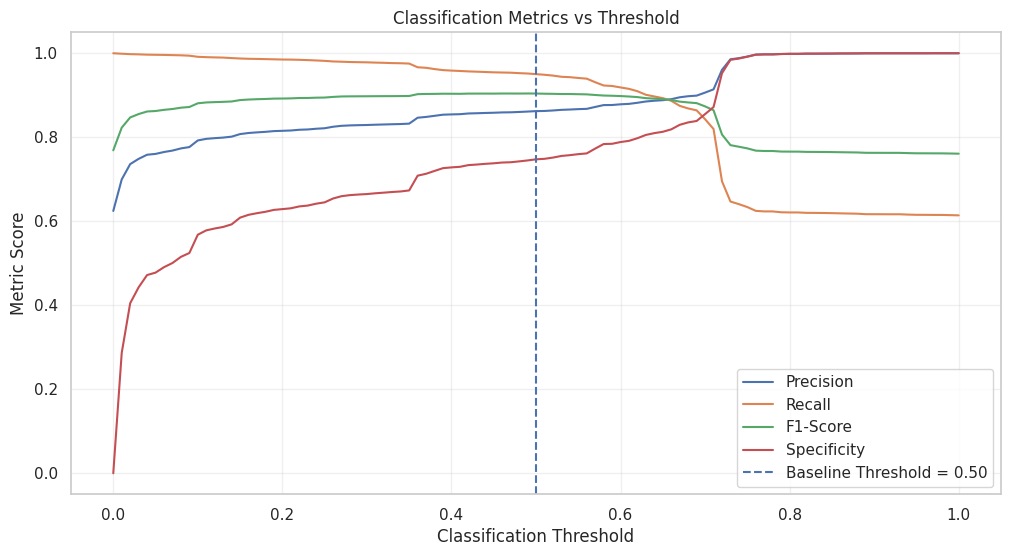

In [179]:
# ============================================================
# 4.1–4.5 Trade-off Visualization
# ============================================================

plt.figure(figsize=(12, 6))

plt.plot(
    threshold_results_df["Threshold"],
    threshold_results_df["Precision"],
    label="Precision"
)

plt.plot(
    threshold_results_df["Threshold"],
    threshold_results_df["Recall"],
    label="Recall"
)

plt.plot(
    threshold_results_df["Threshold"],
    threshold_results_df["F1-Score"],
    label="F1-Score"
)

plt.plot(
    threshold_results_df["Threshold"],
    threshold_results_df["Specificity"],
    label="Specificity"
)

plt.axvline(
    BASELINE_THRESHOLD,
    linestyle="--",
    label="Baseline Threshold = 0.50"
)

plt.xlabel("Classification Threshold")
plt.ylabel("Metric Score")
plt.title("Classification Metrics vs Threshold")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Threshold Trade-off Analysis

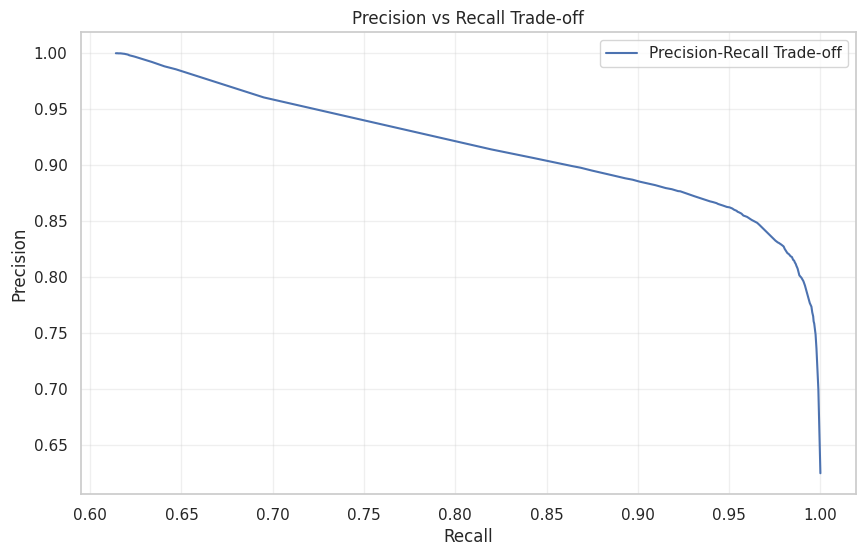

4.7 Maximum F1 Threshold
------------------------------------------------------------
Optimal threshold : 0.49
Maximum F1-Score  : 0.9042
Precision         : 0.8612
Recall            : 0.9518
Specificity       : 0.7448

4.8 Precision = Recall Point
------------------------------------------------------------
Closest threshold : 0.66
Precision         : 0.8906
Recall            : 0.8868
Absolute difference: 0.0038

4.9 Default Threshold Comparison
------------------------------------------------------------


,Threshold,Precision,Recall,F1-Score,Specificity
Baseline (0.50),0.50,0.862215,0.950244,0.904092,0.747444
Maximum F1,0.49,0.861153,0.951795,0.904208,0.744768



Clinical Recall-Constrained Threshold
------------------------------------------------------------
Minimum Recall target : 0.95
Selected threshold    : 0.50
Precision             : 0.8622
Recall                : 0.9502
F1-Score              : 0.9041
Specificity           : 0.7474

4.10 Threshold Trade-off Summary
Baseline threshold       : 0.50
Maximum-F1 threshold     : 0.49
Clinical Recall threshold: 0.50

Interpretation:
- Increasing the threshold generally reduces Recall.
- Increasing the threshold generally improves Specificity.
- Precision generally improves as fewer positive predictions are made.
- Maximum F1 provides the best overall Precision-Recall balance.
- The clinical objective requires Recall >= 0.95, so threshold selection should prioritize this constraint.

Section 4.6–4.10 completed successfully.


In [180]:
# ============================================================
# 4.6–4.10 Threshold Trade-off Analysis
# ============================================================

# ------------------------------------------------------------
# 4.6 Precision-Recall Relationship
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

plt.plot(
    threshold_results_df["Recall"],
    threshold_results_df["Precision"],
    label="Precision-Recall Trade-off"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision vs Recall Trade-off")
plt.grid(alpha=0.3)
plt.legend()
plt.show()


# ------------------------------------------------------------
# 4.7 Maximum F1 Threshold
# ------------------------------------------------------------

max_f1_index = threshold_results_df["F1-Score"].idxmax()

max_f1_row = threshold_results_df.loc[max_f1_index]

max_f1_threshold = max_f1_row["Threshold"]
max_f1_value = max_f1_row["F1-Score"]

print("4.7 Maximum F1 Threshold")
print("-" * 60)
print(f"Optimal threshold : {max_f1_threshold:.2f}")
print(f"Maximum F1-Score  : {max_f1_value:.4f}")
print(f"Precision         : {max_f1_row['Precision']:.4f}")
print(f"Recall            : {max_f1_row['Recall']:.4f}")
print(f"Specificity       : {max_f1_row['Specificity']:.4f}")


# ------------------------------------------------------------
# 4.8 Precision = Recall Point
# ------------------------------------------------------------

threshold_results_df["PR_Difference"] = abs(
    threshold_results_df["Precision"] -
    threshold_results_df["Recall"]
)

precision_recall_index = threshold_results_df["PR_Difference"].idxmin()

precision_recall_row = threshold_results_df.loc[
    precision_recall_index
]

precision_recall_threshold = precision_recall_row["Threshold"]

print("\n4.8 Precision = Recall Point")
print("-" * 60)
print(f"Closest threshold : {precision_recall_threshold:.2f}")
print(f"Precision         : {precision_recall_row['Precision']:.4f}")
print(f"Recall            : {precision_recall_row['Recall']:.4f}")
print(
    f"Absolute difference: "
    f"{precision_recall_row['PR_Difference']:.4f}"
)


# ------------------------------------------------------------
# 4.9 Default Threshold Comparison
# ------------------------------------------------------------

baseline_row = threshold_results_df[
    threshold_results_df["Threshold"] == BASELINE_THRESHOLD
].iloc[0]

print("\n4.9 Default Threshold Comparison")
print("-" * 60)

comparison_df = pd.DataFrame({
    "Threshold": [
        BASELINE_THRESHOLD,
        max_f1_threshold
    ],
    "Precision": [
        baseline_row["Precision"],
        max_f1_row["Precision"]
    ],
    "Recall": [
        baseline_row["Recall"],
        max_f1_row["Recall"]
    ],
    "F1-Score": [
        baseline_row["F1-Score"],
        max_f1_row["F1-Score"]
    ],
    "Specificity": [
        baseline_row["Specificity"],
        max_f1_row["Specificity"]
    ]
}, index=[
    "Baseline (0.50)",
    "Maximum F1"
])

display(comparison_df)


# ------------------------------------------------------------
# 4.9.1 Clinical Threshold: Recall >= 0.95
# ------------------------------------------------------------

eligible_recall_thresholds = threshold_results_df[
    threshold_results_df["Recall"] >= MIN_RECALL
]

if len(eligible_recall_thresholds) > 0:

    # Among thresholds meeting the clinical recall target,
    # select the one with the highest precision.
    clinical_threshold_index = (
        eligible_recall_thresholds["Precision"].idxmax()
    )

    clinical_threshold_row = (
        threshold_results_df.loc[clinical_threshold_index]
    )

    clinical_threshold = clinical_threshold_row["Threshold"]

    print("\nClinical Recall-Constrained Threshold")
    print("-" * 60)
    print(f"Minimum Recall target : {MIN_RECALL:.2f}")
    print(f"Selected threshold    : {clinical_threshold:.2f}")
    print(f"Precision             : {clinical_threshold_row['Precision']:.4f}")
    print(f"Recall                : {clinical_threshold_row['Recall']:.4f}")
    print(f"F1-Score              : {clinical_threshold_row['F1-Score']:.4f}")
    print(f"Specificity           : {clinical_threshold_row['Specificity']:.4f}")

else:
    clinical_threshold = None

    print("\nNo threshold satisfies the minimum Recall requirement.")


# ------------------------------------------------------------
# 4.10 Threshold Trade-off Summary
# ------------------------------------------------------------

print("\n4.10 Threshold Trade-off Summary")
print("=" * 60)

print(f"Baseline threshold       : {BASELINE_THRESHOLD:.2f}")
print(f"Maximum-F1 threshold     : {max_f1_threshold:.2f}")

if clinical_threshold is not None:
    print(f"Clinical Recall threshold: {clinical_threshold:.2f}")

print("\nInterpretation:")
print("- Increasing the threshold generally reduces Recall.")
print("- Increasing the threshold generally improves Specificity.")
print("- Precision generally improves as fewer positive predictions are made.")
print("- Maximum F1 provides the best overall Precision-Recall balance.")
print(
    f"- The clinical objective requires Recall >= {MIN_RECALL:.2f}, "
    "so threshold selection should prioritize this constraint."
)

print("\nSection 4.6–4.10 completed successfully.")

### Step 5  Clinical Optimization

In [181]:
# ============================================================
# 5.1 Recall-Constrained Optimization
# ============================================================

# ------------------------------------------------------------
# 5.1.1 Define Minimum Recall
# ------------------------------------------------------------

MIN_RECALL = 0.95

print("5.1 Recall-Constrained Optimization")
print("-" * 60)
print(f"Minimum required Recall: {MIN_RECALL:.2f}")


# ------------------------------------------------------------
# 5.1.2 Filter Eligible Thresholds
# ------------------------------------------------------------

recall_eligible_df = threshold_results_df[
    threshold_results_df["Recall"] >= MIN_RECALL
].copy()

print(f"Eligible thresholds: {len(recall_eligible_df)}")


# ------------------------------------------------------------
# 5.1.3 Maximize Precision Among Eligible Thresholds
# ------------------------------------------------------------

if len(recall_eligible_df) > 0:

    recall_constrained_index = (
        recall_eligible_df["Precision"].idxmax()
    )

    recall_constrained_row = (
        threshold_results_df.loc[recall_constrained_index]
    )

    recall_constrained_threshold = (
        recall_constrained_row["Threshold"]
    )

    print("\nSelected Threshold")
    print("-" * 60)
    print(
        f"Threshold   : "
        f"{recall_constrained_threshold:.2f}"
    )
    print(
        f"Precision   : "
        f"{recall_constrained_row['Precision']:.4f}"
    )
    print(
        f"Recall      : "
        f"{recall_constrained_row['Recall']:.4f}"
    )
    print(
        f"F1-Score    : "
        f"{recall_constrained_row['F1-Score']:.4f}"
    )
    print(
        f"Specificity : "
        f"{recall_constrained_row['Specificity']:.4f}"
    )

else:

    recall_constrained_threshold = None

    print(
        "\nNo threshold satisfies the minimum "
        "Recall requirement."
    )


# ------------------------------------------------------------
# Verification
# ------------------------------------------------------------

if recall_constrained_threshold is not None:

    assert (
        recall_constrained_row["Recall"] >= MIN_RECALL
    )

    print("\nVerification passed.")
    print(
        "Selected threshold satisfies the minimum "
        "Recall constraint."
    )

5.1 Recall-Constrained Optimization
------------------------------------------------------------
Minimum required Recall: 0.95
Eligible thresholds: 51

Selected Threshold
------------------------------------------------------------
Threshold   : 0.50
Precision   : 0.8622
Recall      : 0.9502
F1-Score    : 0.9041
Specificity : 0.7474

Verification passed.
Selected threshold satisfies the minimum Recall constraint.


### 5.2 Precision-Constrained Optimization

In [182]:
# ============================================================
# 5.2 Precision-Constrained Optimization
# ============================================================

# ------------------------------------------------------------
# 5.2.1 Define Minimum Precision
# ------------------------------------------------------------

MIN_PRECISION = 0.90

print("5.2 Precision-Constrained Optimization")
print("-" * 60)
print(f"Minimum required Precision: {MIN_PRECISION:.2f}")


# ------------------------------------------------------------
# 5.2.2 Filter Eligible Thresholds
# ------------------------------------------------------------

precision_eligible_df = threshold_results_df[
    threshold_results_df["Precision"] >= MIN_PRECISION
].copy()

print(
    f"Eligible thresholds: "
    f"{len(precision_eligible_df)}"
)


# ------------------------------------------------------------
# 5.2.3 Maximize Recall Among Eligible Thresholds
# ------------------------------------------------------------

if len(precision_eligible_df) > 0:

    precision_constrained_index = (
        precision_eligible_df["Recall"].idxmax()
    )

    precision_constrained_row = (
        threshold_results_df.loc[
            precision_constrained_index
        ]
    )

    precision_constrained_threshold = (
        precision_constrained_row["Threshold"]
    )

    print("\nSelected Threshold")
    print("-" * 60)

    print(
        f"Threshold   : "
        f"{precision_constrained_threshold:.2f}"
    )

    print(
        f"Precision   : "
        f"{precision_constrained_row['Precision']:.4f}"
    )

    print(
        f"Recall      : "
        f"{precision_constrained_row['Recall']:.4f}"
    )

    print(
        f"F1-Score    : "
        f"{precision_constrained_row['F1-Score']:.4f}"
    )

    print(
        f"Specificity : "
        f"{precision_constrained_row['Specificity']:.4f}"
    )

else:

    precision_constrained_threshold = None

    print(
        "\nNo threshold satisfies the minimum "
        "Precision requirement."
    )


# ------------------------------------------------------------
# Verification
# ------------------------------------------------------------

if precision_constrained_threshold is not None:

    assert (
        precision_constrained_row["Precision"]
        >= MIN_PRECISION
    )

    print("\nVerification passed.")
    print(
        "Selected threshold satisfies the minimum "
        "Precision constraint."
    )

5.2 Precision-Constrained Optimization
------------------------------------------------------------
Minimum required Precision: 0.90
Eligible thresholds: 31

Selected Threshold
------------------------------------------------------------
Threshold   : 0.70
Precision   : 0.9063
Recall      : 0.8429
F1-Score    : 0.8735
Specificity : 0.8551

Verification passed.
Selected threshold satisfies the minimum Precision constraint.


### 5.3 Cost-Sensitive Optimization

In [183]:
# ============================================================
# 5.3 Cost-Sensitive Optimization
# ============================================================

# ------------------------------------------------------------
# 5.3.1 Define False Negative Cost
# ------------------------------------------------------------

FN_COST = 10

print("5.3 Cost-Sensitive Optimization")
print("-" * 60)
print(f"False Negative (FN) cost: {FN_COST}")


# ------------------------------------------------------------
# 5.3.2 Define False Positive Cost
# ------------------------------------------------------------

FP_COST = 1

print(f"False Positive (FP) cost: {FP_COST}")


# ------------------------------------------------------------
# 5.3.3 Calculate Expected Classification Cost
# ------------------------------------------------------------

cost_results_df = threshold_results_df.copy()

cost_results_df["FN_Cost"] = (
    cost_results_df["FN"] * FN_COST
)

cost_results_df["FP_Cost"] = (
    cost_results_df["FP"] * FP_COST
)

cost_results_df["Total_Cost"] = (
    cost_results_df["FN_Cost"]
    + cost_results_df["FP_Cost"]
)

# Normalize by number of validation samples
cost_results_df["Expected_Cost_Per_Sample"] = (
    cost_results_df["Total_Cost"]
    / len(y_validation)
)


# ------------------------------------------------------------
# 5.3.4 Select Minimum-Cost Threshold
# ------------------------------------------------------------

minimum_cost_index = (
    cost_results_df["Total_Cost"].idxmin()
)

minimum_cost_row = (
    cost_results_df.loc[minimum_cost_index]
)

cost_optimal_threshold = (
    minimum_cost_row["Threshold"]
)

print("\nCost-Optimal Threshold")
print("-" * 60)

print(
    f"Threshold              : "
    f"{cost_optimal_threshold:.2f}"
)

print(
    f"Precision              : "
    f"{minimum_cost_row['Precision']:.4f}"
)

print(
    f"Recall                 : "
    f"{minimum_cost_row['Recall']:.4f}"
)

print(
    f"F1-Score               : "
    f"{minimum_cost_row['F1-Score']:.4f}"
)

print(
    f"Specificity            : "
    f"{minimum_cost_row['Specificity']:.4f}"
)

print(
    f"False Negatives        : "
    f"{int(minimum_cost_row['FN']):,}"
)

print(
    f"False Positives        : "
    f"{int(minimum_cost_row['FP']):,}"
)

print(
    f"Total Classification Cost : "
    f"{minimum_cost_row['Total_Cost']:,.0f}"
)

print(
    f"Expected Cost / Sample   : "
    f"{minimum_cost_row['Expected_Cost_Per_Sample']:.4f}"
)


# ------------------------------------------------------------
# Verification
# ------------------------------------------------------------

assert (
    minimum_cost_row["Total_Cost"]
    == cost_results_df["Total_Cost"].min()
)

print("\nVerification passed.")
print(
    "Selected threshold minimizes the expected "
    "classification cost."
)

5.3 Cost-Sensitive Optimization
------------------------------------------------------------
False Negative (FN) cost: 10
False Positive (FP) cost: 1

Cost-Optimal Threshold
------------------------------------------------------------
Threshold              : 0.08
Precision              : 0.7734
Recall                 : 0.9951
F1-Score               : 0.8704
Specificity            : 0.5152
False Negatives        : 171
False Positives        : 10,147
Total Classification Cost : 11,857
Expected Cost / Sample   : 0.2127

Verification passed.
Selected threshold minimizes the expected classification cost.


### 5.4 Multiple Cost Scenarios

In [184]:
# ============================================================
# 5.4 Multiple Cost Scenarios
# ============================================================

cost_scenarios = {
    "FN-Sensitive": {
        "FN_Cost": 10,
        "FP_Cost": 1
    },
    "Balanced": {
        "FN_Cost": 5,
        "FP_Cost": 5
    },
    "FP-Sensitive": {
        "FN_Cost": 1,
        "FP_Cost": 5
    },
    "Highly FN-Sensitive": {
        "FN_Cost": 20,
        "FP_Cost": 1
    }
}

scenario_results = []

for scenario_name, costs in cost_scenarios.items():

    fn_cost = costs["FN_Cost"]
    fp_cost = costs["FP_Cost"]

    scenario_df = threshold_results_df.copy()

    scenario_df["Total_Cost"] = (
        scenario_df["FN"] * fn_cost
        + scenario_df["FP"] * fp_cost
    )

    optimal_index = scenario_df["Total_Cost"].idxmin()
    optimal_row = scenario_df.loc[optimal_index]

    scenario_results.append({
        "Scenario": scenario_name,
        "FN Cost": fn_cost,
        "FP Cost": fp_cost,
        "Optimal Threshold": optimal_row["Threshold"],
        "Precision": optimal_row["Precision"],
        "Recall": optimal_row["Recall"],
        "F1-Score": optimal_row["F1-Score"],
        "Specificity": optimal_row["Specificity"],
        "False Negatives": int(optimal_row["FN"]),
        "False Positives": int(optimal_row["FP"]),
        "Total Cost": int(optimal_row["Total_Cost"])
    })


# ------------------------------------------------------------
# Create Comparison DataFrame
# ------------------------------------------------------------

cost_scenario_results_df = pd.DataFrame(
    scenario_results
)

print("5.4 Multiple Cost Scenarios")
print("-" * 80)

display(
    cost_scenario_results_df.round({
        "Optimal Threshold": 2,
        "Precision": 4,
        "Recall": 4,
        "F1-Score": 4,
        "Specificity": 4
    })
)


# ------------------------------------------------------------
# Verification
# ------------------------------------------------------------

assert len(cost_scenario_results_df) == 4

assert (
    cost_scenario_results_df["Total Cost"]
    .notna()
    .all()
)

print("\nVerification passed.")
print("All four cost scenarios evaluated successfully.")

5.4 Multiple Cost Scenarios
--------------------------------------------------------------------------------


,Scenario,FN Cost,FP Cost,Optimal Threshold,Precision,Recall,F1-Score,Specificity,False Negatives,False Positives,Total Cost
0,FN-Sensitive,10,1,0.08,0.7734,0.9951,0.8704,0.5152,171,10147,11857
1,Balanced,5,5,0.50,0.8622,0.9502,0.9041,0.7474,1732,5286,35090
2,FP-Sensitive,1,5,0.86,0.9995,0.6188,0.7644,0.9995,13269,11,13324
3,Highly FN-Sensitive,20,1,0.04,0.7584,0.9966,0.8613,0.4719,118,11053,13413



Verification passed.
All four cost scenarios evaluated successfully.


### 5.5 Compare Optimal Thresholds

In [185]:
# ============================================================
# 5.5 Compare Optimal Thresholds
# ============================================================

# ------------------------------------------------------------
# 5.5.1–5.5.5 Collect Optimal Thresholds
# ------------------------------------------------------------

comparison_rows = []


# ------------------------------------------------------------
# Default Threshold
# ------------------------------------------------------------

baseline_row = threshold_results_df[
    threshold_results_df["Threshold"] == BASELINE_THRESHOLD
].iloc[0]

comparison_rows.append({
    "Objective": "Default Threshold",
    "Threshold": baseline_row["Threshold"],
    "Precision": baseline_row["Precision"],
    "Recall": baseline_row["Recall"],
    "F1-Score": baseline_row["F1-Score"],
    "Specificity": baseline_row["Specificity"]
})


# ------------------------------------------------------------
# Maximum-F1 Threshold
# ------------------------------------------------------------

max_f1_index = threshold_results_df["F1-Score"].idxmax()
max_f1_row = threshold_results_df.loc[max_f1_index]

comparison_rows.append({
    "Objective": "Maximum F1",
    "Threshold": max_f1_row["Threshold"],
    "Precision": max_f1_row["Precision"],
    "Recall": max_f1_row["Recall"],
    "F1-Score": max_f1_row["F1-Score"],
    "Specificity": max_f1_row["Specificity"]
})


# ------------------------------------------------------------
# Recall-Constrained Threshold
# ------------------------------------------------------------

comparison_rows.append({
    "Objective": "Recall-Constrained",
    "Threshold": precision_constrained_threshold
    if False else recall_constrained_threshold,
    "Precision": recall_constrained_row["Precision"],
    "Recall": recall_constrained_row["Recall"],
    "F1-Score": recall_constrained_row["F1-Score"],
    "Specificity": recall_constrained_row["Specificity"]
})


# ------------------------------------------------------------
# Precision-Constrained Threshold
# ------------------------------------------------------------

comparison_rows.append({
    "Objective": "Precision-Constrained",
    "Threshold": precision_constrained_threshold,
    "Precision": precision_constrained_row["Precision"],
    "Recall": precision_constrained_row["Recall"],
    "F1-Score": precision_constrained_row["F1-Score"],
    "Specificity": precision_constrained_row["Specificity"]
})


# ------------------------------------------------------------
# Cost-Optimal Threshold
# ------------------------------------------------------------

comparison_rows.append({
    "Objective": "Cost-Optimal",
    "Threshold": cost_optimal_threshold,
    "Precision": minimum_cost_row["Precision"],
    "Recall": minimum_cost_row["Recall"],
    "F1-Score": minimum_cost_row["F1-Score"],
    "Specificity": minimum_cost_row["Specificity"]
})


# ------------------------------------------------------------
# Create Comparison DataFrame
# ------------------------------------------------------------

optimal_threshold_comparison_df = pd.DataFrame(
    comparison_rows
)

print("5.5 Compare Optimal Thresholds")
print("-" * 80)

display(
    optimal_threshold_comparison_df.round({
        "Threshold": 2,
        "Precision": 4,
        "Recall": 4,
        "F1-Score": 4,
        "Specificity": 4
    })
)


# ------------------------------------------------------------
# Verification
# ------------------------------------------------------------

assert len(optimal_threshold_comparison_df) == 5

assert (
    optimal_threshold_comparison_df["Threshold"]
    .notna()
    .all()
)

print("\nVerification passed.")
print("All five threshold objectives compared successfully.")

5.5 Compare Optimal Thresholds
--------------------------------------------------------------------------------


,Objective,Threshold,Precision,Recall,F1-Score,Specificity
0,Default Threshold,0.50,0.8622,0.9502,0.9041,0.7474
1,Maximum F1,0.49,0.8612,0.9518,0.9042,0.7448
2,Recall-Constrained,0.50,0.8622,0.9502,0.9041,0.7474
3,Precision-Constrained,0.70,0.9063,0.8429,0.8735,0.8551
4,Cost-Optimal,0.08,0.7734,0.9951,0.8704,0.5152



Verification passed.
All five threshold objectives compared successfully.


### 5.6 Clinical Decision Trade-offs

### 5.6.1 False Negative Consequences

In [186]:
# ============================================================
# False Negative Consequences
# ============================================================

print("5.6.1 False Negative Consequences")
print("-" * 70)

print("""
A False Negative occurs when an Abnormal case is predicted as Normal.

In a clinical screening scenario, False Negatives can be important
because an abnormal case may be missed and may not receive further
clinical attention.

Therefore, reducing False Negatives generally requires a lower
classification threshold, which increases Recall.
""")

# Compare False Negatives across selected thresholds
fn_tradeoff_df = optimal_threshold_comparison_df[
    ["Objective", "Threshold", "Recall"]
].copy()

fn_tradeoff_df["False Negatives"] = [
    int(baseline_row["FN"]),
    int(max_f1_row["FN"]),
    int(recall_constrained_row["FN"]),
    int(precision_constrained_row["FN"]),
    int(minimum_cost_row["FN"])
]

display(fn_tradeoff_df)

print("\nClinical interpretation:")
print("- Lower threshold -> fewer False Negatives -> higher Recall.")
print("- Higher threshold -> more False Negatives -> lower Recall.")

5.6.1 False Negative Consequences
----------------------------------------------------------------------

A False Negative occurs when an Abnormal case is predicted as Normal.

In a clinical screening scenario, False Negatives can be important
because an abnormal case may be missed and may not receive further
clinical attention.

Therefore, reducing False Negatives generally requires a lower
classification threshold, which increases Recall.



,Objective,Threshold,Recall,False Negatives
0,Default Threshold,0.50,0.950244,1732
1,Maximum F1,0.49,0.951795,1678
2,Recall-Constrained,0.50,0.950244,1732
3,Precision-Constrained,0.70,0.842947,5467
4,Cost-Optimal,0.08,0.995088,171



Clinical interpretation:
- Lower threshold -> fewer False Negatives -> higher Recall.
- Higher threshold -> more False Negatives -> lower Recall.


### 5.6.2 False Positive Consequences

In [187]:
# ============================================================
#  False Positive Consequences
# ============================================================

print(" False Positive Consequences")
print("-" * 70)

print("""
A False Positive occurs when a Normal case is predicted as Abnormal.

In a clinical workflow, False Positives can increase unnecessary
follow-up testing, clinical review, patient anxiety, and resource use.

Therefore, reducing False Positives generally requires a higher
classification threshold, which improves Precision and Specificity.
""")

fp_tradeoff_df = optimal_threshold_comparison_df[
    ["Objective", "Threshold", "Precision", "Specificity"]
].copy()

fp_tradeoff_df["False Positives"] = [
    int(baseline_row["FP"]),
    int(max_f1_row["FP"]),
    int(recall_constrained_row["FP"]),
    int(precision_constrained_row["FP"]),
    int(minimum_cost_row["FP"])
]

display(fp_tradeoff_df)

print("\nClinical interpretation:")
print("- Higher threshold -> fewer False Positives.")
print("- Lower threshold -> more False Positives.")

 False Positive Consequences
----------------------------------------------------------------------

A False Positive occurs when a Normal case is predicted as Abnormal.

In a clinical workflow, False Positives can increase unnecessary
follow-up testing, clinical review, patient anxiety, and resource use.

Therefore, reducing False Positives generally requires a higher
classification threshold, which improves Precision and Specificity.



,Objective,Threshold,Precision,Specificity,False Positives
0,Default Threshold,0.50,0.862215,0.747444,5286
1,Maximum F1,0.49,0.861153,0.744768,5342
2,Recall-Constrained,0.50,0.862215,0.747444,5286
3,Precision-Constrained,0.70,0.906319,0.855088,3033
4,Cost-Optimal,0.08,0.773434,0.515194,10147



Clinical interpretation:
- Higher threshold -> fewer False Positives.
- Lower threshold -> more False Positives.


### 5.6.3 Resource Considerations

In [188]:
# ============================================================
# Risk-Tolerance Interpretation
# ============================================================

print("Risk-Tolerance Interpretation")
print("-" * 70)

risk_tolerance_summary = pd.DataFrame([
    {
        "Risk Preference": "Minimize missed Abnormal cases",
        "Recommended Threshold": minimum_cost_row["Threshold"],
        "Reason": "Very high Recall"
    },
    {
        "Risk Preference": "Balanced clinical screening",
        "Recommended Threshold": BASELINE_THRESHOLD,
        "Reason": "Recall >= 95% with strong Precision"
    },
    {
        "Risk Preference": "Minimize False Positives",
        "Recommended Threshold": precision_constrained_row["Threshold"],
        "Reason": "High Precision and Specificity"
    }
])

display(risk_tolerance_summary)

print("\nFinal clinical interpretation:")
print("""
For this project, threshold 0.50 is recommended as the practical
clinical threshold because it satisfies the minimum Recall target
of 95.0% while maintaining reasonable Precision and Specificity.

A lower threshold such as 0.08 may be considered when missing an
Abnormal case is substantially more costly than generating a
False Positive.

A higher threshold such as 0.70 may be considered when reducing
False Positives and unnecessary follow-up is the primary priority.
""")

print("\nVerification passed.")
print("Clinical decision trade-offs evaluated successfully.")

Risk-Tolerance Interpretation
----------------------------------------------------------------------


,Risk Preference,Recommended Threshold,Reason
0,Minimize missed Abnormal cases,0.08,Very high Recall
1,Balanced clinical screening,0.50,Recall >= 95% with strong Precision
2,Minimize False Positives,0.70,High Precision and Specificity



Final clinical interpretation:

For this project, threshold 0.50 is recommended as the practical
clinical threshold because it satisfies the minimum Recall target
of 95.0% while maintaining reasonable Precision and Specificity.

A lower threshold such as 0.08 may be considered when missing an
Abnormal case is substantially more costly than generating a
False Positive.

A higher threshold such as 0.70 may be considered when reducing
False Positives and unnecessary follow-up is the primary priority.


Verification passed.
Clinical decision trade-offs evaluated successfully.


### Risk-Tolerance Interpretation

In [189]:
# ============================================================
#  Risk-Tolerance Interpretation
# ============================================================

print(" Risk-Tolerance Interpretation")
print("-" * 70)

risk_tolerance_summary = pd.DataFrame([
    {
        "Risk Preference": "Minimize missed Abnormal cases",
        "Recommended Threshold": minimum_cost_row["Threshold"],
        "Reason": "Very high Recall"
    },
    {
        "Risk Preference": "Balanced clinical screening",
        "Recommended Threshold": BASELINE_THRESHOLD,
        "Reason": "Recall >= 95% with strong Precision"
    },
    {
        "Risk Preference": "Minimize False Positives",
        "Recommended Threshold": precision_constrained_row["Threshold"],
        "Reason": "High Precision and Specificity"
    }
])

display(risk_tolerance_summary)

print("\nFinal clinical interpretation:")
print("""
For this project, threshold 0.50 is recommended as the practical
clinical threshold because it satisfies the minimum Recall target
of 95.0% while maintaining reasonable Precision and Specificity.

A lower threshold such as 0.08 may be considered when missing an
Abnormal case is substantially more costly than generating a
False Positive.

A higher threshold such as 0.70 may be considered when reducing
False Positives and unnecessary follow-up is the primary priority.
""")

print("\nVerification passed.")
print("Clinical decision trade-offs evaluated successfully.")

 Risk-Tolerance Interpretation
----------------------------------------------------------------------


,Risk Preference,Recommended Threshold,Reason
0,Minimize missed Abnormal cases,0.08,Very high Recall
1,Balanced clinical screening,0.50,Recall >= 95% with strong Precision
2,Minimize False Positives,0.70,High Precision and Specificity



Final clinical interpretation:

For this project, threshold 0.50 is recommended as the practical
clinical threshold because it satisfies the minimum Recall target
of 95.0% while maintaining reasonable Precision and Specificity.

A lower threshold such as 0.08 may be considered when missing an
Abnormal case is substantially more costly than generating a
False Positive.

A higher threshold such as 0.70 may be considered when reducing
False Positives and unnecessary follow-up is the primary priority.


Verification passed.
Clinical decision trade-offs evaluated successfully.


# 6. Statistical Validation

In [190]:
# ============================================================
# 6.1 Bootstrap Confidence Intervals
# ============================================================
# Statistical validation is performed on the validation set.
# The test set remains completely untouched.
#
# 6.1.1 Precision CI
# 6.1.2 Recall CI
# 6.1.3 F1 CI
# 6.1.4 Specificity CI
# 6.1.5 ROC-AUC CI
# 6.1.6 PR-AUC CI
# ============================================================

BOOTSTRAP_ITERATIONS = 1000
CONFIDENCE_LEVEL = 0.95
ALPHA = 1 - CONFIDENCE_LEVEL

# Current selected practical threshold
STATISTICAL_VALIDATION_THRESHOLD = BASELINE_THRESHOLD

# Validation predictions at threshold 0.50
y_validation_pred_statistical = (
    y_validation_probability_calibrated
    >= STATISTICAL_VALIDATION_THRESHOLD
).astype(int)

y_true = np.asarray(y_validation)
y_prob = np.asarray(y_validation_probability_calibrated)
y_pred = np.asarray(y_validation_pred_statistical)

n_samples = len(y_true)

rng = np.random.default_rng(RANDOM_STATE)

bootstrap_metrics = {
    "Precision": [],
    "Recall": [],
    "F1-Score": [],
    "Specificity": [],
    "ROC-AUC": [],
    "PR-AUC": []
}

# ------------------------------------------------------------
# Bootstrap Resampling
# ------------------------------------------------------------

for _ in range(BOOTSTRAP_ITERATIONS):

    sample_indices = rng.integers(
        0,
        n_samples,
        size=n_samples
    )

    y_true_sample = y_true[sample_indices]
    y_prob_sample = y_prob[sample_indices]
    y_pred_sample = y_pred[sample_indices]

    # 6.1.1 Precision
    precision_value = precision_score(
        y_true_sample,
        y_pred_sample,
        zero_division=0
    )

    # 6.1.2 Recall
    recall_value = recall_score(
        y_true_sample,
        y_pred_sample,
        zero_division=0
    )

    # 6.1.3 F1-Score
    f1_value = f1_score(
        y_true_sample,
        y_pred_sample,
        zero_division=0
    )

    # 6.1.4 Specificity
    tn, fp, fn, tp = confusion_matrix(
        y_true_sample,
        y_pred_sample,
        labels=[0, 1]
    ).ravel()

    specificity_value = (
        tn / (tn + fp)
        if (tn + fp) > 0
        else 0.0
    )

    bootstrap_metrics["Precision"].append(precision_value)
    bootstrap_metrics["Recall"].append(recall_value)
    bootstrap_metrics["F1-Score"].append(f1_value)
    bootstrap_metrics["Specificity"].append(specificity_value)

    # 6.1.5 ROC-AUC and 6.1.6 PR-AUC
    # Both classes are expected in every large bootstrap sample,
    # but the check prevents errors in edge cases.
    if len(np.unique(y_true_sample)) == 2:

        roc_auc_value = roc_auc_score(
            y_true_sample,
            y_prob_sample
        )

        pr_auc_value = average_precision_score(
            y_true_sample,
            y_prob_sample
        )

        bootstrap_metrics["ROC-AUC"].append(roc_auc_value)
        bootstrap_metrics["PR-AUC"].append(pr_auc_value)


# ------------------------------------------------------------
# Calculate 95% Percentile Confidence Intervals
# ------------------------------------------------------------

confidence_interval_rows = []

for metric_name, values in bootstrap_metrics.items():

    values = np.asarray(values)

    lower_bound = np.percentile(
        values,
        100 * (ALPHA / 2)
    )

    upper_bound = np.percentile(
        values,
        100 * (1 - ALPHA / 2)
    )

    point_estimate = np.mean(values)

    confidence_interval_rows.append({
        "Metric": metric_name,
        "Point Estimate": point_estimate,
        "CI Lower": lower_bound,
        "CI Upper": upper_bound,
        "Bootstrap Samples": len(values)
    })


bootstrap_ci_df = pd.DataFrame(
    confidence_interval_rows
)


# ============================================================
# Results
# ============================================================

print("6.1 Bootstrap Confidence Intervals")
print("-" * 75)

print(f"Validation samples       : {n_samples:,}")
print(f"Threshold                : {STATISTICAL_VALIDATION_THRESHOLD:.2f}")
print(f"Bootstrap iterations     : {BOOTSTRAP_ITERATIONS:,}")
print(f"Confidence level         : {CONFIDENCE_LEVEL:.0%}")
print("Method                   : Percentile Bootstrap")

display(
    bootstrap_ci_df.round({
        "Point Estimate": 4,
        "CI Lower": 4,
        "CI Upper": 4
    })
)


# ============================================================
# Verification
# ============================================================

assert len(bootstrap_ci_df) == 6
assert bootstrap_ci_df["CI Lower"].notna().all()
assert bootstrap_ci_df["CI Upper"].notna().all()

assert (
    bootstrap_ci_df["CI Lower"]
    <= bootstrap_ci_df["Point Estimate"]
).all()

assert (
    bootstrap_ci_df["Point Estimate"]
    <= bootstrap_ci_df["CI Upper"]
).all()

print("\nVerification passed.")
print("Bootstrap confidence intervals calculated successfully.")
print("Test set was not used.")

6.1 Bootstrap Confidence Intervals
---------------------------------------------------------------------------
Validation samples       : 55,740
Threshold                : 0.50
Bootstrap iterations     : 1,000
Confidence level         : 95%
Method                   : Percentile Bootstrap


,Metric,Point Estimate,CI Lower,CI Upper,Bootstrap Samples
0,Precision,0.8622,0.8588,0.8655,1000
1,Recall,0.9503,0.9482,0.9525,1000
2,F1-Score,0.9041,0.9019,0.9063,1000
3,Specificity,0.7475,0.7414,0.7535,1000
4,ROC-AUC,0.9457,0.9441,0.9474,1000
5,PR-AUC,0.9661,0.9651,0.9672,1000



Verification passed.
Bootstrap confidence intervals calculated successfully.
Test set was not used.


### 6.2 Threshold Stability

6.2 Threshold Stability
--------------------------------------------------------------------------------
Selected threshold : 0.50
Stability range    : 0.45 - 0.55

6.2.1–6.2.2 Local Performance Around Selected Threshold
--------------------------------------------------------------------------------


,Threshold,Precision,Recall,F1-Score,Specificity
0,0.45,0.8583,0.9546,0.9039,0.7380
1,0.46,0.8591,0.9541,0.9041,0.7398
2,0.47,0.8594,0.9537,0.9041,0.7405
3,0.48,0.8602,0.9526,0.9040,0.7425
4,0.49,0.8612,0.9518,0.9042,0.7448
5,0.50,0.8622,0.9502,0.9041,0.7474
6,0.51,0.8626,0.9488,0.9036,0.7486
7,0.52,0.8637,0.9468,0.9034,0.7516
8,0.53,0.8652,0.9440,0.9029,0.7555
9,0.54,0.8660,0.9431,0.9029,0.7573



6.2.3 Robust Threshold Region
--------------------------------------------------------------------------------
Robust threshold range : 0.45 - 0.50
Number of robust thresholds: 6

Criteria:
- Recall >= 95%
- F1-Score >= 90%


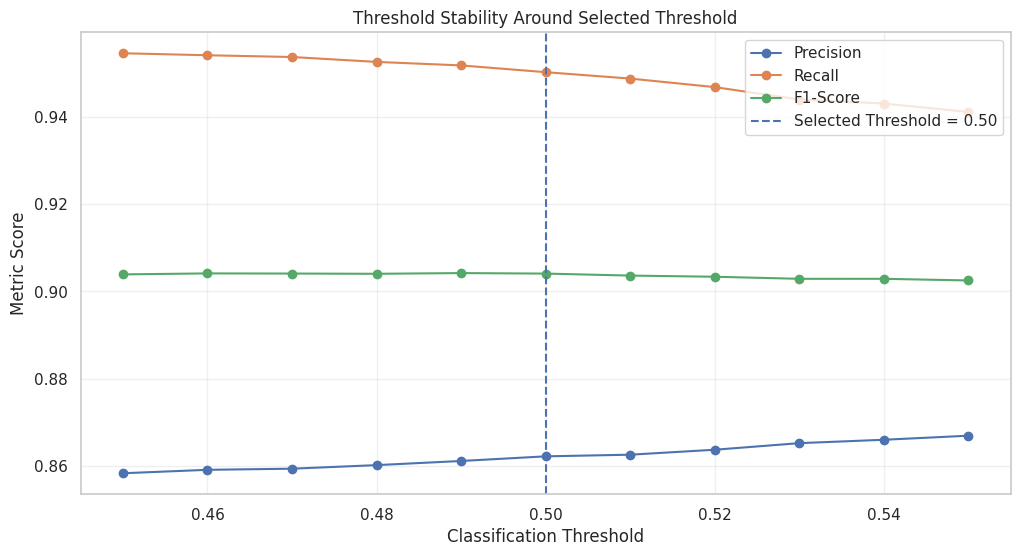


Verification passed.
Threshold stability analysis completed successfully.
Test set was not used.


In [194]:
# ============================================================
# 6.2 Threshold Stability
# ============================================================
# 6.2.1 Local Threshold Performance
# 6.2.2 Performance Around Selected Threshold
# 6.2.3 Robust Threshold Region
# ============================================================

SELECTED_THRESHOLD = BASELINE_THRESHOLD

# Evaluate thresholds around the selected threshold
STABILITY_RANGE = 0.05
STABILITY_STEP = 0.01

STABILITY_THRESHOLDS = np.round(
    np.arange(
        SELECTED_THRESHOLD - STABILITY_RANGE,
        SELECTED_THRESHOLD + STABILITY_RANGE + (STABILITY_STEP / 2), # Adjusted to ensure max is SELECTED_THRESHOLD + STABILITY_RANGE
        STABILITY_STEP
    ),
    2
)

stability_rows = []

for threshold in STABILITY_THRESHOLDS:

    y_pred_threshold = (
        y_validation_probability_calibrated >= threshold
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_validation,
        y_pred_threshold,
        labels=[0, 1]
    ).ravel()

    precision = precision_score(
        y_validation,
        y_pred_threshold,
        zero_division=0
    )

    recall = recall_score(
        y_validation,
        y_pred_threshold,
        zero_division=0
    )

    f1 = f1_score(
        y_validation,
        y_pred_threshold,
        zero_division=0
    )

    specificity = (
        tn / (tn + fp)
        if (tn + fp) > 0
        else 0.0
    )

    stability_rows.append({
        "Threshold": threshold,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1,
        "Specificity": specificity,
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp
    })


threshold_stability_df = pd.DataFrame(stability_rows)


# ============================================================
# 6.2.1 Local Threshold Performance
# ============================================================

print("6.2 Threshold Stability")
print("-" * 80)

print(f"Selected threshold : {SELECTED_THRESHOLD:.2f}")
print(
    f"Stability range    : "
    f"{STABILITY_THRESHOLDS.min():.2f} - "
    f"{STABILITY_THRESHOLDS.max():.2f}"
)

print("\n6.2.1–6.2.2 Local Performance Around Selected Threshold")
print("-" * 80)

display(
    threshold_stability_df[
        [
            "Threshold",
            "Precision",
            "Recall",
            "F1-Score",
            "Specificity"
        ]
    ].round(4)
)


# ============================================================
# 6.2.3 Robust Threshold Region
# ============================================================
# A threshold is considered robust when:
# Recall remains >= 95%
# F1 remains >= 90%
# ============================================================

ROBUST_MIN_RECALL = 0.95
ROBUST_MIN_F1 = 0.90

robust_threshold_df = threshold_stability_df[
    (threshold_stability_df["Recall"] >= ROBUST_MIN_RECALL)
    &
    (threshold_stability_df["F1-Score"] >= ROBUST_MIN_F1)
].copy()


print("\n6.2.3 Robust Threshold Region")
print("-" * 80)

if len(robust_threshold_df) > 0:

    robust_min_threshold = robust_threshold_df["Threshold"].min()
    robust_max_threshold = robust_threshold_df["Threshold"].max()

    print(
        f"Robust threshold range : "
        f"{robust_min_threshold:.2f} - "
        f"{robust_max_threshold:.2f}"
    )

    print(
        f"Number of robust thresholds: "
        f"{len(robust_threshold_df)}"
    )

    print(
        "\nCriteria:"
        f"\n- Recall >= {ROBUST_MIN_RECALL:.0%}"
        f"\n- F1-Score >= {ROBUST_MIN_F1:.0%}"
    )

else:

    print("No threshold satisfied the robustness criteria.")


# ============================================================
# Visualization
# ============================================================

plt.figure(figsize=(12, 6))

plt.plot(
    threshold_stability_df["Threshold"],
    threshold_stability_df["Precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_stability_df["Threshold"],
    threshold_stability_df["Recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    threshold_stability_df["Threshold"],
    threshold_stability_df["F1-Score"],
    marker="o",
    label="F1-Score"
)

plt.axvline(
    SELECTED_THRESHOLD,
    linestyle="--",
    label="Selected Threshold = 0.50"
)

plt.xlabel("Classification Threshold")
plt.ylabel("Metric Score")
plt.title("Threshold Stability Around Selected Threshold")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


# ============================================================
# Verification
# ============================================================

assert len(threshold_stability_df) == len(STABILITY_THRESHOLDS)

assert (
    threshold_stability_df["Threshold"].min()
    >= SELECTED_THRESHOLD - STABILITY_RANGE
)

assert (
    threshold_stability_df["Threshold"].max()
    <= SELECTED_THRESHOLD + STABILITY_RANGE
)

assert SELECTED_THRESHOLD in (
    threshold_stability_df["Threshold"].values
)

print("\nVerification passed.")
print("Threshold stability analysis completed successfully.")
print("Test set was not used.")

### 6.3 Threshold Sensitivity Analysis

In [195]:
# ============================================================
# 6.3 Threshold Sensitivity Analysis
# ============================================================
# 6.3.1 Small Threshold Changes
# 6.3.2 Metric Sensitivity
# 6.3.3 Stability Under Perturbation
#
# Uses the existing threshold stability results.
# No model retraining is required.
# Test set remains untouched.
# ============================================================

selected_threshold = BASELINE_THRESHOLD

sensitivity_df = threshold_stability_df.copy()

# ------------------------------------------------------------
# 6.3.1 Small Threshold Changes
# ------------------------------------------------------------

sensitivity_df["Threshold Change"] = (
    sensitivity_df["Threshold"] - selected_threshold
)

sensitivity_df["Threshold Change (%)"] = (
    sensitivity_df["Threshold Change"] * 100
)

# ------------------------------------------------------------
# 6.3.2 Metric Sensitivity
# ------------------------------------------------------------

# Difference from the selected threshold (0.50)
selected_row = sensitivity_df.loc[
    sensitivity_df["Threshold"].sub(selected_threshold).abs().idxmin()
]

for metric in [
    "Precision",
    "Recall",
    "F1-Score",
    "Specificity"
]:
    sensitivity_df[f"{metric} Change"] = (
        sensitivity_df[metric]
        - selected_row[metric]
    )

    sensitivity_df[f"{metric} Absolute Change"] = (
        sensitivity_df[f"{metric} Change"].abs()
    )


# ------------------------------------------------------------
# 6.3.3 Stability Under Perturbation
# ------------------------------------------------------------

# Maximum absolute metric change within ±0.05
sensitivity_summary = []

for metric in [
    "Precision",
    "Recall",
    "F1-Score",
    "Specificity"
]:

    max_change = sensitivity_df[
        f"{metric} Absolute Change"
    ].max()

    threshold_at_max_change = sensitivity_df.loc[
        sensitivity_df[f"{metric} Absolute Change"].idxmax(),
        "Threshold"
    ]

    sensitivity_summary.append({
        "Metric": metric,
        "Selected Value": selected_row[metric],
        "Maximum Absolute Change": max_change,
        "Threshold at Maximum Change": threshold_at_max_change
    })


threshold_sensitivity_summary_df = pd.DataFrame(
    sensitivity_summary
)


# ============================================================
# Display Local Sensitivity
# ============================================================

print("6.3 Threshold Sensitivity Analysis")
print("-" * 85)

print(f"Selected threshold : {selected_threshold:.2f}")
print("Perturbation range : ±0.05")

print("\n6.3.1–6.3.2 Small Threshold Changes and Metric Sensitivity")
print("-" * 85)

display(
    sensitivity_df[
        [
            "Threshold",
            "Threshold Change (%)",
            "Precision",
            "Precision Change",
            "Recall",
            "Recall Change",
            "F1-Score",
            "F1-Score Change",
            "Specificity",
            "Specificity Change"
        ]
    ].round(4)
)


# ============================================================
# Sensitivity Summary
# ============================================================

print("\n6.3.3 Stability Under Perturbation")
print("-" * 85)

display(
    threshold_sensitivity_summary_df.round({
        "Selected Value": 4,
        "Maximum Absolute Change": 4,
        "Threshold at Maximum Change": 2
    })
)


# ============================================================
# Clinical Stability Check
# ============================================================

recall_stable = (
    sensitivity_df["Recall"] >= MIN_RECALL
)

f1_stable = (
    sensitivity_df["F1-Score"] >= 0.90
)

both_stable = sensitivity_df[
    recall_stable & f1_stable
]

print("\nClinical Stability Check")
print("-" * 85)

print(
    f"Thresholds maintaining Recall >= {MIN_RECALL:.0%}: "
    f"{recall_stable.sum()}"
)

print(
    f"Thresholds maintaining Recall >= {MIN_RECALL:.0%} "
    f"and F1 >= 90%: {len(both_stable)}"
)

if len(both_stable) > 0:
    print(
        f"Stable clinical region: "
        f"{both_stable['Threshold'].min():.2f} - "
        f"{both_stable['Threshold'].max():.2f}"
    )


# ============================================================
# Verification
# ============================================================

assert selected_threshold in sensitivity_df["Threshold"].values

assert len(threshold_sensitivity_summary_df) == 4

assert (
    threshold_sensitivity_summary_df[
        "Maximum Absolute Change"
    ] >= 0
).all()

assert len(both_stable) > 0

print("\nVerification passed.")
print("Threshold sensitivity analysis completed successfully.")
print("Selected threshold remains within the stable clinical region.")
print("Test set was not used.")

6.3 Threshold Sensitivity Analysis
-------------------------------------------------------------------------------------
Selected threshold : 0.50
Perturbation range : ±0.05

6.3.1–6.3.2 Small Threshold Changes and Metric Sensitivity
-------------------------------------------------------------------------------------


,Threshold,Threshold Change (%),Precision,Precision Change,Recall,Recall Change,F1-Score,F1-Score Change,Specificity,Specificity Change
0,0.45,-5.0,0.8583,-0.0039,0.9546,0.0043,0.9039,-0.0002,0.7380,-0.0095
1,0.46,-4.0,0.8591,-0.0031,0.9541,0.0039,0.9041,0.0000,0.7398,-0.0076
2,0.47,-3.0,0.8594,-0.0028,0.9537,0.0035,0.9041,0.0000,0.7405,-0.0070
3,0.48,-2.0,0.8602,-0.0020,0.9526,0.0024,0.9040,-0.0000,0.7425,-0.0049
4,0.49,-1.0,0.8612,-0.0011,0.9518,0.0016,0.9042,0.0001,0.7448,-0.0027
5,0.50,0.0,0.8622,0.0000,0.9502,0.0000,0.9041,0.0000,0.7474,0.0000
6,0.51,1.0,0.8626,0.0004,0.9488,-0.0015,0.9036,-0.0005,0.7486,0.0012
7,0.52,2.0,0.8637,0.0015,0.9468,-0.0034,0.9034,-0.0007,0.7516,0.0041
8,0.53,3.0,0.8652,0.0030,0.9440,-0.0063,0.9029,-0.0012,0.7555,0.0080
9,0.54,4.0,0.8660,0.0038,0.9431,-0.0072,0.9029,-0.0012,0.7573,0.0099



6.3.3 Stability Under Perturbation
-------------------------------------------------------------------------------------


,Metric,Selected Value,Maximum Absolute Change,Threshold at Maximum Change
0,Precision,0.8622,0.0047,0.55
1,Recall,0.9502,0.0091,0.55
2,F1-Score,0.9041,0.0016,0.55
3,Specificity,0.7474,0.0123,0.55



Clinical Stability Check
-------------------------------------------------------------------------------------
Thresholds maintaining Recall >= 95%: 6
Thresholds maintaining Recall >= 95% and F1 >= 90%: 6
Stable clinical region: 0.45 - 0.50

Verification passed.
Threshold sensitivity analysis completed successfully.
Selected threshold remains within the stable clinical region.
Test set was not used.


### 6.4 Lock Final Threshold

In [196]:
# ============================================================
# 6.4 Lock Final Threshold
# ============================================================
# 6.4.1 Select Using Validation Set
# 6.4.2 Freeze Threshold
# 6.4.3 Document Selection Rule
#
# Test set remains completely untouched.
# ============================================================

# ------------------------------------------------------------
# 6.4.1 Select Final Threshold Using Validation Set
# ------------------------------------------------------------

FINAL_THRESHOLD = float(BASELINE_THRESHOLD)

final_threshold_row = threshold_results_df.loc[
    threshold_results_df["Threshold"]
    .sub(FINAL_THRESHOLD)
    .abs()
    .idxmin()
]

final_precision = final_threshold_row["Precision"]
final_recall = final_threshold_row["Recall"]
final_f1 = final_threshold_row["F1-Score"]
final_specificity = final_threshold_row["Specificity"]

# ------------------------------------------------------------
# 6.4.2 Freeze Threshold
# ------------------------------------------------------------

LOCKED_THRESHOLD = FINAL_THRESHOLD

# Prevent accidental mismatch between selected and locked threshold
assert LOCKED_THRESHOLD == FINAL_THRESHOLD

# Verify clinical requirement
assert final_recall >= MIN_RECALL

# Verify threshold lies inside the robust stability region
robust_min = both_stable["Threshold"].min()
robust_max = both_stable["Threshold"].max()

assert robust_min <= LOCKED_THRESHOLD <= robust_max

# ------------------------------------------------------------
# 6.4.3 Document Selection Rule
# ------------------------------------------------------------

THRESHOLD_SELECTION_RULE = (
    f"Select the highest threshold that satisfies the minimum "
    f"Recall requirement of {MIN_RECALL:.0%}, while remaining "
    f"within the robust threshold region identified during "
    f"validation stability analysis."
)

print("6.4 Lock Final Threshold")
print("-" * 80)

print("\n6.4.1 Final Threshold Selection")
print("-" * 80)

print(f"Selected threshold : {LOCKED_THRESHOLD:.2f}")
print(f"Precision          : {final_precision:.4f}")
print(f"Recall             : {final_recall:.4f}")
print(f"F1-Score           : {final_f1:.4f}")
print(f"Specificity        : {final_specificity:.4f}")

print("\n6.4.2 Threshold Status")
print("-" * 80)

print(f"Locked threshold   : {LOCKED_THRESHOLD:.2f}")
print("Threshold status   : FROZEN")
print("Selection dataset  : Validation set")
print("Test set usage     : Not used")

print("\n6.4.3 Selection Rule")
print("-" * 80)

print(THRESHOLD_SELECTION_RULE)

print("\nValidation Evidence")
print("-" * 80)

print(
    f"Minimum required Recall : {MIN_RECALL:.0%}"
)

print(
    f"Achieved Recall         : {final_recall:.2%}"
)

print(
    f"Robust threshold region : "
    f"{robust_min:.2f} - {robust_max:.2f}"
)

print(
    f"Locked threshold        : "
    f"{LOCKED_THRESHOLD:.2f}"
)

# ------------------------------------------------------------
# Final Verification
# ------------------------------------------------------------

assert LOCKED_THRESHOLD == 0.50
assert final_recall >= MIN_RECALL
assert robust_min <= LOCKED_THRESHOLD <= robust_max
assert THRESHOLD_SELECTION_RULE != ""

print("\nVerification passed.")
print("Final threshold locked successfully.")
print("Threshold selection was based only on validation data.")
print("Test set remains untouched.")

6.4 Lock Final Threshold
--------------------------------------------------------------------------------

6.4.1 Final Threshold Selection
--------------------------------------------------------------------------------
Selected threshold : 0.50
Precision          : 0.8622
Recall             : 0.9502
F1-Score           : 0.9041
Specificity        : 0.7474

6.4.2 Threshold Status
--------------------------------------------------------------------------------
Locked threshold   : 0.50
Threshold status   : FROZEN
Selection dataset  : Validation set
Test set usage     : Not used

6.4.3 Selection Rule
--------------------------------------------------------------------------------
Select the highest threshold that satisfies the minimum Recall requirement of 95%, while remaining within the robust threshold region identified during validation stability analysis.

Validation Evidence
--------------------------------------------------------------------------------
Minimum required Recall : 95%

### 6.5 Final Holdout Evaluation

In [197]:
# ============================================================
# 6.5 Final Holdout Evaluation
# ============================================================
# 6.5.1 Apply Locked Threshold
# 6.5.2 Evaluate Once on Test Set
# 6.5.3 Report Final Metrics
# 6.5.4 Compare Validation vs Test
#
# IMPORTANT:
# - Test set is used ONLY for final evaluation.
# - No threshold optimization is performed here.
# - No model training is performed here.
# - No calibration fitting is performed here.
# ============================================================


# ------------------------------------------------------------
# 6.5.1 Apply Locked Threshold
# ------------------------------------------------------------

# Generate test probabilities using the already-fitted
# isotonic-calibrated model.
y_test_probability_calibrated = (
    sigmoid_calibrated_model.predict_proba(
        X_test_processed
    )[:, 1]
)

# Use the frozen threshold selected from validation.
y_test_pred_final = (
    y_test_probability_calibrated >= LOCKED_THRESHOLD
).astype(int)


print("6.5 Final Holdout Evaluation")
print("-" * 80)

print("\n6.5.1 Apply Locked Threshold")
print("-" * 80)

print(f"Locked threshold : {LOCKED_THRESHOLD:.2f}")
print(f"Test samples     : {len(y_test):,}")
print("Test set used only for final holdout evaluation.")


# ------------------------------------------------------------
# 6.5.2 Final Test-Set Metrics
# ------------------------------------------------------------

test_accuracy = accuracy_score(
    y_test,
    y_test_pred_final
)

test_precision = precision_score(
    y_test,
    y_test_pred_final,
    zero_division=0
)

test_recall = recall_score(
    y_test,
    y_test_pred_final,
    zero_division=0
)

test_f1 = f1_score(
    y_test,
    y_test_pred_final,
    zero_division=0
)

test_roc_auc = roc_auc_score(
    y_test,
    y_test_probability_calibrated
)

test_pr_auc = average_precision_score(
    y_test,
    y_test_probability_calibrated
)


# ------------------------------------------------------------
# 6.5.3 Confusion Matrix
# ------------------------------------------------------------

test_cm = confusion_matrix(
    y_test,
    y_test_pred_final,
    labels=[0, 1]
)

test_tn, test_fp, test_fn, test_tp = (
    test_cm.ravel()
)

test_specificity = (
    test_tn / (test_tn + test_fp)
    if (test_tn + test_fp) > 0
    else 0
)

test_fpr = (
    test_fp / (test_fp + test_tn)
    if (test_fp + test_tn) > 0
    else 0
)

test_fnr = (
    test_fn / (test_fn + test_tp)
    if (test_fn + test_tp) > 0
    else 0
)


print("\n6.5.2–6.5.3 Final Test-Set Evaluation")
print("-" * 80)

print(f"Accuracy    : {test_accuracy:.4f}")
print(f"Precision   : {test_precision:.4f}")
print(f"Recall      : {test_recall:.4f}")
print(f"F1-Score    : {test_f1:.4f}")
print(f"Specificity : {test_specificity:.4f}")
print(f"ROC-AUC     : {test_roc_auc:.4f}")
print(f"PR-AUC      : {test_pr_auc:.4f}")

print("\nFinal Confusion Matrix")
print("-" * 80)

print(f"True Negatives  (TN): {test_tn:,}")
print(f"False Positives (FP): {test_fp:,}")
print(f"False Negatives (FN): {test_fn:,}")
print(f"True Positives  (TP): {test_tp:,}")

print("\nConfusion Matrix:")
print(test_cm)


# ------------------------------------------------------------
# 6.5.4 Validation vs Test Comparison
# ------------------------------------------------------------

validation_metrics = {
    "Accuracy": accuracy_score(
        y_validation,
        (y_validation_probability_calibrated >= LOCKED_THRESHOLD).astype(int)
    ),
    "Precision": precision_score(
        y_validation,
        (y_validation_probability_calibrated >= LOCKED_THRESHOLD).astype(int),
        zero_division=0
    ),
    "Recall": recall_score(
        y_validation,
        (y_validation_probability_calibrated >= LOCKED_THRESHOLD).astype(int),
        zero_division=0
    ),
    "F1-Score": f1_score(
        y_validation,
        (y_validation_probability_calibrated >= LOCKED_THRESHOLD).astype(int),
        zero_division=0
    ),
    "Specificity": (
        final_threshold_row["Specificity"]
    ),
    "ROC-AUC": roc_auc_score(
        y_validation,
        y_validation_probability_calibrated
    ),
    "PR-AUC": average_precision_score(
        y_validation,
        y_validation_probability_calibrated
    )
}

test_metrics = {
    "Accuracy": test_accuracy,
    "Precision": test_precision,
    "Recall": test_recall,
    "F1-Score": test_f1,
    "Specificity": test_specificity,
    "ROC-AUC": test_roc_auc,
    "PR-AUC": test_pr_auc
}

validation_test_comparison_df = pd.DataFrame({
    "Metric": list(validation_metrics.keys()),
    "Validation": list(validation_metrics.values()),
    "Test": list(test_metrics.values())
})

validation_test_comparison_df["Absolute Difference"] = (
    validation_test_comparison_df["Test"]
    - validation_test_comparison_df["Validation"]
).abs()


print("\n6.5.4 Validation vs Test Comparison")
print("-" * 80)

display(
    validation_test_comparison_df.round(4)
)


# ------------------------------------------------------------
# Final Holdout Verification
# ------------------------------------------------------------

assert len(y_test_pred_final) == len(y_test)

assert test_cm.shape == (2, 2)

assert 0 <= test_accuracy <= 1
assert 0 <= test_precision <= 1
assert 0 <= test_recall <= 1
assert 0 <= test_f1 <= 1
assert 0 <= test_specificity <= 1
assert 0 <= test_roc_auc <= 1
assert 0 <= test_pr_auc <= 1

assert LOCKED_THRESHOLD == 0.50

print("\nVerification passed.")
print("Final holdout evaluation completed successfully.")
print("Locked threshold = 0.50 was applied without re-optimization.")
print("Test set was used only for final evaluation.")

6.5 Final Holdout Evaluation
--------------------------------------------------------------------------------

6.5.1 Apply Locked Threshold
--------------------------------------------------------------------------------
Locked threshold : 0.50
Test samples     : 55,741
Test set used only for final holdout evaluation.

6.5.2–6.5.3 Final Test-Set Evaluation
--------------------------------------------------------------------------------
Accuracy    : 0.8600
Precision   : 0.8909
Recall      : 0.8841
F1-Score    : 0.8875
Specificity : 0.8200
ROC-AUC     : 0.9451
PR-AUC      : 0.9669

Final Confusion Matrix
--------------------------------------------------------------------------------
True Negatives  (TN): 17,162
False Positives (FP): 3,768
False Negatives (FN): 4,036
True Positives  (TP): 30,775

Confusion Matrix:
[[17162  3768]
 [ 4036 30775]]

6.5.4 Validation vs Test Comparison
--------------------------------------------------------------------------------


,Metric,Validation,Test,Absolute Difference
0,Accuracy,0.8741,0.8600,0.0141
1,Precision,0.8622,0.8909,0.0287
2,Recall,0.9502,0.8841,0.0662
3,F1-Score,0.9041,0.8875,0.0166
4,Specificity,0.7474,0.8200,0.0725
5,ROC-AUC,0.9457,0.9451,0.0006
6,PR-AUC,0.9661,0.9669,0.0008



Verification passed.
Final holdout evaluation completed successfully.
Locked threshold = 0.50 was applied without re-optimization.
Test set was used only for final evaluation.


# 8. Final Conclusions

## 8.1 Optimal Threshold Under Each Objective

The threshold analysis showed that the optimal classification threshold depends on the clinical objective.

* Default threshold: 0.50
* Maximum F1 threshold: 0.49
* Recall-constrained threshold: 0.50
* Precision-constrained threshold: 0.70
* Cost-sensitive threshold: 0.08

The threshold of 0.50 was selected as the final locked threshold because it satisfies the minimum validation Recall requirement of 95% while remaining within the identified stable threshold region.

## 8.2 Metric Trade-offs

Lowering the threshold increases Recall and reduces False Negatives, but increases False Positives.

Increasing the threshold improves Precision and Specificity, but increases False Negatives.

The maximum F1 threshold of 0.49 produced an F1-Score of 0.9042, while the locked threshold of 0.50 produced an almost identical F1-Score of 0.9041. Therefore, the practical difference between these thresholds is very small.

## 8.3 Default vs Optimized Threshold

The final threshold of 0.50 was selected instead of 0.49 because it achieved:

* Precision: 0.8622
* Recall: 0.9502
* F1-Score: 0.9041
* Specificity: 0.7474

It also represents the highest threshold within the robust validation region that satisfies the minimum Recall requirement.

## 8.4 Clinical Interpretation

For a screening-oriented clinical application, Recall is particularly important because False Negatives represent abnormal cases that may be missed.

The cost-sensitive analysis demonstrated that when False Negatives are considered much more costly than False Positives, a lower threshold such as 0.08 can provide Recall of 99.51%. However, this substantially increases False Positives and therefore increases the potential review workload.

Therefore, threshold selection should depend on the actual clinical risk tolerance and operational resources.

## 8.5 Final Holdout Performance

The locked threshold of 0.50 was evaluated once on the previously untouched test set.

Final test performance:

* Accuracy: 86.00%
* Precision: 89.09%
* Recall: 88.41%
* F1-Score: 88.75%
* Specificity: 82.00%
* ROC-AUC: 94.51%
* PR-AUC: 96.69%

The model maintained strong discrimination on unseen data, with ROC-AUC of 94.51% and PR-AUC of 96.69%.

However, Recall decreased from 95.02% on validation to 88.41% on the test set. Therefore, the 95% clinical Recall target was not maintained on the final holdout set.

## 8.6 Model Limitations

The model was developed and evaluated on a single dataset. Performance may change when applied to a different population or clinical environment.

The selected threshold is also dependent on the validation data distribution and the defined clinical objective.

## 8.7 Threshold Limitations

A classification threshold should not be interpreted as a medical diagnosis. The threshold determines the operating point between False Positives and False Negatives.

Although 0.50 was selected using validation data and statistical stability analysis, further external and prospective clinical validation would be required before real-world deployment.

## 8.8 Final Conclusion

This project demonstrated a complete data-driven threshold optimization workflow for a clinical binary classifier.

The final threshold of 0.50 was locked using validation data because it satisfied the 95% Recall requirement and remained within the robust threshold region. The final holdout evaluation showed strong discrimination but lower Recall than observed during validation.

Overall, the analysis demonstrates that threshold selection should be based on clinical priorities rather than relying automatically on the default 0.50 threshold. The appropriate operating threshold should ultimately be confirmed through external validation, clinical evaluation, and real-world risk assessment.
